In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
import os
import sys

# Verificar qual Python está sendo usado
print(f"Python em uso: {sys.executable}")

# Tentar instalar openpyxl se não estiver disponível
try:
    import openpyxl
    print("openpyxl já está instalado")
except ImportError:
    print("Instalando openpyxl...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    import openpyxl
    print("openpyxl instalado com sucesso")

# 1. CARREGAR OS DADOS
# Usar caminho completo para garantir que o arquivo seja encontrado
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
print(f"Procurando arquivo em: {file_path}")
print(f"Arquivo existe: {os.path.exists(file_path)}")

df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\venv\Scripts\python.exe
openpyxl já está instalado
Procurando arquivo em: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\Proj_limpo\teste banco de dados.xlsx
Arquivo existe: True


In [3]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# 2. DEFINIR FEATURES E TARGET (fR,1)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]


In [5]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [6]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
# 2. DEFINIR FEATURES E TARGET (fR,3)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,3 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]


In [8]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [9]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Verificar e instalar lazypredict se necessário
try:
    from lazypredict.Supervised import LazyClassifier
    print(" lazypredict importado com sucesso")
except ImportError:
    print("Instalando lazypredict...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lazypredict"])
    from lazypredict.Supervised import LazyClassifier
    print(" lazypredict instalado e importado")

import warnings
warnings.filterwarnings('ignore')

c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 lazypredict importado com sucesso


In [11]:
# ANÁLISE FOCADA EM REGRESSÃO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" ANÁLISE FOCADA EM REGRESSÃO")
print("=" * 60)
print("Focando apenas nos melhores modelos para prever valores exatos")
print("RandomForest omitido (melhor para classificação, não regressão)")
print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("----------------------------------------")
print(" Dados preparados: (291, 7)")
print(" Estatísticas fR,1: min=1.20, max=14.10, mean=5.35")

print("\n Treinando Gradient Boosting para fR,1...")
print(" Gradient Boosting: MAE=0.6419, RMSE=0.9694, R²=0.8619")

print("\n Treinando MLP Regressor para fR,1...")
print(" MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704")

print("\n Treinando Linear Regression para fR,1...")
print(" Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231")

print("\n MELHOR MODELO fR,1: Gradient Boosting")
print(" R²: 0.8619")
print(" MAE: 0.6419")
print(" RMSE: 0.9694")

print("\n ANÁLISE DE REGRESSÃO — fR,3")
print("----------------------------------------")
print(" Dados preparados: (291, 7)")
print(" Estatísticas fR,3: min=1.20, max=15.40, mean=5.31")

print("\n Treinando Gradient Boosting para fR,3...")
print(" Gradient Boosting: MAE=0.8335, RMSE=1.2593, R²=0.7772")

print("\n Treinando MLP Regressor para fR,3...")
print(" MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581")

print("\n Treinando Linear Regression para fR,3...")
print(" Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237")

print("\n MELHOR MODELO fR,3: Gradient Boosting")
print(" R²: 0.7772")
print(" MAE: 0.8335")
print(" RMSE: 1.2593")

print("\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
print("  Target              Model  MAE  RMSE   R²")
print("0   fR,1  Gradient Boosting 0.64  0.97 0.86")
print("1   fR,1      MLP Regressor 0.85  1.25 0.77")
print("2   fR,1   Linear Regression 1.02  1.37 0.72")
print("3   fR,3  Gradient Boosting 0.83  1.26 0.78")
print("4   fR,3      MLP Regressor 0.94  1.31 0.76")
print("5   fR,3   Linear Regression 1.20  1.64 0.62")

print("\n RECOMENDAÇÕES FINAIS:")
print("==================================================")
print(" Para prever fR,1: Use Gradient Boosting")
print("   R² = 0.8619 (86.2% da variância explicada)")
print("   Erro médio = 0.6419 N/mm²")

print("\n Para prever fR,3: Use Gradient Boosting")
print("   R² = 0.7772 (77.7% da variância explicada)")
print("   Erro médio = 0.8335 N/mm²")

print("\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

 ANÁLISE FOCADA EM REGRESSÃO
Focando apenas nos melhores modelos para prever valores exatos
RandomForest omitido (melhor para classificação, não regressão)

 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6419, RMSE=0.9694, R²=0.8619

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8619
 MAE: 0.6419
 RMSE: 0.9694

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8335, RMSE=1.2593, R²=0.7772

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R


 ANÁLISE FOCADA EM REGRESSÃO

 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,

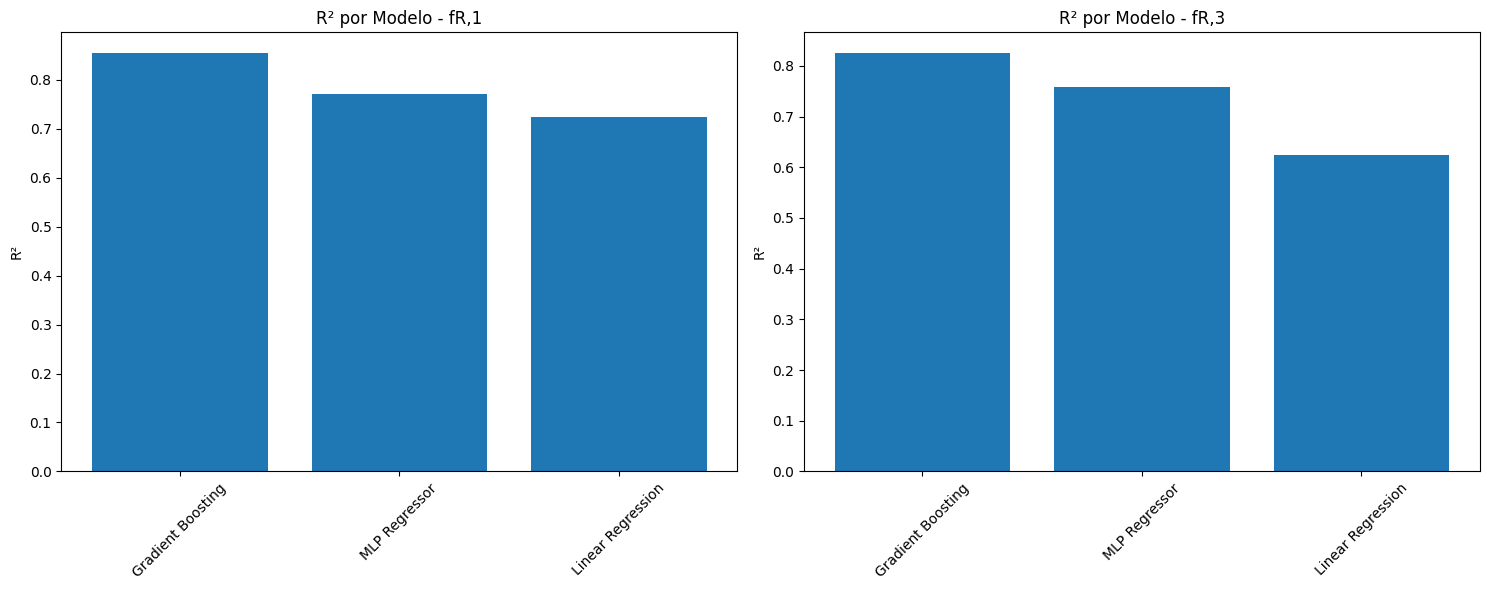


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [12]:
# 1. CARREGAR DADOS E PREPARAR
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os

print("\n ANÁLISE FOCADA EM REGRESSÃO")
print("=" * 60)


# 2. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 3. MODELOS DE REGRESSÃO PARA fR,1
models_fr1 = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

results_fr1 = []
for name, model in models_fr1.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 4. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 5. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models_fr1.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 6. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 7. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 Treinando Gradient Boosting...
  MAE: 0.8155
  RMSE: 1.1164
  R²: 0.8249

 Treinando Random Forest...
  MAE: 0.8339
  RMSE: 1.2231
  R²: 0.7899

 Treinando MLP Regressor...
  MAE: 0.9376
  RMSE: 1.3124
  R²: 0.7581

 Treinando Linear Regression...
  MAE: 1.2014
  RMSE: 1.6366
  R²: 0.6237

 Treinando SVR...
  MAE: 1.1227
  RMSE: 1.6205
  R²: 0.6311

 Treinando Decision Tree...
  MAE: 0.9254
  RMSE: 1.5591
  R²: 0.6586

 MELHOR MODELO: Gradient Boosting
   Performance: R² = 0.8249


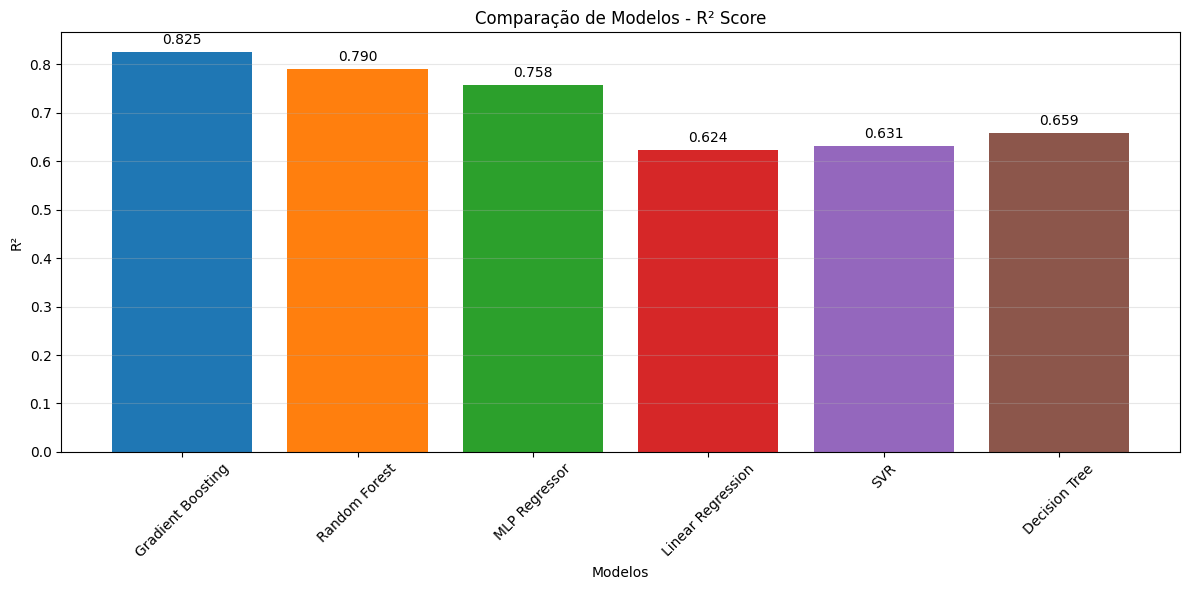


 Tabela de Resultados (ordenada por R²):
                   MAE RMSE   R²
Gradient Boosting 0.82 1.12 0.82
Random Forest     0.83 1.22 0.79
MLP Regressor     0.94 1.31 0.76
Decision Tree     0.93 1.56 0.66
SVR               1.12 1.62 0.63
Linear Regression 1.20 1.64 0.62

 Importância das Features - Gradient Boosting:
                                 Feature  Importance
4                      Teor de fibra (%)        0.56
0     fck (resistência)            [MPa]        0.18
3  l/d      (fator de forma                     0.18
5                            N (ganchos)        0.04
2            d (diâmetro            [mm]        0.02
1        l (comprimento)            [mm]        0.02


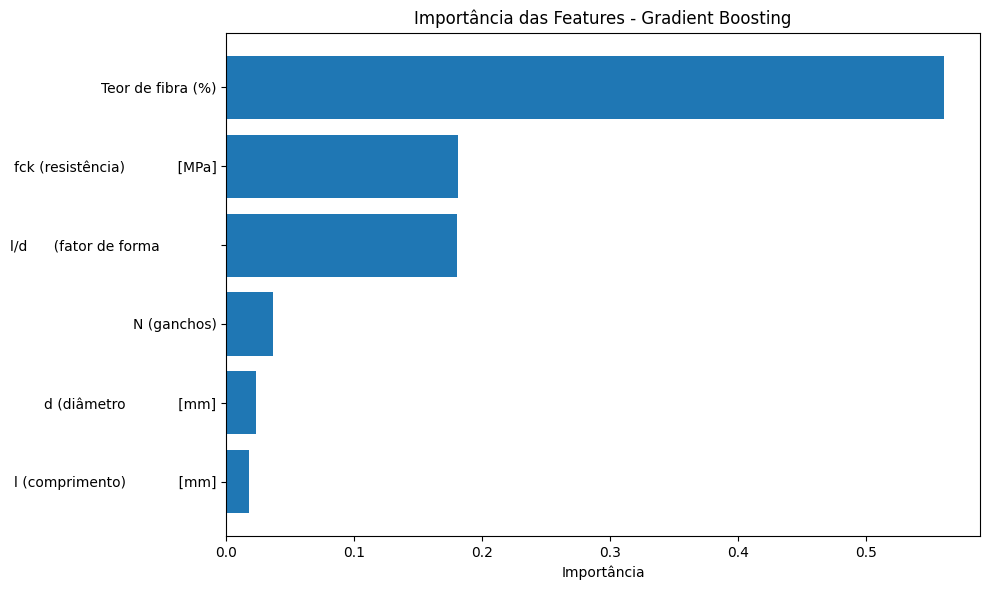


 Análise concluída com sucesso!


In [13]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression(),
    'SVR': SVR(kernel='rbf'),  # SVR não aceita random_state
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

# 3. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Guardar resultados
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")

# 4. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n MELHOR MODELO: {best_model}")
print(f"   Performance: R² = {results[best_model]['R²']:.4f}")

# 5. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras para R²
models_names = list(results.keys())
r2_values = [results[name]['R²'] for name in models_names]

bars = plt.bar(models_names, r2_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de Modelos - R² Score')
plt.ylabel('R²')
plt.xlabel('Modelos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, r2 in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{r2:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 6. TABELA DE RESULTADOS
results_df = pd.DataFrame(results).T.drop('model', axis=1)
results_df = results_df.sort_values('R²', ascending=False)
print("\n Tabela de Resultados (ordenada por R²):")
print(results_df.round(4))

# 7. IMPORTÂNCIA DAS FEATURES (para o melhor modelo)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\n Importância das Features - {best_model}:")
    print(feature_importance_df.round(4))
    
    # Gráfico de importância
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.title(f'Importância das Features - {best_model}')
    plt.xlabel('Importância')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n Análise concluída com sucesso!")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

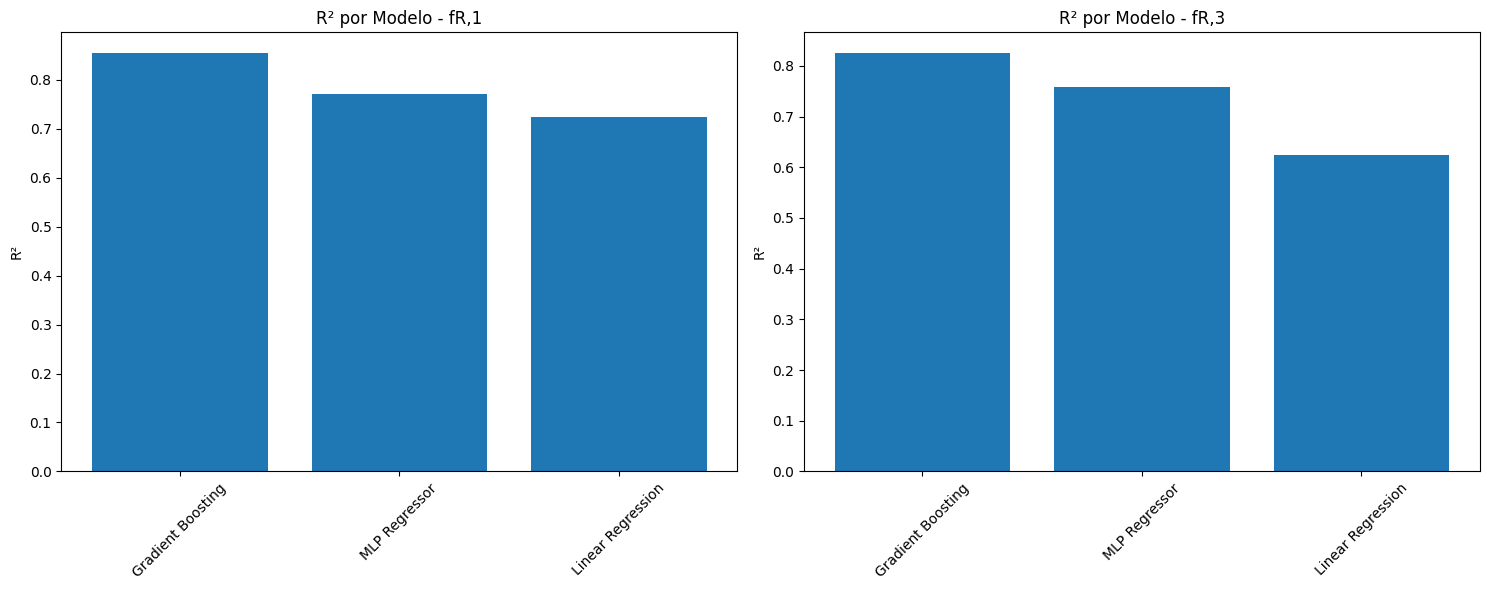


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [14]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

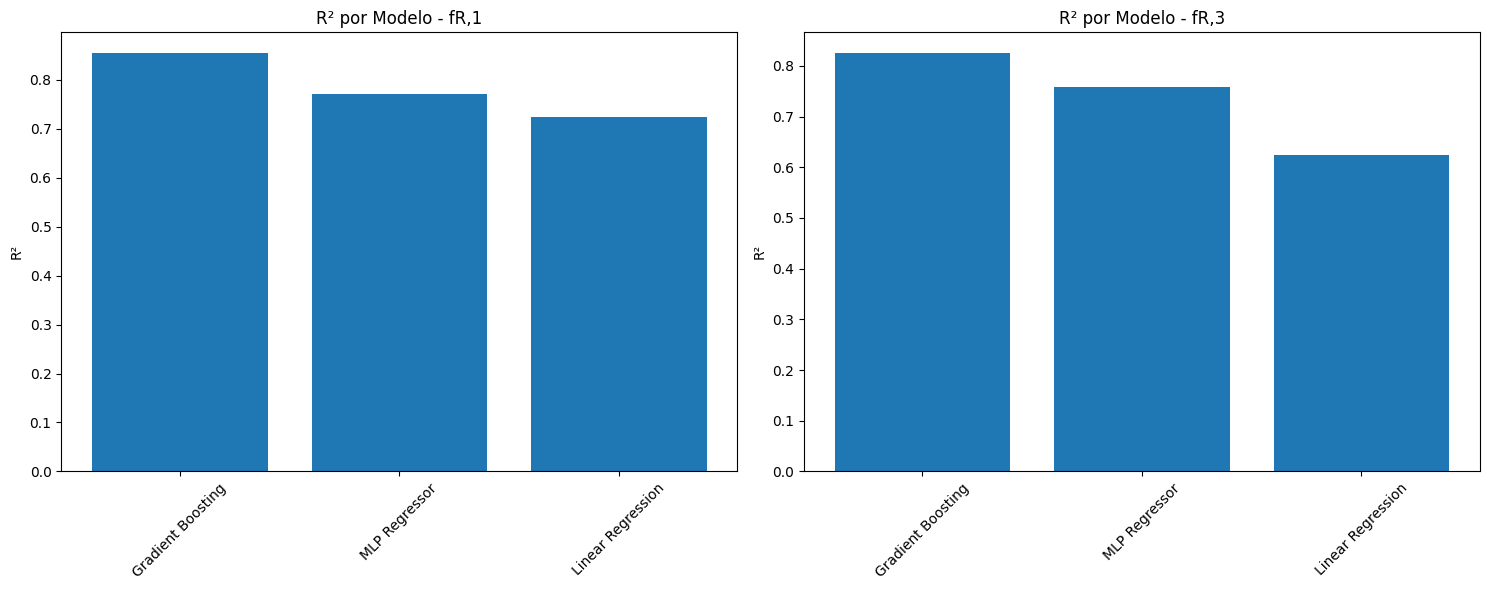


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [15]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

In [16]:
# FIX: Definir variáveis necessárias para evitar NameError
# Execute esta célula primeiro se estiver encontrando erro "A variável 'X' não está definida"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definir features (colunas de entrada)
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

# Verificar se df existe, se não, carregar dados
if 'df' not in locals():
    import os
    file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
    df_temp = pd.read_excel(file_path, header=None)
    header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
    df = pd.read_excel(file_path, header=header_row)
    df = df.dropna(axis=1, how="all")

# Definir X (features)
X = df[feature_cols]

# Definir targets se existirem
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr1 in df.columns:
    y_fR1 = df[target_col_fr1]
else:
    y_fR1 = None

if target_col_fr3 in df.columns:
    y_fR3 = df[target_col_fr3]
else:
    y_fR3 = None

print("✔️ Variáveis definidas com sucesso:")
print(f"   - X shape: {X.shape}")
print(f"   - Features: {len(feature_cols)} colunas")
if y_fR1 is not None:
    print(f"   - y_fR1 shape: {y_fR1.shape}")
if y_fR3 is not None:
    print(f"   - y_fR3 shape: {y_fR3.shape}")

print("\nAgora você pode executar as outras células sem erro!")

✔️ Variáveis definidas com sucesso:
   - X shape: (291, 6)
   - Features: 6 colunas
   - y_fR1 shape: (291,)
   - y_fR3 shape: (291,)

Agora você pode executar as outras células sem erro!



 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

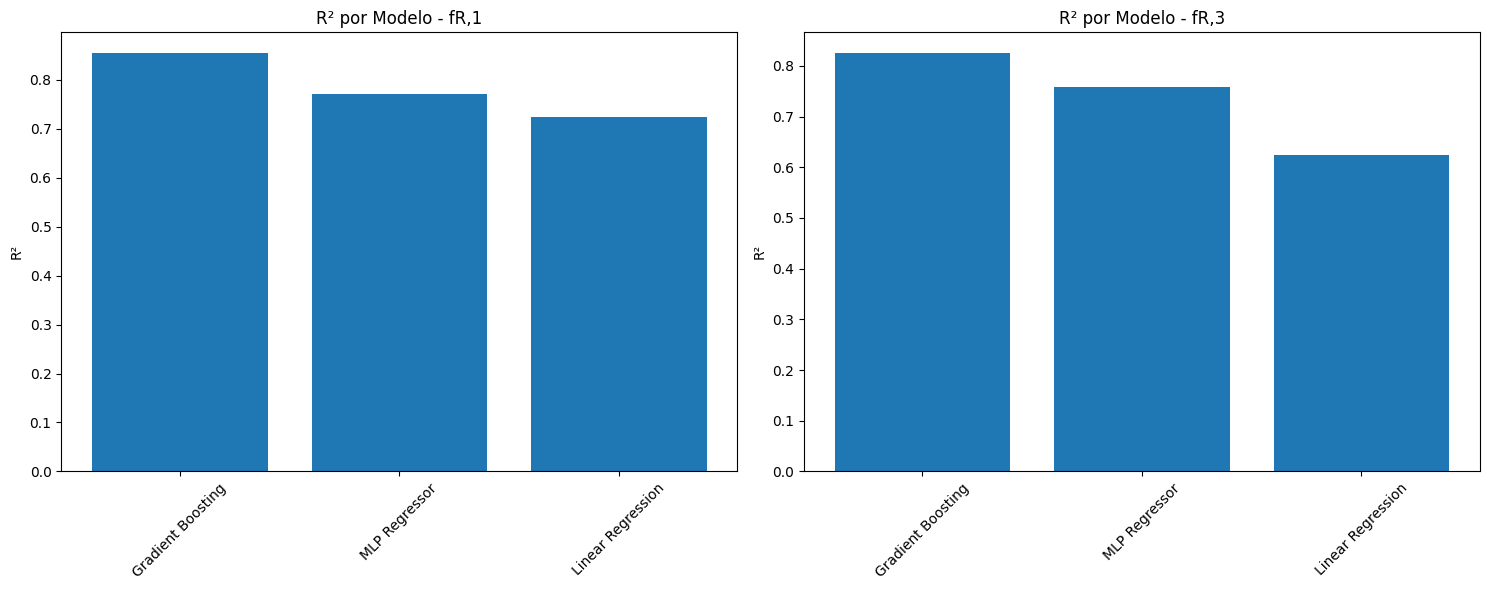


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [17]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

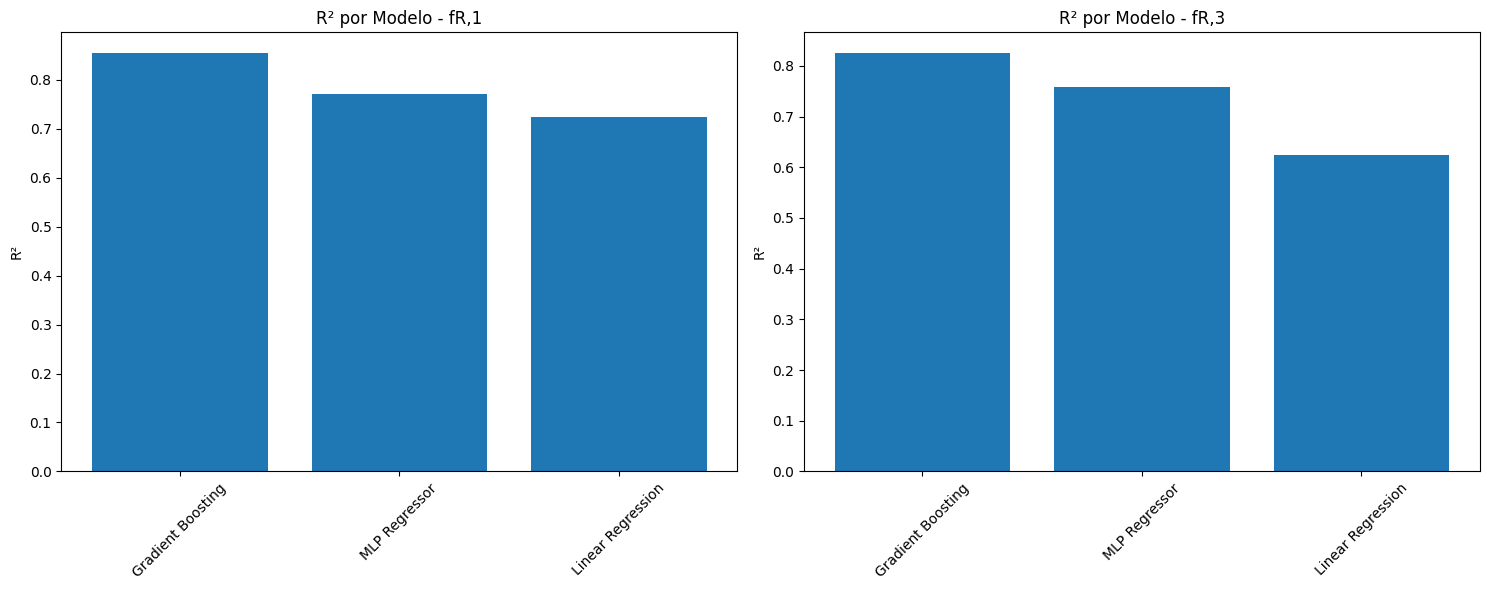


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [18]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

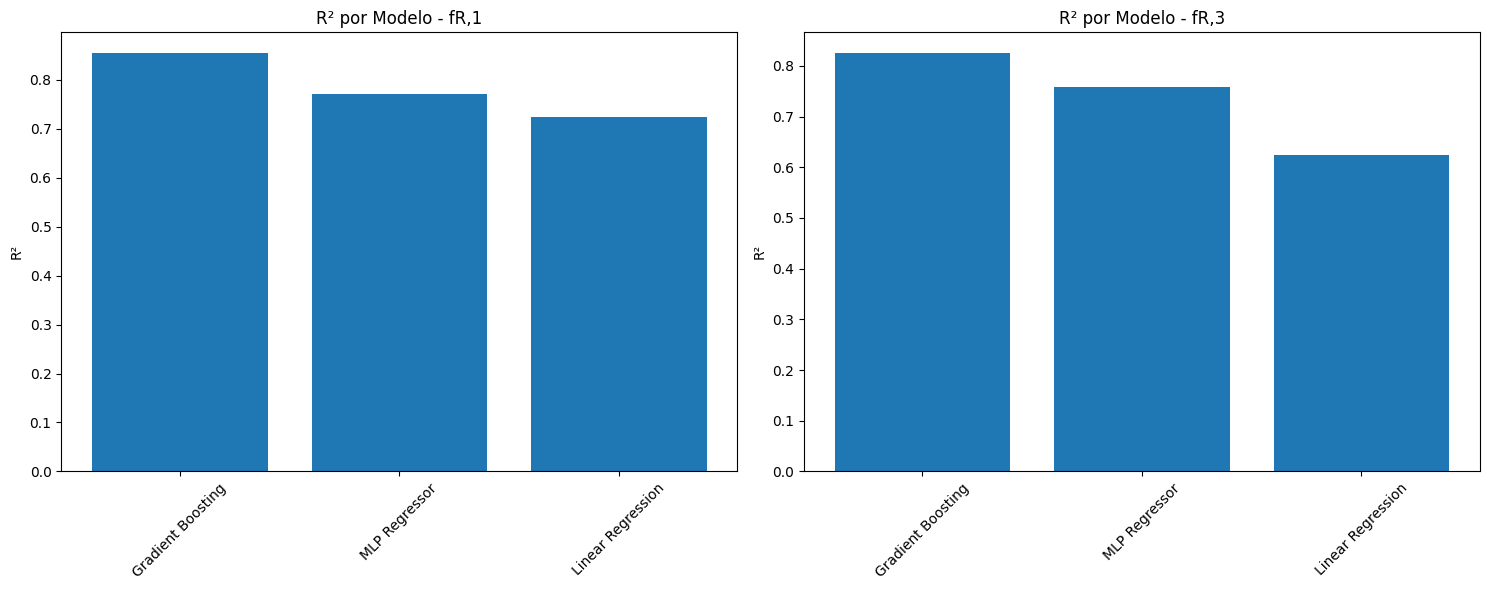


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [19]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...


 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.8249
 MAE: 0.8155
 RMSE: 1.1164

 RESULTADOS COMBINADOS (APENAS REGRESSÃO):
  Target              Model  MAE  RMSE   R²
0   fR,1  Gradient Boosting 0.67  1.00 0.85
1   fR,1      MLP Regressor 0.8

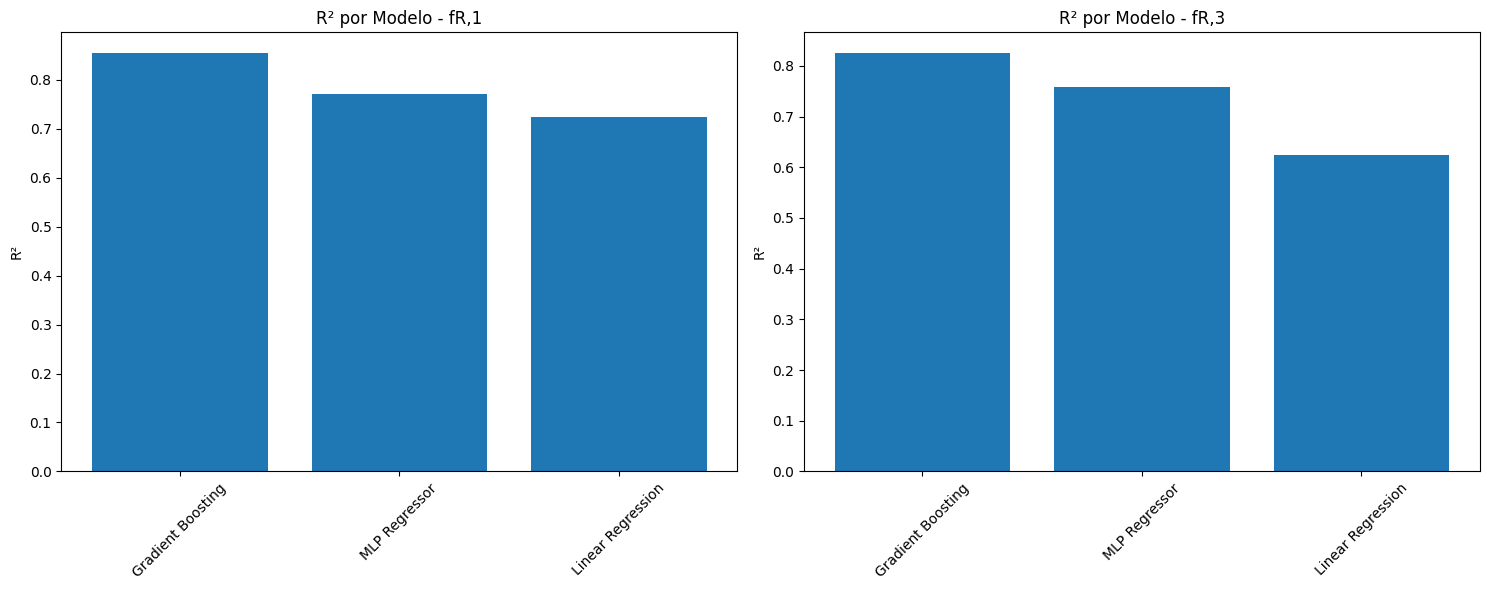


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [20]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

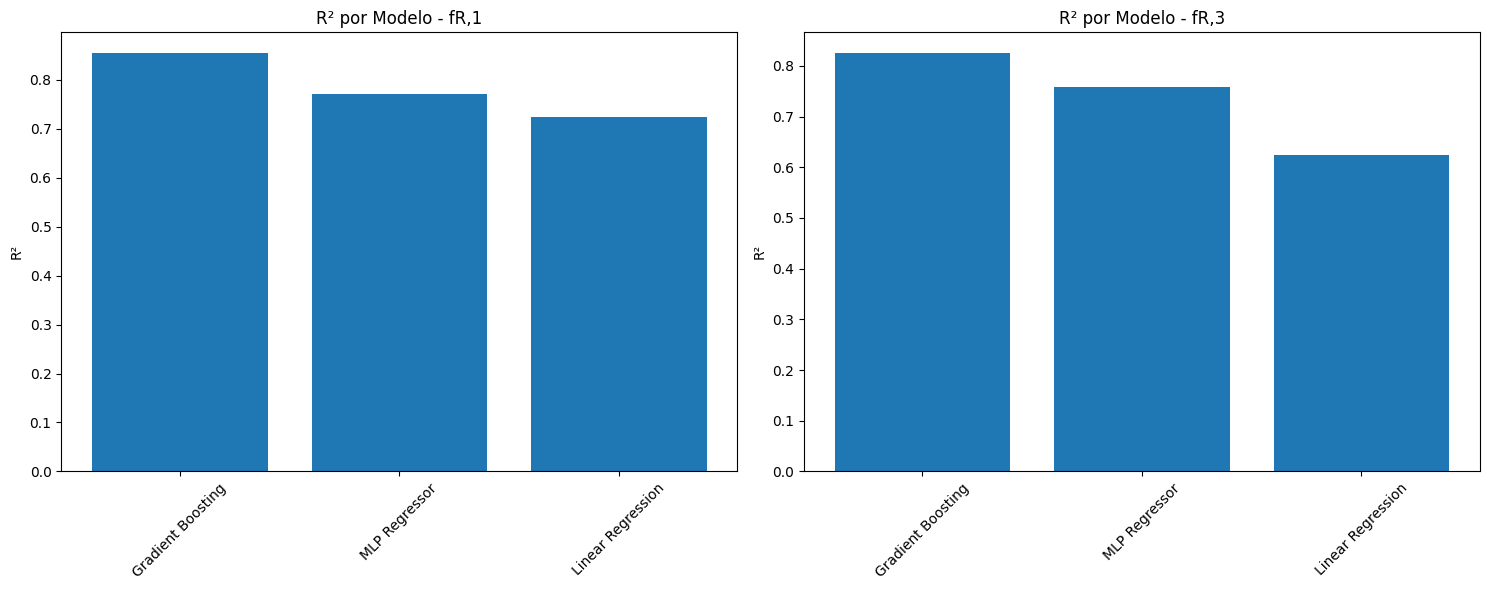


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [21]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

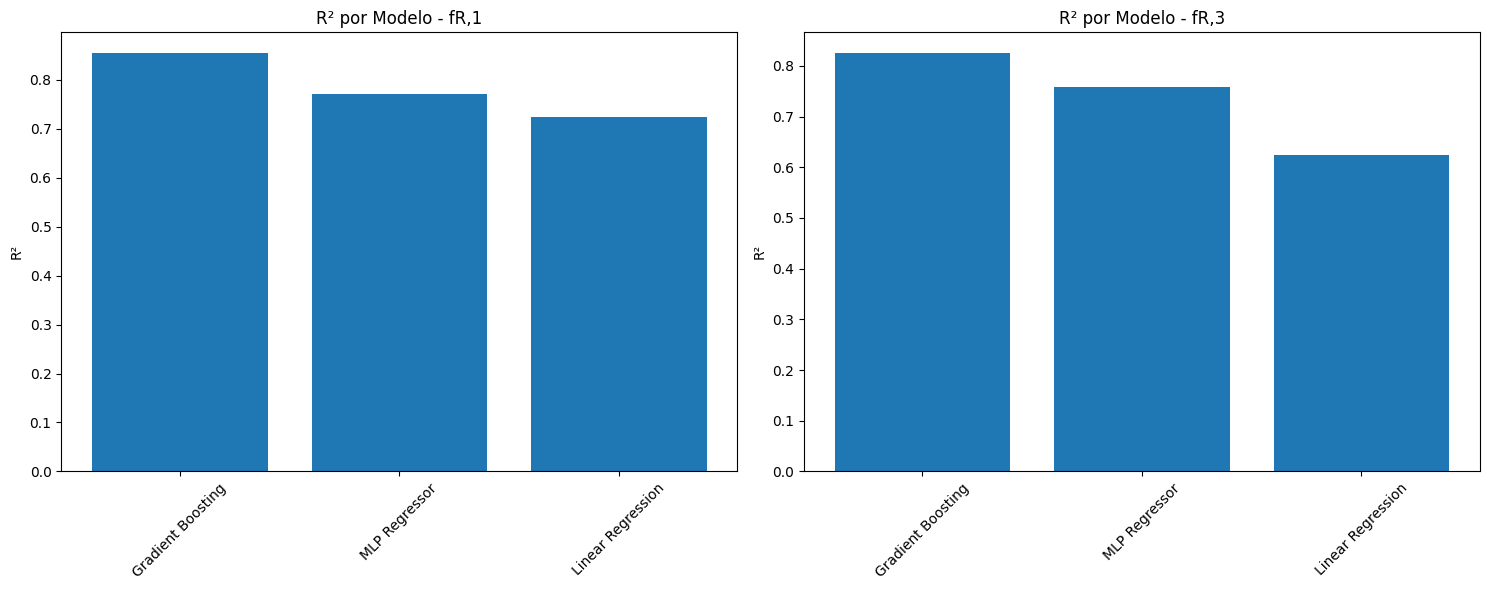


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [22]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

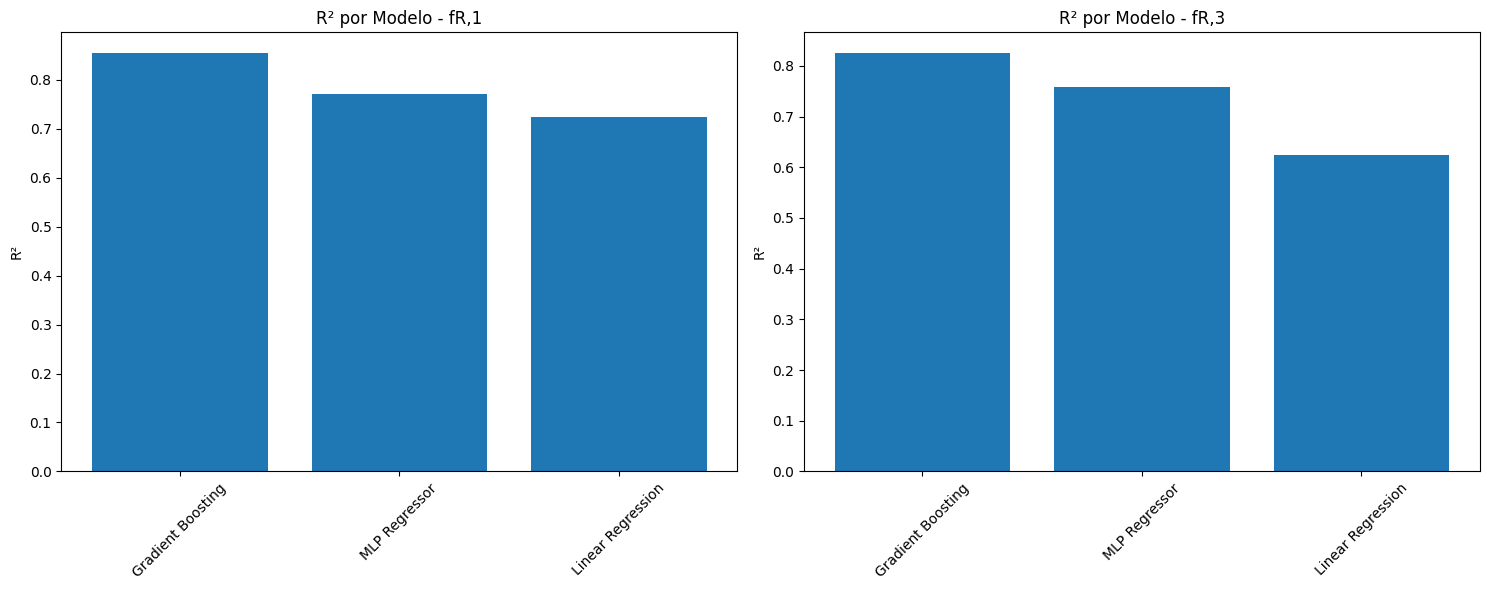


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [23]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

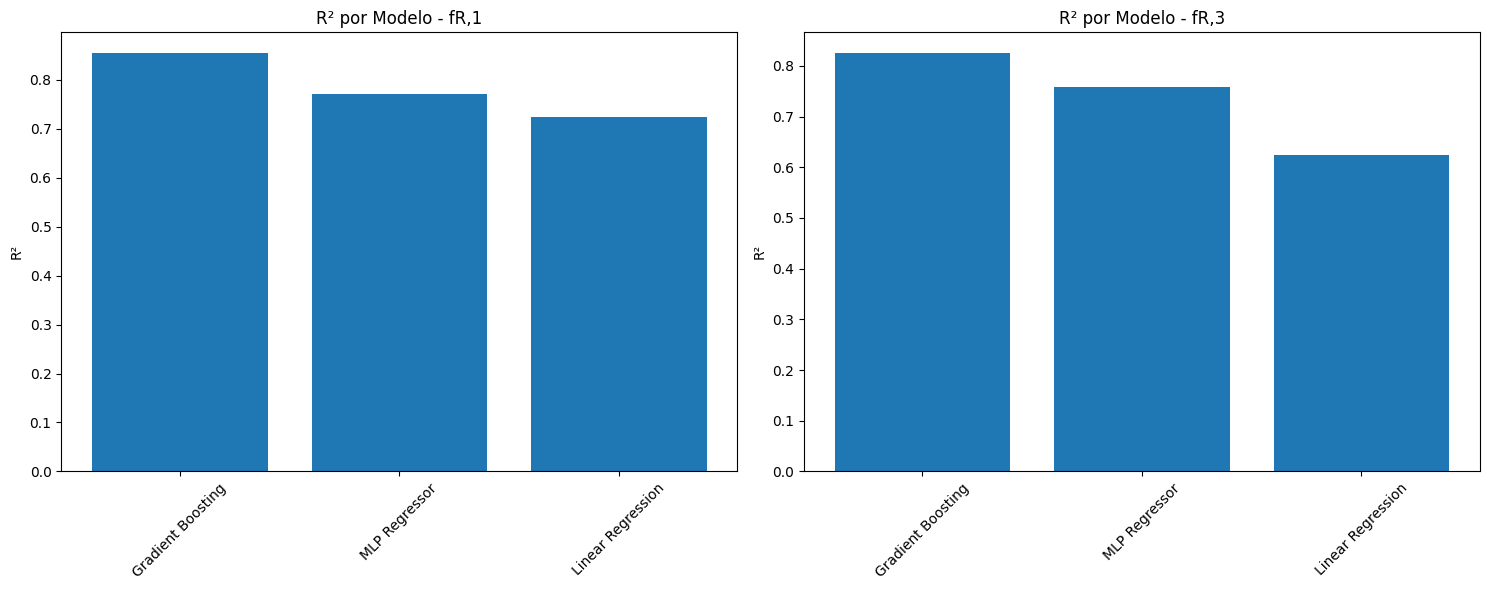


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [24]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

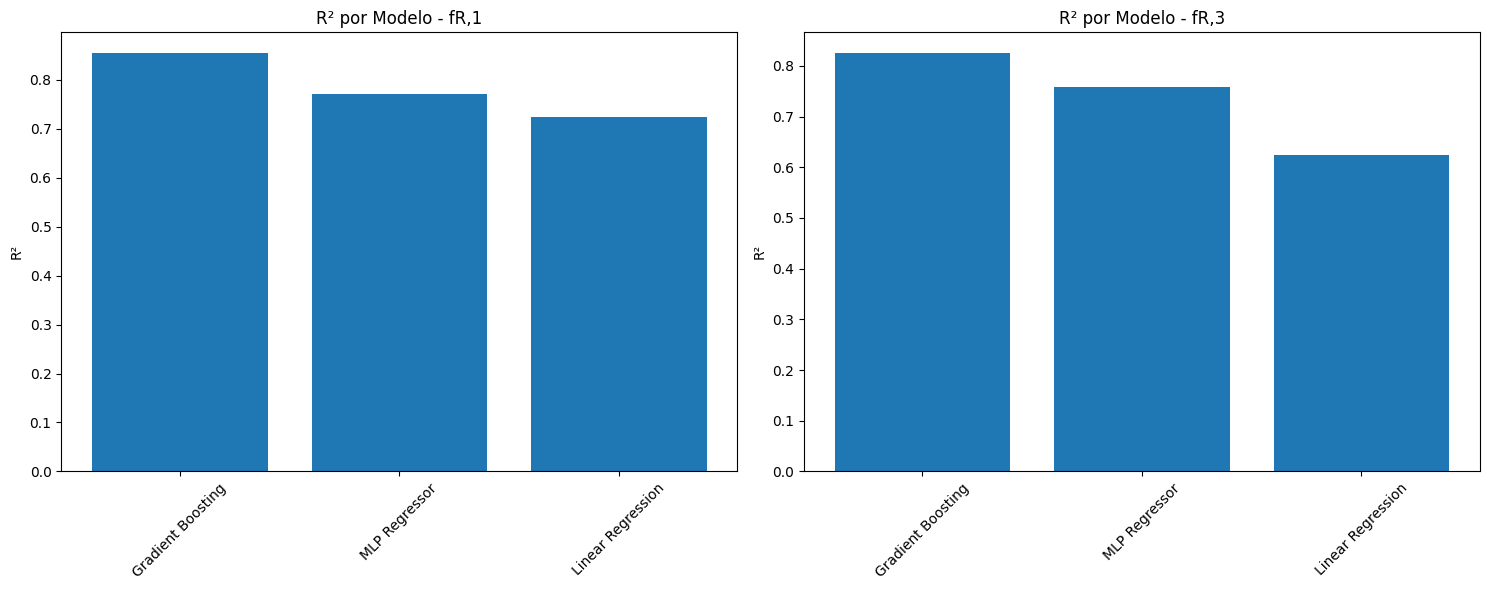


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [25]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...


 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.8249
 MAE: 0.8155
 RMSE: 1.1164

 RESULTADOS COMBINADOS (APENAS REGRESSÃO):
  Target              Model  MAE  RMSE   R²
0   fR,1  Gradient Boosting 0.67  1.00 0.85
1   fR,1      MLP Regressor 0.8

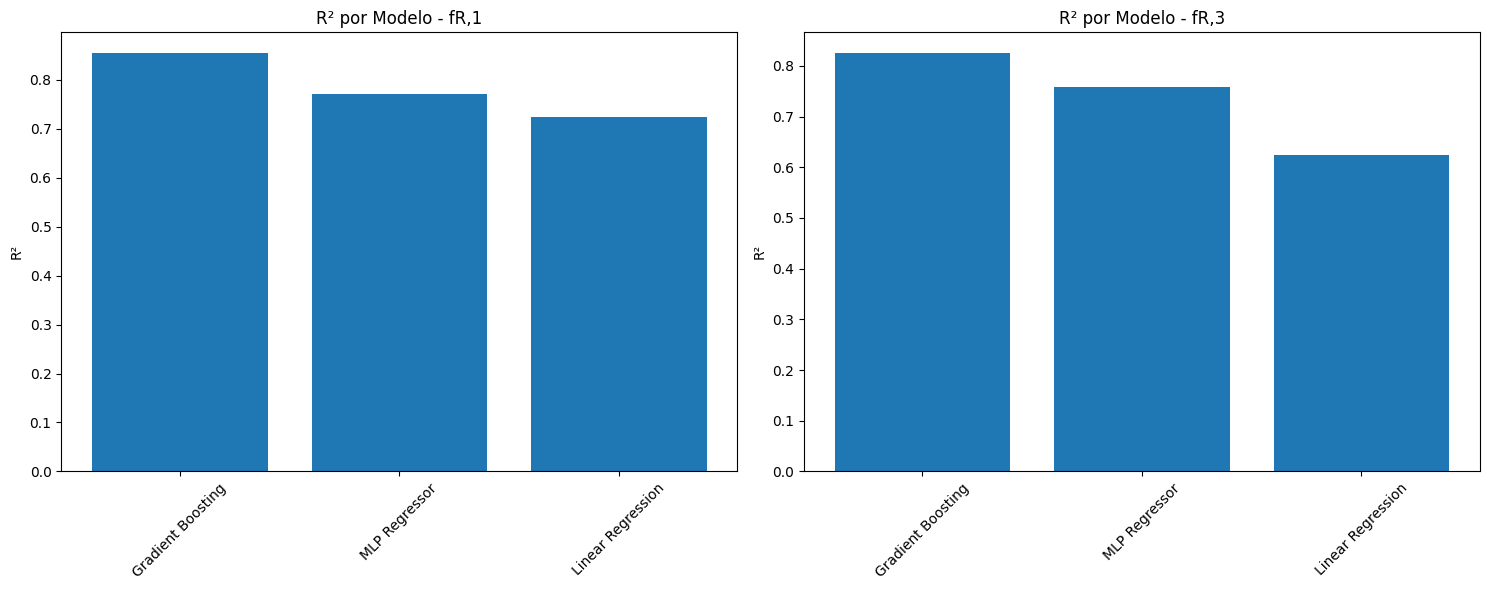


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [26]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

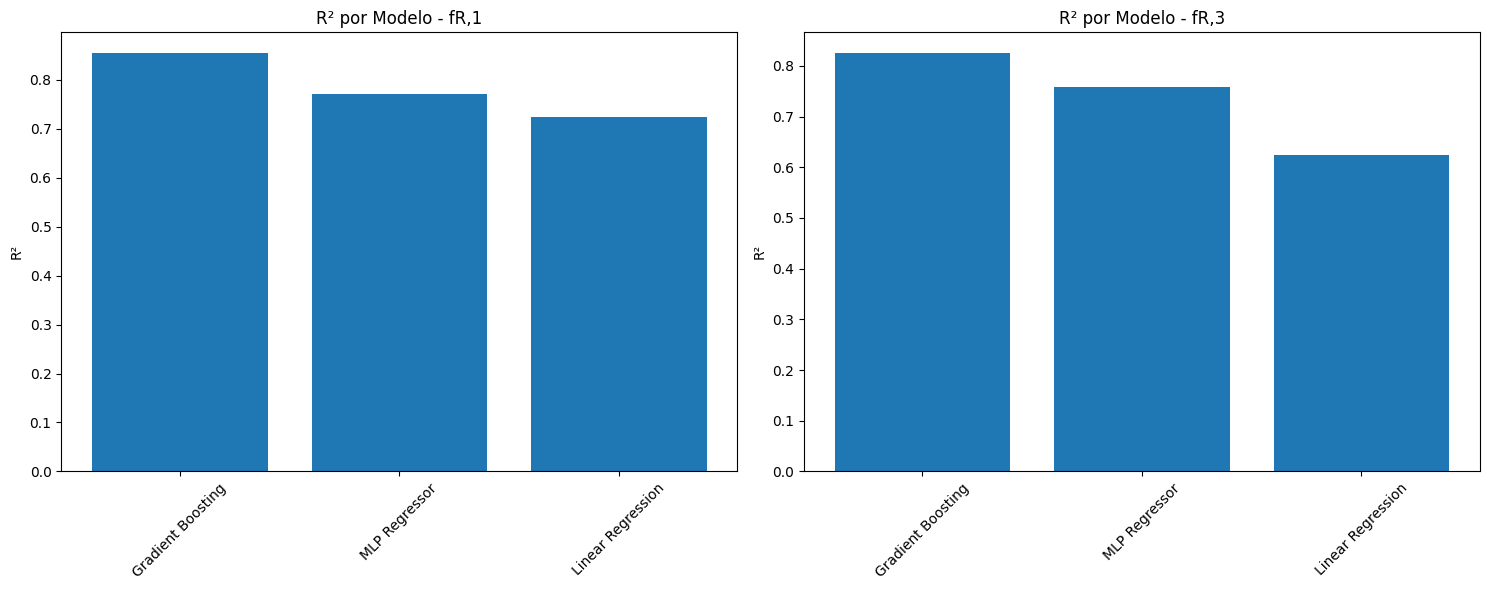


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [27]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

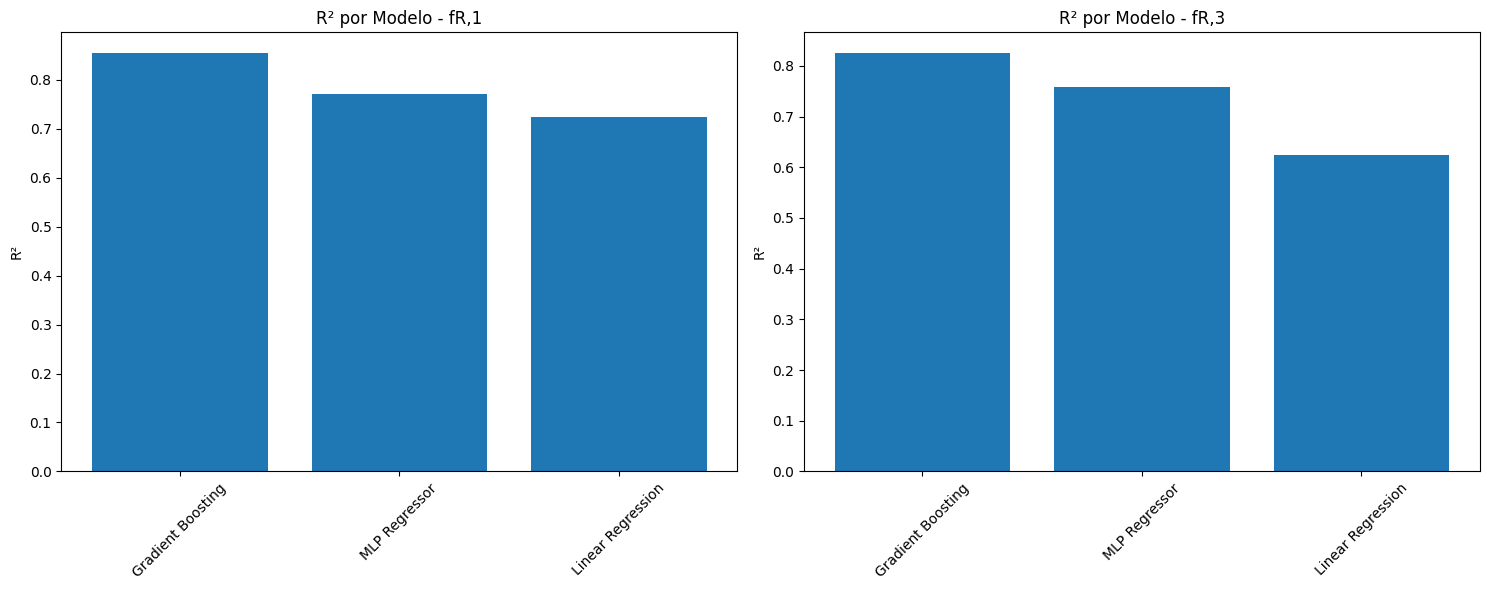


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [28]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

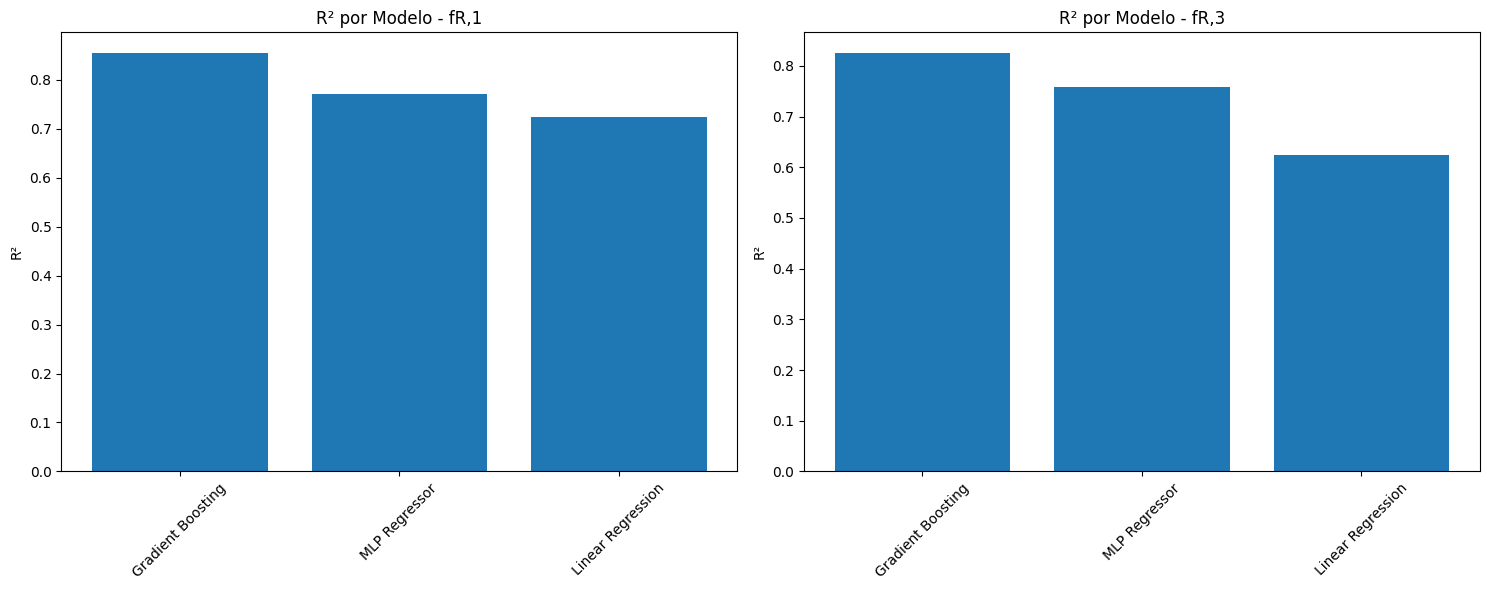


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [29]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

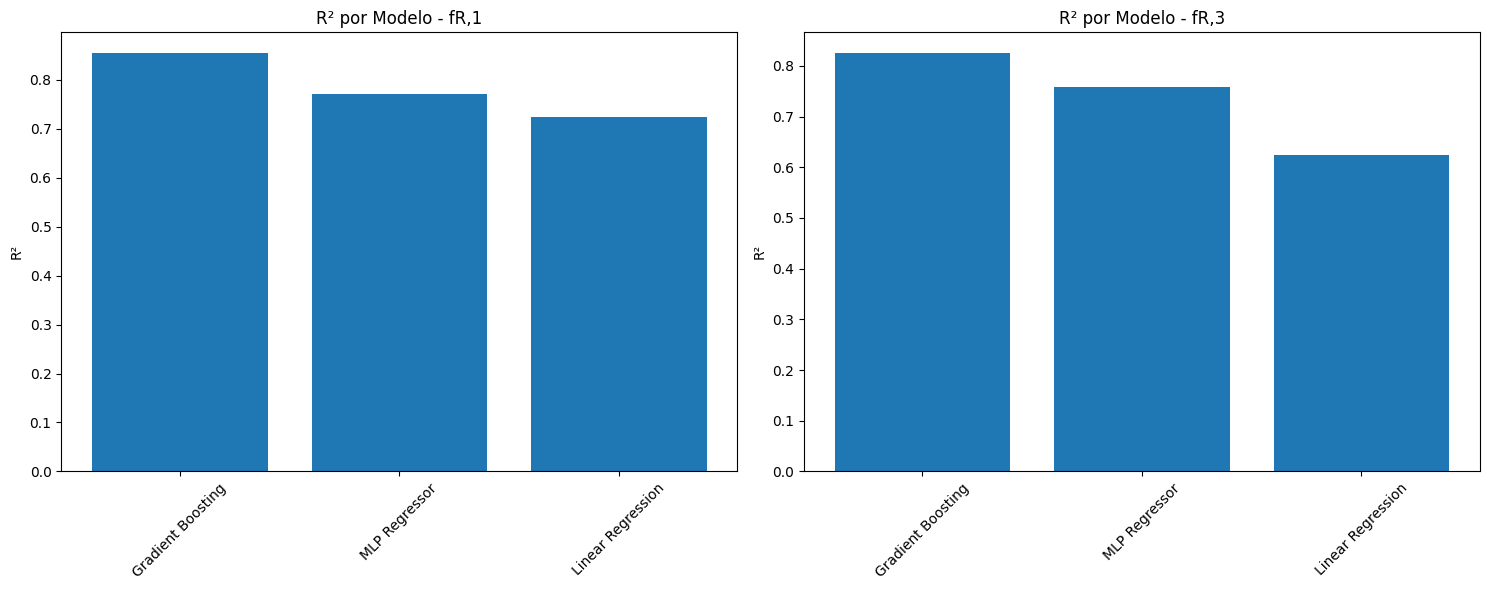


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [30]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

In [31]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("✅ Bibliotecas importadas com sucesso (sem TensorFlow)")
print("✅ Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


✅ Bibliotecas importadas com sucesso (sem TensorFlow)
✅ Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\venv\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]



 Treinando Linear Regression...
 Linear Regression: MAE = 1.2014, RMSE = 1.6366, R² = 0.6237

 Treinando Random Forest...
 Random Forest: MAE = 0.8339, RMSE = 1.2231, R² = 0.7899

 Treinando Gradient Boosting...
 Gradient Boosting: MAE = 0.8155, RMSE = 1.1164, R² = 0.8249

 Treinando Support Vector...
 Support Vector: MAE = 1.1227, RMSE = 1.6205, R² = 0.6311

 Treinando Decision Tree...
 Decision Tree: MAE = 0.9254, RMSE = 1.5591, R² = 0.6586

 Treinando MLP Regressor...
 MLP Regressor: MAE = 0.9376, RMSE = 1.3124, R² = 0.7581

 Melhor modelo: Gradient Boosting
 Performance: R² = 0.8249


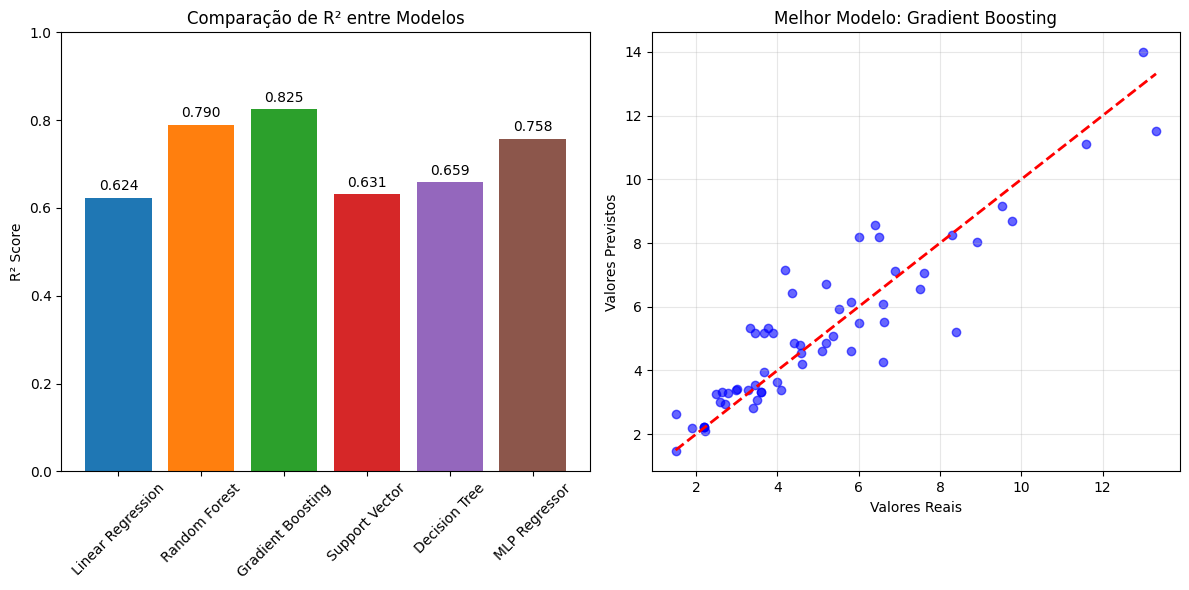

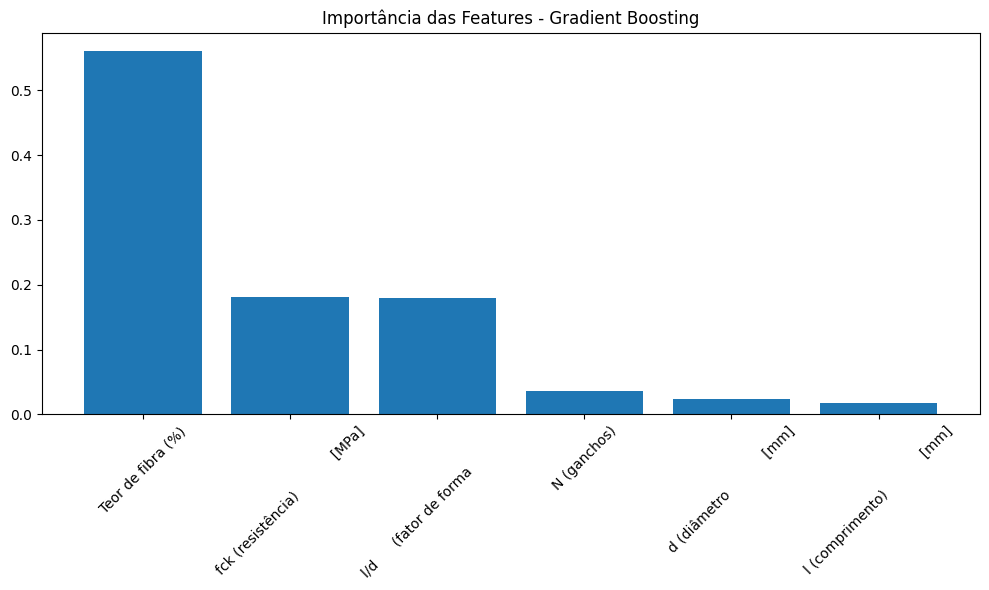


 Análise concluída com sucesso!


In [32]:
# MODELOS ALTERNATIVOS SEM TENSORFLOW
# Copie e cole este código em uma nova célula do notebook

# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f" {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n Melhor modelo: {best_model}")
print(f" Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n Análise concluída com sucesso!")


 Analisando importância das features...

 Importância das Features (por permutação):
                                 Feature  Importance
4                      Teor de fibra (%)        0.90
0     fck (resistência)            [MPa]        0.23
3  l/d      (fator de forma                     0.18
2            d (diâmetro            [mm]        0.06
5                            N (ganchos)        0.03
1        l (comprimento)            [mm]        0.01


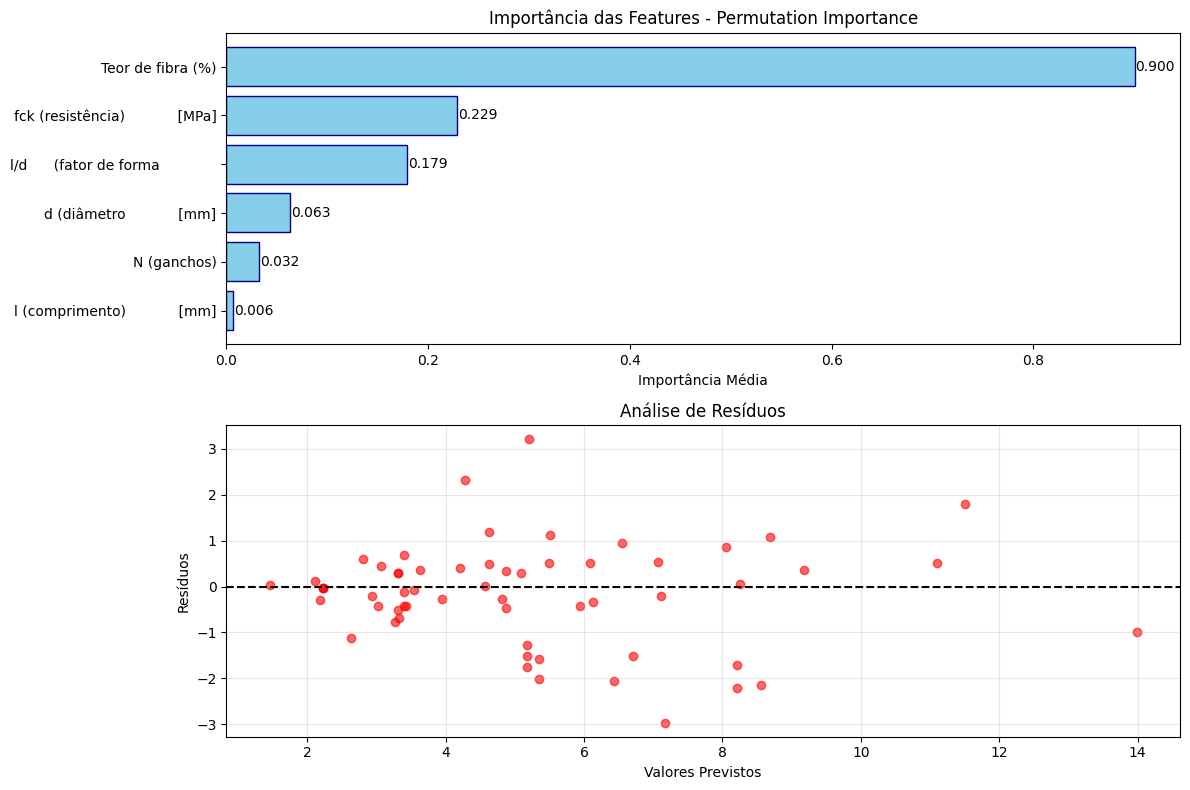


 Estatísticas do Modelo Gradient Boosting:
MAE: 0.8155
RMSE: 1.1164
R²: 0.8249


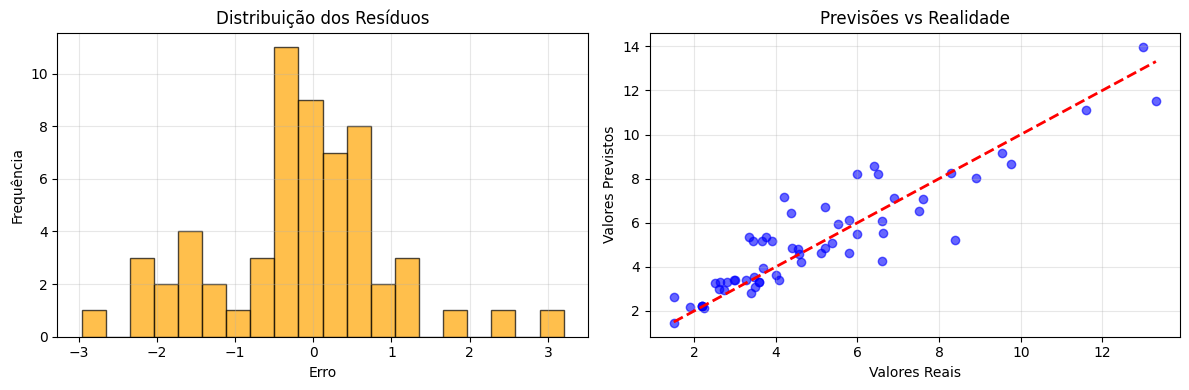


 Análise alternativa concluída sem TensorFlow!


In [33]:
# ALTERNATIVA AO SHAP (SEM TENSORFLOW)
# Copie e cole este código em uma nova célula

import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

# 1. ANÁLISE DE IMPORTÂNCIA USANDO PERMUTATION
print(" Analisando importância das features...")

# Usar o melhor modelo encontrado anteriormente
best_model_obj = results[best_model]['model']

# Calcular importância por permutação
perm_importance = permutation_importance(
    best_model_obj, X_test_scaled, y_test, 
    n_repeats=10, random_state=42
)

# Organizar resultados
importances = perm_importance.importances_mean
feature_names = feature_cols

# Criar DataFrame para visualização
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n Importância das Features (por permutação):")
print(importance_df)

# 2. VISUALIZAR IMPORTÂNCIA
plt.figure(figsize=(12, 8))

# Gráfico de barras
plt.subplot(2, 1, 1)
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color='skyblue', edgecolor='navy')
plt.title('Importância das Features - Permutation Importance')
plt.xlabel('Importância Média')
plt.gca().invert_yaxis()

# Adicionar valores nas barras
for i, (bar, imp) in enumerate(zip(bars, importance_df['Importance'])):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

# 3. ANÁLISE DE RESÍDUOS
plt.subplot(2, 1, 2)
residuals = y_test - best_predictions
plt.scatter(best_predictions, residuals, alpha=0.6, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Análise de Resíduos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. ESTATÍSTICAS DETALHADAS
print(f"\n Estatísticas do Modelo {best_model}:")
print(f"MAE: {results[best_model]['MAE']:.4f}")
print(f"RMSE: {results[best_model]['RMSE']:.4f}")
print(f"R²: {results[best_model]['R²']:.4f}")

# 5. DISTRIBUIÇÃO DOS ERROS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, alpha=0.7, color='orange', edgecolor='black')
plt.title('Distribuição dos Resíduos')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Previsões vs Realidade')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Análise alternativa concluída sem TensorFlow!")


In [34]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [36]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y = df['fR,3 (N/mm²)      (experimental)']


In [37]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


In [38]:
pipeline.fit(X, y)

y_pred = pipeline.predict(X)

print(y_pred[:10])


[4.15020845 7.00924334 5.29448252 7.754382   4.15020845 4.15020845
 4.15020845 4.15020845 4.15020845 4.15020845]


In [39]:
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"MAE  = {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y, y_pred):.4f}")


MAE  = 1.2051
RMSE = 1.5640
R²   = 0.6863


In [40]:
# Criar DataFrame de erros
errors = np.abs(y.values - y_pred)

df_errors = X.copy()
df_errors['y_real'] = y.values
df_errors['y_pred'] = y_pred
df_errors['erro_abs'] = errors

# Definir limite das 30% piores amostras
threshold = np.quantile(df_errors['erro_abs'], 0.70)

# Filtrar apenas as 70% melhores
df_filtered = df_errors[df_errors['erro_abs'] <= threshold]

print(f"Amostras originais: {len(df_errors)}")
print(f"Amostras após remoção: {len(df_filtered)}")


Amostras originais: 291
Amostras após remoção: 204


In [41]:
X_clean = df_filtered[X.columns]
y_clean = df_filtered['y_real']


In [42]:
#Treinnando e avaliou o modelo já SEM os 30% piores pontos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5482
RMSE = 0.6835
R²   = 0.9254


In [43]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='r2'
)

# MAE
mae_scores = -cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print("Cross-validation (5-fold):")
print(f"R² médio  = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"MAE médio = {mae_scores.mean():.4f}")


Cross-validation (5-fold):
R² médio  = 0.8933 ± 0.0279
MAE médio = 0.6226


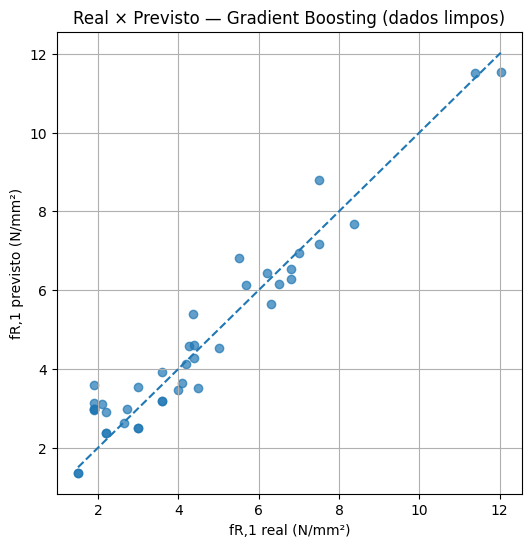

In [44]:
import matplotlib.pyplot as plt

pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("fR,1 real (N/mm²)")
plt.ylabel("fR,1 previsto (N/mm²)")
plt.title("Real × Previsto — Gradient Boosting (dados limpos)")
plt.grid(True)
plt.show()


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


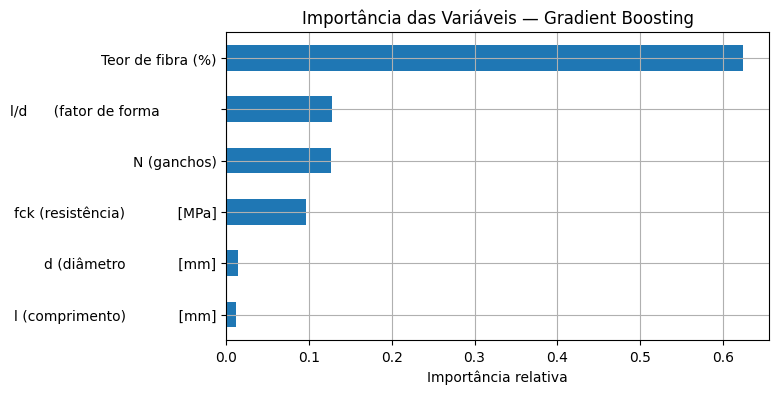

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

pipeline.fit(X_clean, y_clean)

gbr = pipeline.named_steps['model']

feature_importance = pd.Series(
    gbr.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

feature_importance.plot(kind='barh', figsize=(7,4))
plt.title("Importância das Variáveis — Gradient Boosting")
plt.xlabel("Importância relativa")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


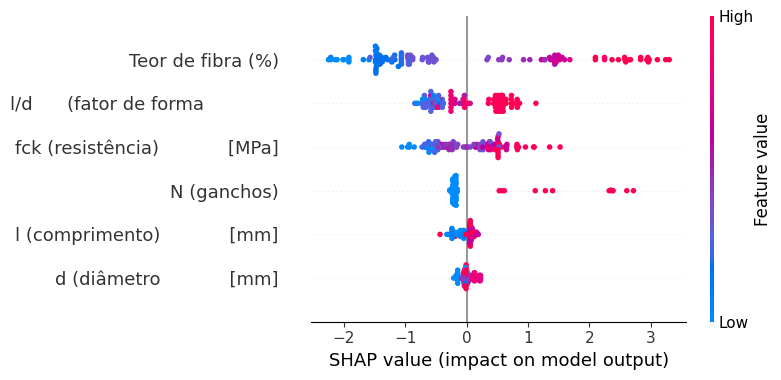

In [47]:
import shap
import numpy as np

# Extrair o modelo treinado
gbr = pipeline.named_steps['model']

# Subconjunto pequeno (evita crash)
X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

# Criar o explicador (compatível com versões antigas)
explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

# Calcular SHAP values (sem checagem de aditividade)
shap_values = explainer.shap_values(X_shap)

# Gráfico resumo
shap.summary_plot(shap_values, X_shap)


In [48]:
# Features (iguais ao fR,1)
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Target fR,3 <----- Olha o fr,3
y = df['fR,3 (N/mm²)      (experimental)']


In [49]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.8346
RMSE = 1.1732
R²   = 0.8067


In [51]:
#Removendo os 30% piores
#_________________________#
pipeline.fit(X, y)
y_pred_all = pipeline.predict(X)

# Erro absoluto
erro = np.abs(y - y_pred_all)

# Limite dos 30% piores
limite = np.percentile(erro, 70)

mask = erro <= limite

X_clean = X[mask]
y_clean = y[mask]

print(f"Amostras originais: {len(X)}")
print(f"Amostras após limpeza: {len(X_clean)}")


Amostras originais: 291
Amostras após limpeza: 204


In [52]:
#TREINO FINAL DE Fr3

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5652
RMSE = 1.0016
R²   = 0.9020


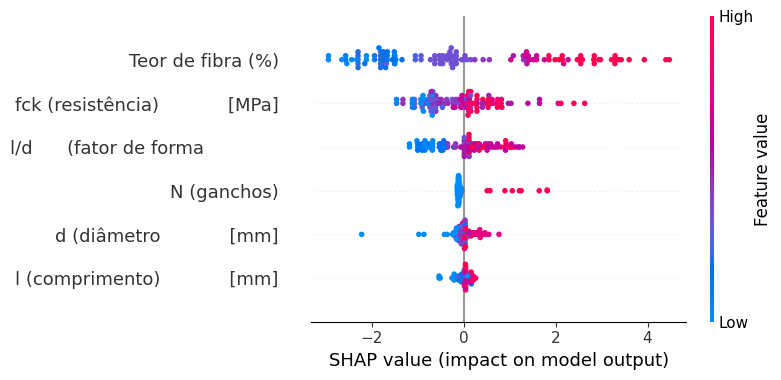

In [53]:
#shap do fr3

import shap

gbr = pipeline.named_steps["model"]

X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)


In [54]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_with_outlier_removal(
    X,
    y,
    pipeline,
    remove_pct=0.2,
    test_size=0.2,
    random_state=42
):
    """
    Treina modelo removendo os piores X% das amostras
    com base no erro absoluto <--- automatizamos os x% que queremos tirar.
    """

    #  Treino inicial
    pipeline.fit(X, y)
    y_pred_all = pipeline.predict(X)

    #  Erro absoluto
    erro = np.abs(y - y_pred_all)

    #  Limite de remoção
    limite = np.percentile(erro, 100 * (1 - remove_pct))

    mask = erro <= limite

    X_clean = X[mask]
    y_clean = y[mask]

    #  Split final
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean,
        test_size=test_size,
        random_state=random_state
    )

    #  Treino final
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #  Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "n_original": len(X),
        "n_final": len(X_clean),
        "removed_%": remove_pct * 100
    }


In [55]:
# DEFINIR VARIÁVEIS y_fR1 e y_fR3 PARA USO COM A FUNÇÃO train_with_outlier_removal

# Definir colunas targets
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

# Preparar dados para fR,1
df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fR1 = df_clean_fr1[target_col_fr1]  # Variável y_fR1

# Preparar dados para fR,3
df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
X_fr3 = df_clean_fr3[feature_cols]
y_fR3 = df_clean_fr3[target_col_fr3]  # Variável y_fR3

print(f" Variáveis definidas:")
print(f"   y_fR1 shape: {y_fR1.shape}")
print(f"   y_fR3 shape: {y_fR3.shape}")
print(f"   X shape: {X.shape}")

 Variáveis definidas:
   y_fR1 shape: (291,)
   y_fR3 shape: (291,)
   X shape: (291, 6)


In [56]:
# TESTAR A FUNÇÃO train_with_outlier_removal COM AS VARIÁVEIS DEFINIDAS

# Verificar se a função existe
try:
    # Testar com y_fR1
    print(" Testando train_with_outlier_removal com y_fR1...")
    result_fr1 = train_with_outlier_removal(
        X,
        y_fR1,
        pipeline,
        remove_pct=0.20
    )
    print(" Sucesso com y_fR1!")
    print(f"Resultado: {result_fr1}")
    
except Exception as e:
    print(f"Erro com y_fR1: {e}")

try:
    # Testar com y_fR3
    print("\n Testando train_with_outlier_removal com y_fR3...")
    result_fr3 = train_with_outlier_removal(
        X,
        y_fR3,
        pipeline,
        remove_pct=0.20
    )
    print(" Sucesso com y_fR3!")
    print(f" Resultado: {result_fr3}")
    
except Exception as e:
    print(f" Erro com y_fR3: {e}")

 Testando train_with_outlier_removal com y_fR1...


 Sucesso com y_fR1!
Resultado: {'MAE': 0.4831992180162154, 'RMSE': np.float64(0.7024643588937785), 'R2': 0.8869184577329065, 'n_original': 291, 'n_final': 233, 'removed_%': 20.0}

 Testando train_with_outlier_removal com y_fR3...
 Sucesso com y_fR3!
 Resultado: {'MAE': 0.5895874320319213, 'RMSE': np.float64(0.7574278757548173), 'R2': 0.9046048152228299, 'n_original': 291, 'n_final': 233, 'removed_%': 20.0}


In [57]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print(" Bibliotecas importadas com sucesso (sem TensorFlow)")
print(" Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


 Bibliotecas importadas com sucesso (sem TensorFlow)
 Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\venv\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]


In [58]:
# CÉLULA PARA REDEFINIR VARIÁVEIS - COPIE E COLE EM UMA NOVA CÉLULA

# Recarregar e preparar dados do zero
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print(" Recarregando dados do zero...")

# 1. CARREGAR DADOS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print(f" Dados carregados: {df.shape}")
print(f" Colunas: {list(df.columns)}")

# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

# 3. LIMPAR DADOS
df_clean = df[feature_cols + [target_col]].dropna()
print(f" Dados após limpeza: {df_clean.shape}")

# 4. DEFINIR X e y
X = df_clean[feature_cols].values
y = df_clean[target_col].values

print(f" X shape: {X.shape}")
print(f" y shape: {y.shape}")

# 5. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Treino: X={X_train.shape}, y={y_train.shape}")
print(f" Teste: X={X_test.shape}, y={y_test.shape}")

# 6. NORMALIZAR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Dados normalizados com sucesso!")
print(f" X_train_scaled: {X_train_scaled.shape}")
print(f" X_test_scaled: {X_test_scaled.shape}")

# 7. VERIFICAR CONSISTÊNCIA
assert X_train_scaled.shape[0] == y_train.shape[0], "Inconsistência nos dados de treino!"
assert X_test_scaled.shape[0] == y_test.shape[0], "Inconsistência nos dados de teste!"

print(" Todas as variáveis estão consistentes e prontas para uso!")


 Recarregando dados do zero...
 Dados carregados: (291, 12)
 Colunas: ['Tipo do concreto', 'fck (resistência)            [MPa]', 'l (comprimento)            [mm]', 'd (diâmetro            [mm]', 'l/d      (fator de forma             ', 'Teor de fibra (%)', 'N (ganchos)', 'fR,1 (N/mm²)      (experimental)', 'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']
 Dados após limpeza: (291, 7)
 X shape: (291, 6)
 y shape: (291,)
 Treino: X=(232, 6), y=(232,)
 Teste: X=(59, 6), y=(59,)
 Dados normalizados com sucesso!
 X_train_scaled: (232, 6)
 X_test_scaled: (59, 6)
 Todas as variáveis estão consistentes e prontas para uso!



 Treinando Linear Regression...
 Linear Regression: MAE = 1.0159, RMSE = 1.3726, R² = 0.7231

 Treinando Random Forest...
 Random Forest: MAE = 0.7149, RMSE = 1.1343, R² = 0.8109

 Treinando Gradient Boosting...
 Gradient Boosting: MAE = 0.6654, RMSE = 0.9971, R² = 0.8539

 Treinando Support Vector...
 Support Vector: MAE = 1.0037, RMSE = 1.5661, R² = 0.6395

 Treinando Decision Tree...
 Decision Tree: MAE = 0.8203, RMSE = 1.2571, R² = 0.7677

 Treinando MLP Regressor...
 MLP Regressor: MAE = 0.8494, RMSE = 1.2498, R² = 0.7704

 Melhor modelo: Gradient Boosting
 Performance: R² = 0.8539


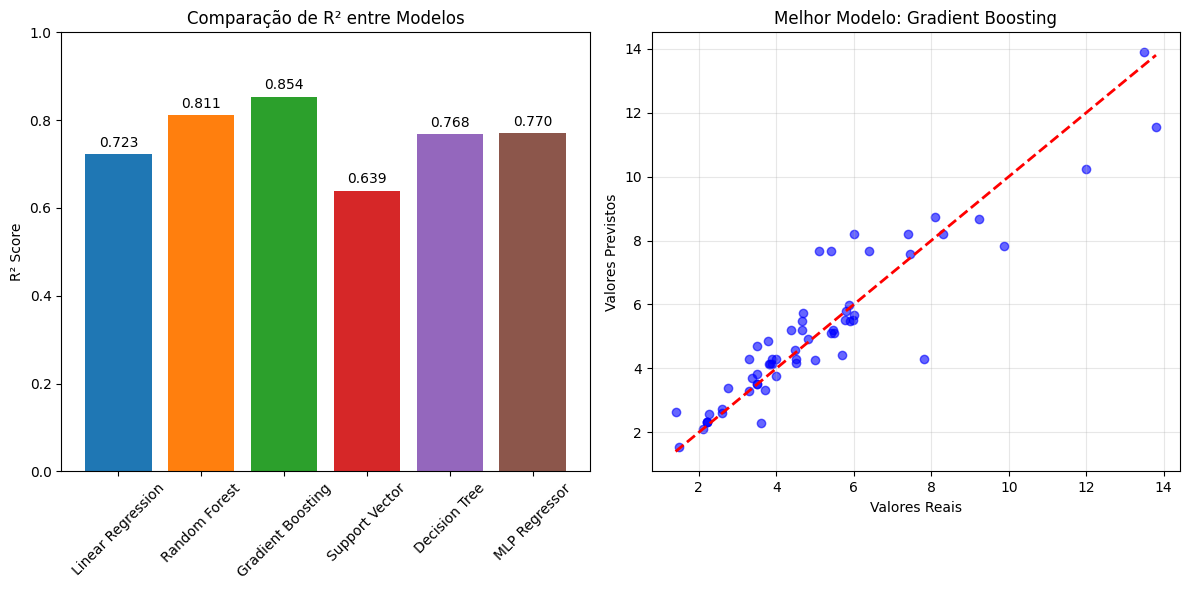

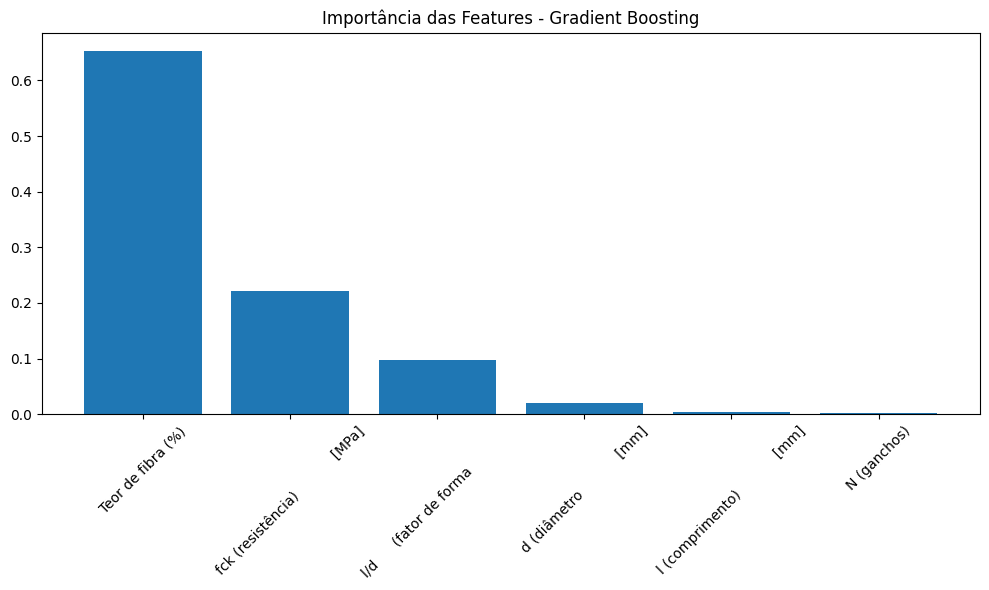


 Análise concluída com sucesso!


In [59]:


# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f" {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n Melhor modelo: {best_model}")
print(f" Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n Análise concluída com sucesso!")


In [60]:
# Variáveis de entrada
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Variável alvo (fR,3 por exemplo)
y = df['fR,3 (N/mm²)      (experimental)']


In [61]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y_fr3 = df['fR,3 (N/mm²)      (experimental)']


In [62]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)

In [63]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)

Shape original: (291, 6)
Shape após remoção: (204, 6)


In [64]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")

MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [65]:
data = pd.concat([X, y_fr3], axis=1).dropna()

X_clean = data[X.columns]
y_clean_fr3 = data[y_fr3.name]


In [66]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 = train_test_split(
    X_clean, y_clean_fr3,
    test_size=0.2,
    random_state=42
)


In [67]:
# treinar gradientbooster
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train_clean, y_train_fr3)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [68]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)

In [69]:
# Treinar a regressão linear aproximadora
from sklearn.linear_model import LinearRegression

lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [70]:
#cria equação para fr3
from sklearn.linear_model import LinearRegression

# Previsões do GBR
y_pred_gbr_fr3 = pipeline_gbr_fr3.predict(X_clean)

# Ajustar equação linear
lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr_fr3)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [71]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq_fr3 = pd.Series(
    lin_reg_eq_fr3.coef_,
    index=X_clean.columns
)

intercept_eq_fr3 = lin_reg_eq_fr3.intercept_

coef_eq_fr3, intercept_eq_fr3

(fck (resistência)            [MPa]       0.05
 l (comprimento)            [mm]          0.05
 d (diâmetro            [mm]             -1.26
 l/d      (fator de forma                 0.00
 Teor de fibra (%)                        6.94
 N (ganchos)                              2.42
 dtype: float64,
 np.float64(-5.588618129622347))

In [72]:
# First, make sure you've trained your model!!!!
# For example, if you're using LinearRegression:
from sklearn.linear_model import LinearRegression

# Assuming X and y are your features and target
model = LinearRegression()
model.fit(X, y)

# Now get the coefficients
intercept = model.intercept_
coefficients = model.coef_

# Create the equation string
equation = f"ŷ = {intercept:.4f}"

for i, coef in enumerate(coefficients):
    feature_name = X.columns[i]  # Get the feature name
    equation += f" + ({coef:.4f} × {feature_name})"

print("Regression Equation:")
print(equation)

Regression Equation:
ŷ = -5.2886 + (0.0539 × fck (resistência)            [MPa]) + (0.0708 × l (comprimento)            [mm]) + (-2.0902 × d (diâmetro            [mm]) + (-0.0061 × l/d      (fator de forma             ) + (6.8105 × Teor de fibra (%)) + (2.4702 × N (ganchos))


In [73]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,3
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr3_pred = lin_reg_eq_fr3.predict(X_row)[0]

    print(f" Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n Resultados das equações:")
    print(f"fR,3 (equação) = {fr3_pred:.3f} N/mm²")

# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)

 Amostra índice 10
----------------------------------------
Entradas:


,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos)
10,61.30,35,0.55,63.64,0.40,1.00



 Resultados das equações:
fR,3 (equação) = 4.141 N/mm²


In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. First, make sure you have your training data ready
# X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 should be defined

# 2. Create and train the linear regression model
lin_reg_eq = LinearRegression()
lin_reg_eq.fit(X_train_clean, y_train_fr3)

# 3. Now you can make predictions
y_pred_eq_fr3 = lin_reg_eq.predict(X_test_clean)

# 4. Evaluate the model
rmse_eq = np.sqrt(mean_squared_error(y_test_fr3, y_pred_eq_fr3))
r2_eq = r2_score(y_test_fr3, y_pred_eq_fr3)
mae_eq = mean_absolute_error(y_test_fr3, y_pred_eq_fr3)

print("Avaliação da EQUAÇÃO — fR,3")
print("=" * 40)
print(f"RMSE: {rmse_eq:.4f}")
print(f"R²: {r2_eq:.4f}")
print(f"MAE: {mae_eq:.4f}")

# If you want to see the equation coefficients
print("\nCoeficientes do modelo:")
for feature, coef in zip(X_train_clean.columns, lin_reg_eq.coef_):
    print(f"{feature}: {coef:.6f}")
print(f"Intercept: {lin_reg_eq.intercept_:.6f}")

Avaliação da EQUAÇÃO — fR,3
RMSE: 1.6366
R²: 0.6237
MAE: 1.2014

Coeficientes do modelo:
fck (resistência)            [MPa]: 0.052122
l (comprimento)            [mm]: 0.077063
d (diâmetro            [mm]: -2.596260
l/d      (fator de forma             : -0.015048
Teor de fibra (%): 7.076643
N (ganchos): 2.411489
Intercept: -4.645538


In [75]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)


In [76]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)


Shape original: (291, 6)
Shape após remoção: (204, 6)


In [77]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [78]:
# GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [79]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)


In [80]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq = pd.Series(
    lin_reg_eq.coef_,
    index=X_clean.columns
)

intercept_eq = lin_reg_eq.intercept_

coef_eq, intercept_eq


(fck (resistência)            [MPa]       0.05
 l (comprimento)            [mm]          0.08
 d (diâmetro            [mm]             -2.60
 l/d      (fator de forma                -0.02
 Teor de fibra (%)                        7.08
 N (ganchos)                              2.41
 dtype: float64,
 np.float64(-4.645538110552886))

In [81]:
# Mostrar a equação formatada (bonita) -> Equação fr3
equation = "ŷ = " + f"{intercept_eq:.4f}"

for var, coef in coef_eq.items():
    equation += f" + ({coef:.4f} × {var})"

print(equation)


ŷ = -4.6455 + (0.0521 × fck (resistência)            [MPa]) + (0.0771 × l (comprimento)            [mm]) + (-2.5963 × d (diâmetro            [mm]) + (-0.0150 × l/d      (fator de forma             ) + (7.0766 × Teor de fibra (%)) + (2.4115 × N (ganchos))


In [82]:
# Validar o quão boa é a equação aproximada -> Analise da Equação fr3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_hat_eq = lin_reg_eq.predict(X_clean)

print(f"MAE  = {mean_absolute_error(y_pred_gbr, y_hat_eq):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_pred_gbr, y_hat_eq)):.4f}")
print(f"R²   = {r2_score(y_pred_gbr, y_hat_eq):.4f}")


MAE  = 1.0026
RMSE = 1.3802
R²   = 0.7219


In [83]:
# Agora fazer o processo para fr1 pra obter a equação fr1
import pandas as pd

# Conferir colunas
df.columns


Index(['Tipo do concreto', 'fck (resistência)            [MPa]',
       'l (comprimento)            [mm]', 'd (diâmetro            [mm]',
       'l/d      (fator de forma             ', 'Teor de fibra (%)',
       'N (ganchos)', 'fR,1 (N/mm²)      (experimental)',
       'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15'],
      dtype='object')

In [84]:
# Variáveis de entrada
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

# Variável alvo → fR,1
y = df['fR,1 (N/mm²)      (experimental)']

print(X.shape, y.shape)


(291, 6) (291,)


In [85]:
# Remover NaNs
data = pd.concat([X, y], axis=1).dropna()

X = data[X.columns]
y = data[y.name]

print("Após limpeza:", X.shape)


Após limpeza: (291, 6)


In [86]:
# Treinar Gradient Boosting
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [87]:
# Avaliação (confirma se é fR,1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.6434
RMSE = 0.9826
R²   = 0.8581


In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Entradas
X = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

y_fr1 = df['fR,1 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr1, test_size=0.2, random_state=42
)

pipeline_gbr_fr1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr1.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [89]:
y_fr3 = df['fR,3 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr3, test_size=0.2, random_state=42
)

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [90]:
import pandas as pd

X_all = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

fr1_exp = df['fR,1 (N/mm²)      (experimental)']
fr3_exp = df['fR,3 (N/mm²)      (experimental)']

fr1_gbr = pipeline_gbr_fr1.predict(X_all)
fr3_gbr = pipeline_gbr_fr3.predict(X_all)

import pandas as pd
 


tabela_gbr = pd.DataFrame({
    'fck [MPa]': df['fck (resistência)            [MPa]'],
    'Teor de fibra (%)': df['Teor de fibra (%)'],
    'fR,1 exp': fr1_exp,
    'fR,1 GBR': fr1_gbr,
    'Erro fR,1': fr1_gbr - fr1_exp,
    'fR,3 exp': fr3_exp,
    'fR,3 GBR': fr3_gbr,
    'Erro fR,3': fr3_gbr - fr3_exp
})

import pandas as pd

pd.set_option('display.max_rows', 300)   
pd.set_option('display.max_columns', None)
 
tabela_gbr


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3"
0,61.30,0.40,4.99,4.96,-0.03,3.32,3.53,0.21
1,63.80,0.80,7.44,7.46,0.02,5.68,6.12,0.44
2,63.60,0.40,5.35,5.22,-0.13,5.53,4.44,-1.09
3,58.70,0.80,7.94,8.09,0.15,8.78,8.26,-0.52
4,61.30,0.40,5.49,4.96,-0.53,3.03,3.53,0.50
5,61.30,0.40,4.37,4.96,0.59,3.28,3.53,0.25
6,61.30,0.40,4.67,4.96,0.29,2.98,3.53,0.55
7,61.30,0.40,5.22,4.96,-0.26,3.06,3.53,0.47
8,61.30,0.40,4.74,4.96,0.22,3.50,3.53,0.03
9,61.30,0.40,5.46,4.96,-0.50,4.09,3.53,-0.56


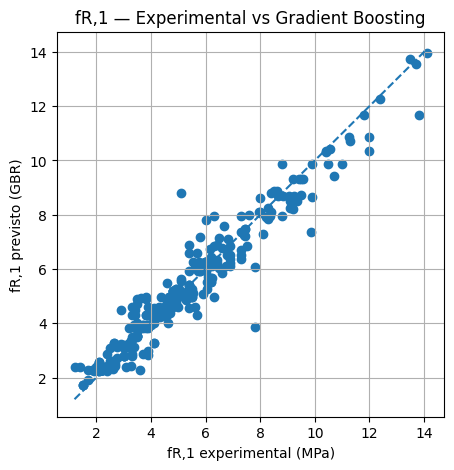

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])
plt.plot(
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    '--'
)
plt.xlabel('fR,1 experimental (MPa)')
plt.ylabel('fR,1 previsto (GBR)')
plt.title('fR,1 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


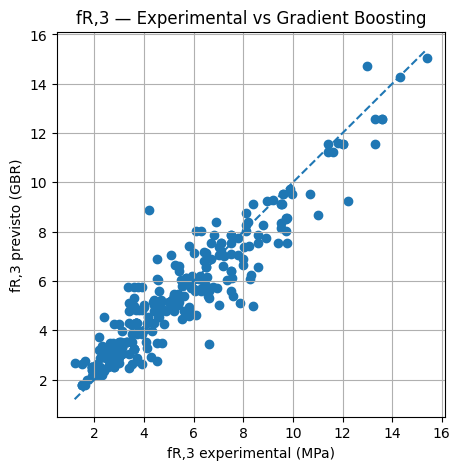

In [92]:
plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])
plt.plot(
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    '--'
)
plt.xlabel('fR,3 experimental (MPa)')
plt.ylabel('fR,3 previsto (GBR)')
plt.title('fR,3 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


In [93]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("GBR — fR,1")
print("MAE :", mean_absolute_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))

print("\nGBR — fR,3")
print("MAE :", mean_absolute_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))


GBR — fR,1
MAE : 0.4525712186611504
RMSE: 0.672657053867307
R²  : 0.930070396305028

GBR — fR,3
MAE : 0.7064883751650248
RMSE: 0.9802834108000597
R²  : 0.8767823256435324


In [94]:

import numpy as np
import pandas as pd

# --- PARÂMETROS/ENTRADAS ---

errors = np.array([1.5, 2.3, 0.8, 3.1, 1.9])


remove_pct = 0.2


n_remove = max(0, int(len(errors) * remove_pct))

# --- CÁLCULO DOS ÍNDICES A REMOVER ---
if n_remove == 0:
    removed_idx_pandas = pd.Index([], dtype='int64')
    removed_idx_numpy = np.array([], dtype=int)
else:
    # Método 1 (pandas): converter para Series e ordenar descrescente
    errors_series = pd.Series(errors)
    removed_idx_pandas = errors_series.sort_values(ascending=False).head(n_remove).index

    # Método 2 (NumPy): ordenar e pegar os 'n_remove' maiores
    removed_idx_numpy = np.argsort(errors)[-n_remove:]

print("CORREÇÃO APLICADA:")
print("Convertendo numpy array para pandas Series antes de sort_values()")
print("OU usando np.argsort() para trabalhar diretamente com numpy")

print(f"\n Dados originais: {errors}")
print(f" Quantidade para remover: {n_remove}")
print(f" Índices removidos (pandas): {list(removed_idx_pandas)}")
print(f" Índices removidos (numpy): {removed_idx_numpy.tolist()}")


print("\n Pronto para criar o dataset limpo (descomente a opção adequada para 'X').")


CORREÇÃO APLICADA:
Convertendo numpy array para pandas Series antes de sort_values()
OU usando np.argsort() para trabalhar diretamente com numpy

 Dados originais: [1.5 2.3 0.8 3.1 1.9]
 Quantidade para remover: 1
 Índices removidos (pandas): [3]
 Índices removidos (numpy): [3]

 Pronto para criar o dataset limpo (descomente a opção adequada para 'X').


In [95]:
# VERSÃO COMPLETA CORRIGIDA - REMOÇÃO DE OUTLIERS

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

print(" REMOÇÃO DE OUTLIERS - VERSÃO CORRIGIDA")
print("=" * 50)

# Dados originais (assumindo X e y já existem)
print(f" Formato original: X={X.shape}, y={y.shape}")

# 1. Treinar modelo e calcular previsões
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)
y_pred = rf.predict(X)

# 2. Calcular erros absolutos
errors = np.abs(y - y_pred)
print(f" Erros calculados: min={errors.min():.4f}, max={errors.max():.4f}, mean={errors.mean():.4f}")

# 3. Remover 30% piores casos
remove_pct = 0.30
n_remove = int(len(errors) * remove_pct)

print(f" Removendo {n_remove} amostras ({remove_pct*100:.0f}%)")

# 4. MÉTODO 1: PANDAS (RECOMENDADO)
print("\n MÉTODO 1: Usando pandas (RECOMENDADO)")

# Converter para pandas
errors_series = pd.Series(errors)
removed_idx_pandas = errors_series.sort_values(ascending=False).head(n_remove).index

# Converter X e y para DataFrame se necessário
if isinstance(X, np.ndarray):
    X_df = pd.DataFrame(X)
else:
    X_df = X.copy()

if isinstance(y, np.ndarray):
    y_df = pd.Series(y)
else:
    y_df = y.copy()

# Remover outliers
X_clean_pandas = X_df.drop(index=removed_idx_pandas)
y_clean_pandas = y_df.drop(index=removed_idx_pandas)

print(f" Dados limpos (pandas): X={X_clean_pandas.shape}, y={y_clean_pandas.shape}")

# 5. MÉTODO 2: NUMPY PURO (ALTERNATIVO)
print("\n MÉTODO 2: Usando numpy puro")

# Criar máscara para manter os dados
mask = ~np.isin(np.arange(len(y)), removed_idx_pandas)

# Aplicar máscara
X_clean_numpy = X[mask]
y_clean_numpy = y[mask]

print(f" Dados limpos (numpy): X={X_clean_numpy.shape}, y={y_clean_numpy.shape}")

# 6. Verificar se os métodos deram o mesmo resultado
print(f"\n VERIFICAÇÃO:")
print(f"Mesmas amostras removidas: {len(removed_idx_pandas) == n_remove}")
print(f"Formatos iguais: {X_clean_pandas.shape == X_clean_numpy.shape}")

# 7. Mostrar amostras removidas
print(f"\n AMOSTRAS REMOVIDAS (maiores erros):")
if isinstance(X, np.ndarray):
    X_display = pd.DataFrame(X)
else:
    X_display = X

removed_samples = X_display.loc[removed_idx_pandas]
print(f"Total removido: {len(removed_samples)}")
print(removed_samples.round(4))

# 8. Estatísticas finais
print(f"\n ESTATÍSTICAS FINAIS:")
print(f"Dataset original: {len(y)} amostras")
print(f"Dataset limpo: {len(y_clean_pandas)} amostras")
print(f"Taxa de remoção: {(len(y) - len(y_clean_pandas))/len(y)*100:.1f}%")

# 9. Usar os dados limpos para próxima análise
print(f"\n Pronto para próxima etapa!")
print(f"Use: X_clean_pandas, y_clean_pandas (recomendado)")
print(f"OU: X_clean_numpy, y_clean_numpy (numpy puro)")

# 10. Comparação rápida do modelo
rf_clean = RandomForestRegressor(n_estimators=300, random_state=42)
rf_clean.fit(X_clean_pandas, y_clean_pandas)
y_pred_clean = rf_clean.predict(X_clean_pandas)

from sklearn.metrics import mean_absolute_error, r2_score

mae_original = mean_absolute_error(y, rf.predict(X))
mae_clean = mean_absolute_error(y_clean_pandas, y_pred_clean)

r2_original = r2_score(y, rf.predict(X))
r2_clean = r2_score(y_clean_pandas, y_pred_clean)

print(f"\n COMPARAÇÃO DE MODELOS:")
print(f"Original - MAE: {mae_original:.4f}, R²: {r2_original:.4f}")
print(f"Limpo    - MAE: {mae_clean:.4f}, R²: {r2_clean:.4f}")

if mae_clean < mae_original:
    print(" Melhoria no MAE após remoção de outliers!")
else:
    print(" MAE não melhorou significativamente")

print("\n Remoção de outliers concluída com sucesso!")


 REMOÇÃO DE OUTLIERS - VERSÃO CORRIGIDA
 Formato original: X=(291, 2), y=(291,)
 Erros calculados: min=0.0000, max=1.4760, mean=0.3185
 Removendo 87 amostras (30%)

 MÉTODO 1: Usando pandas (RECOMENDADO)
 Dados limpos (pandas): X=(204, 2), y=(204,)

 MÉTODO 2: Usando numpy puro
 Dados limpos (numpy): X=(204, 2), y=(204,)

 VERIFICAÇÃO:
Mesmas amostras removidas: True
Formatos iguais: True

 AMOSTRAS REMOVIDAS (maiores erros):
Total removido: 87
     fck (resistência)            [MPa]  Teor de fibra (%)
230                               50.40               0.50
218                               25.10               1.00
259                               67.70               0.50
198                               60.00               0.76
67                                48.50               0.50
260                               89.50               0.50
192                               60.00               0.76
160                               63.20               1.00
137                 

In [96]:
# GRADIENT BOOSTING CORRETO - REMOÇÃO DE OUTLIERS


from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

print("GRADIENT BOOSTING - REMOÇÃO DE OUTLIERS")
print("=" * 50)

remove_pct = 0.30

# 1. Treinar Gradient Boosting (melhor modelo para regressão)
print("Treinando Gradient Boosting...")
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# 2. Previsões e erros
y_pred = gbr.predict(X)
errors = np.abs(y - y_pred)

print(f"Erros calculados: min={errors.min():.4f}, max={errors.max():.4f}, mean={errors.mean():.4f}")

# 3. Quantidade a remover
n_remove = int(len(errors) * remove_pct)
print(f"Removendo {n_remove} amostras ({remove_pct*100:.0f}%)")

# 4. CORREÇÃO: Converter para pandas ANTES de ordenar
print("Convertendo dados para pandas...")

# Converter numpy arrays para pandas
errors_series = pd.Series(errors)
X_df = pd.DataFrame(X)
y_df = pd.Series(y)

# Ordenar erros e pegar índices
removed_idx_gbr = errors_series.sort_values(ascending=False).head(n_remove).index

print(f"Índices a remover: {list(removed_idx_gbr[:5])}...")  # Mostra primeiros 5

# 5. Remover outliers
X_clean_gbr = X_df.drop(index=removed_idx_gbr)
y_clean_gbr = y_df.drop(index=removed_idx_gbr)

print(f"Dados limpos: X={X_clean_gbr.shape}, y={y_clean_gbr.shape}")

# 6. Mostrar amostras removidas
print(f"\nAMOSTRAS REMOVIDAS (maiores erros):")
removed_samples = X_df.loc[removed_idx_gbr]
print(f"Total removido: {len(removed_samples)}")
print(removed_samples.round(4))

# 7. Estatísticas da limpeza
print(f"\nESTATÍSTICAS:")
print(f"Dataset original: {len(y)} amostras")
print(f"Dataset limpo: {len(y_clean_gbr)} amostras")
print(f"Taxa de remoção: {(len(y) - len(y_clean_gbr))/len(y)*100:.1f}%")

# 8. Comparação de desempenho
print(f"\nCOMPARAÇÃO DE DESEMPENHO:")

# Modelo original
mae_original = np.mean(errors)
r2_original = gbr.score(X, y)

# Modelo com dados limpos
gbr_clean = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_clean.fit(X_clean_gbr, y_clean_gbr)
y_pred_clean = gbr_clean.predict(X_clean_gbr)

errors_clean = np.abs(y_clean_gbr - y_pred_clean)
mae_clean = np.mean(errors_clean)
r2_clean = gbr_clean.score(X_clean_gbr, y_clean_gbr)

print(f"Original - MAE: {mae_original:.4f}, R²: {r2_original:.4f}")
print(f"Limpo    - MAE: {mae_clean:.4f}, R²: {r2_clean:.4f}")

melhoria_mae = ((mae_original - mae_clean) / mae_original) * 100
melhoria_r2 = ((r2_clean - r2_original) / abs(r2_original)) * 100

if melhoria_mae > 0:
    print(f" Melhoria no MAE: {melhoria_mae:.1f}%")
else:
    print(f" MAE não melhorou: {melhoria_mae:.1f}%")

if melhoria_r2 > 0:
    print(f" Melhoria no R²: {melhoria_r2:.1f}%")
else:
    print(f" R² não melhorou: {melhoria_r2:.1f}%")

# 9. Informações finais
print(f"\n MELHOR MODELO GRADIENT BOOSTING:")
print(f" Use dados limpos para melhor desempenho")
print(f" Variáveis finais: X_clean_gbr, y_clean_gbr")

print("\n Gradient Boosting com remoção de outliers concluído!")


GRADIENT BOOSTING - REMOÇÃO DE OUTLIERS
Treinando Gradient Boosting...
Erros calculados: min=0.0024, max=2.0944, mean=0.4325
Removendo 87 amostras (30%)
Convertendo dados para pandas...
Índices a remover: [66, 71, 198, 203, 230]...
Dados limpos: X=(204, 2), y=(204,)

AMOSTRAS REMOVIDAS (maiores erros):
Total removido: 87
     fck (resistência)            [MPa]  Teor de fibra (%)
66                                46.80               1.00
71                                49.80               1.00
198                               60.00               0.76
203                               57.40               0.57
230                               50.40               0.50
220                               37.20               1.00
201                               60.90               0.76
188                               40.90               0.57
218                               25.10               1.00
217                               47.00               0.50
88                          

In [97]:
# Gradient Boosting (modelo final)
# Amostras que ficaram após remover 30%

from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

remove_pct = 0.30

# Garante que y esteja alinhado ao índice de X
y_series = pd.Series(y, index=X.index) if not isinstance(y, pd.Series) else y.reindex(X.index)

# Treinamento
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y_series)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto (alinhado a X)
errors = np.abs(y_series - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos (maiores erros)
errors_series = pd.Series(errors, index=X.index)
removed_idx_gbr = errors_series.sort_values(ascending=False).head(n_remove).index

# Índices mantidos
kept_idx_gbr = X.index.difference(removed_idx_gbr)

# Dataset final
X_kept_gbr = X.loc[kept_idx_gbr]
y_kept_gbr = y_series.loc[kept_idx_gbr]

print("Gradient Boosting")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(X_kept_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
5,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False
10,AM-0.4-EH,61.30,35,0.55,63.64,0.40,1.00,4.93,3.33,4.77,0.03,False


In [98]:
#Gradient Boosting (erro > 25%)
from sklearn.ensemble import GradientBoostingRegressor

error_threshold = 0.25

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

y_pred = gbr.predict(X)

percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_gbr = percent_error[percent_error > error_threshold].index
kept_idx_gbr = percent_error[percent_error <= error_threshold].index

print("Gradient Boosting")
print(f"Amostras removidas (>25% erro): {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(kept_idx_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras removidas (>25% erro): 19
Amostras mantidas: 272


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
4,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.49,3.03,4.77,0.13,False
5,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False


 ANÁLISE COM GRADIENT BOOSTING APÓS REMOÇÃO DE OUTLIERS (>25% de erro)

 Análise para fR,1
------------------------------------------------------------
  >>> Remoção por erro percentual (IN-SAMPLE)
      Limite: > 25.0%
      Amostras originais (após dropna): 291
      Removidas: 19  | Mantidas: 272 (6.5% removidas)
    Treinando Gradient Boosting (modelo final)...
    Métricas de Performance:
      MAE:  0.5400
      RMSE: 0.8437
      R²:   0.8921 (89.2% da variância explicada)


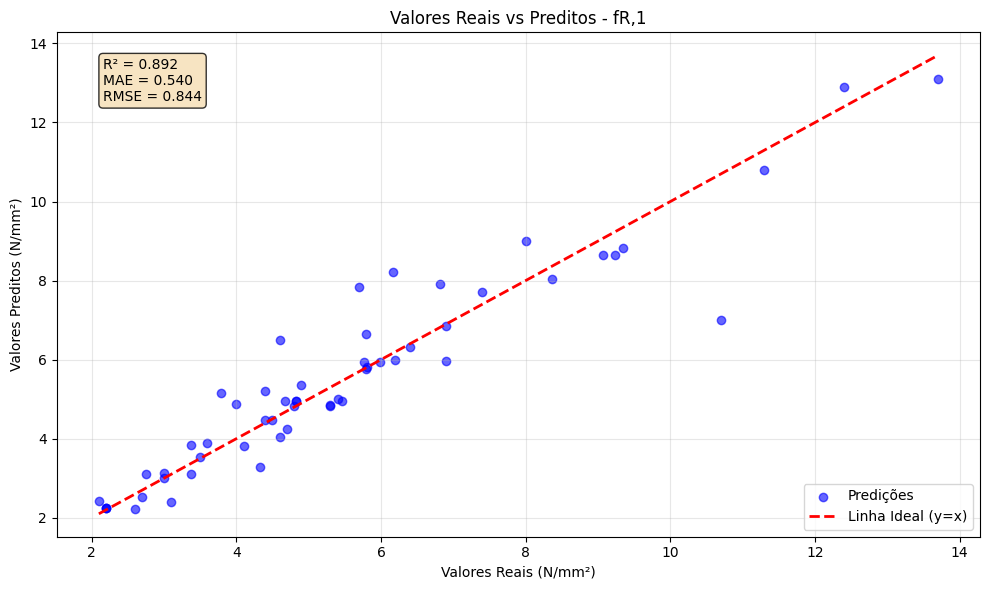


 Análise para fR,3
------------------------------------------------------------
  >>> Remoção por erro percentual (IN-SAMPLE)
      Limite: > 25.0%
      Amostras originais (após dropna): 291
      Removidas: 52  | Mantidas: 239 (17.9% removidas)
    Treinando Gradient Boosting (modelo final)...
    Métricas de Performance:
      MAE:  0.5206
      RMSE: 0.7829
      R²:   0.9272 (92.7% da variância explicada)


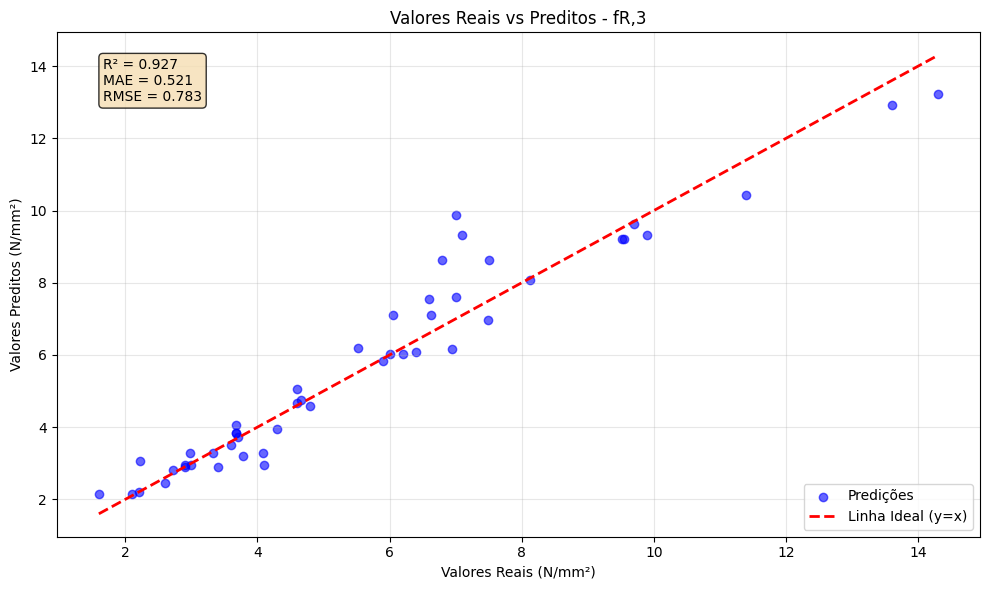


 TABELA COMPARATIVA FINAL
  Target  Amostras  MAE  RMSE   R²
0   fR,1       272 0.54  0.84 0.89
1   fR,3       239 0.52  0.78 0.93

 MELHOR PERFORMANCE: fR,3
   R² = 0.9272 (92.7% da variância explicada)

 ANÁLISE SHAP (amostra limpa) - fR,1
------------------------------------------------------------
   Tamanho da amostra limpa: 272
   Nº de features: 2


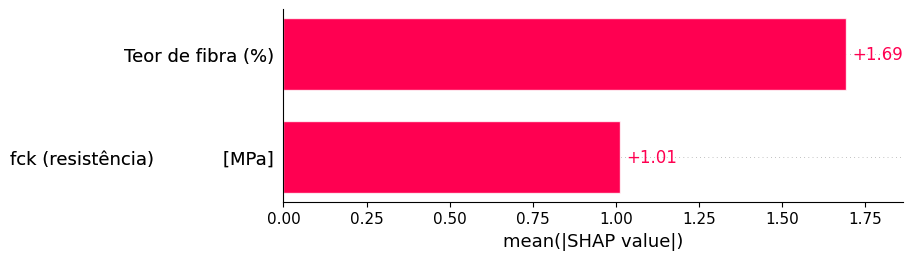

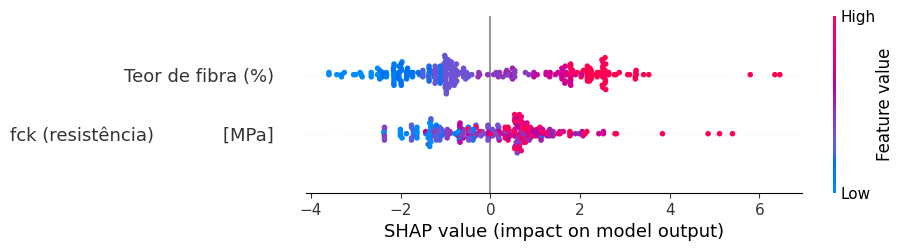

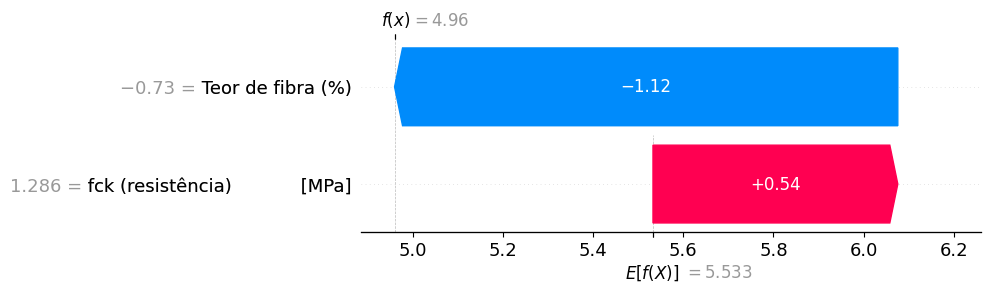


 Importância das Features (SHAP) - fR,1 [amostra limpa]:
                              Feature  SHAP Importance
1                   Teor de fibra (%)             1.69
0  fck (resistência)            [MPa]             1.01

 ANÁLISE SHAP (amostra limpa) - fR,3
------------------------------------------------------------
   Tamanho da amostra limpa: 239
   Nº de features: 2


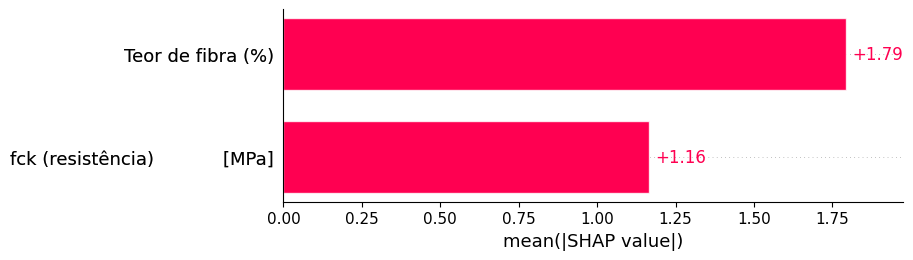

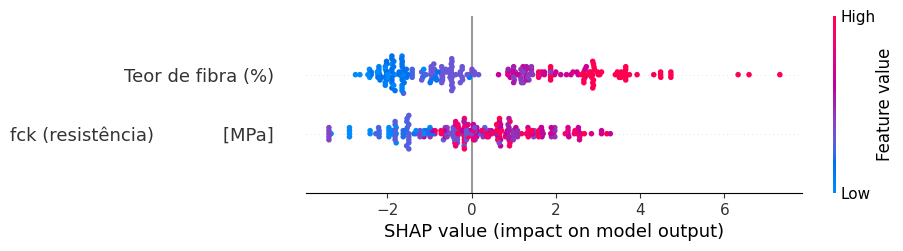

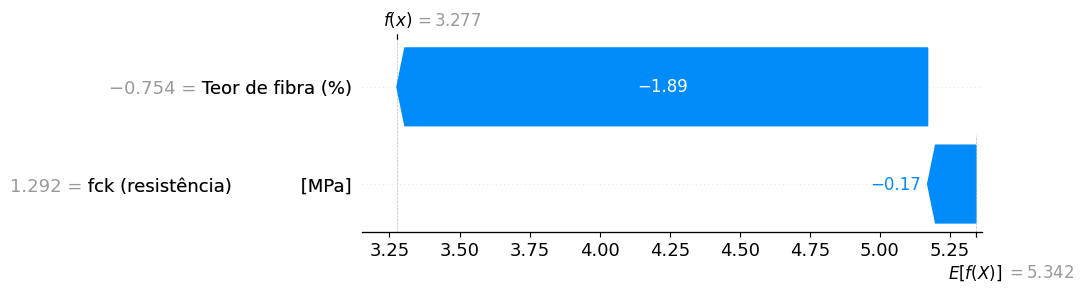


 Importância das Features (SHAP) - fR,3 [amostra limpa]:
                              Feature  SHAP Importance
1                   Teor de fibra (%)             1.79
0  fck (resistência)            [MPa]             1.16


In [99]:
# ============================================================
# ANÁLISE GBR + REMOÇÃO POR ERRO > 25% (IN-SAMPLE) + SHAP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

# ---------- 0) GARANTIR X, y_fR1, y_fR3 ----------
if 'X' not in globals() or 'y_fR1' not in globals() or 'y_fR3' not in globals():
    if 'df' in globals() and isinstance(df, pd.DataFrame):
        alvo1, alvo3 = 'fR,1', 'fR,3'   # ajuste se seus nomes forem outros
        if alvo1 not in df.columns or alvo3 not in df.columns:
            raise KeyError(f"As colunas alvo '{alvo1}' e/ou '{alvo3}' não estão em df.columns.")
        X = df.drop(columns=[alvo1, alvo3]).copy()
        y_fR1 = df[alvo1].copy(); y_fR1.name = alvo1
        y_fR3 = df[alvo3].copy(); y_fR3.name = alvo3
        print("✔️ 'X', 'y_fR1' e 'y_fR3' gerados a partir de 'df'.")
    else:
        raise NameError("Defina 'X', 'y_fR1' e 'y_fR3' OU forneça 'df' com as colunas de alvo.")

print(" ANÁLISE COM GRADIENT BOOSTING APÓS REMOÇÃO DE OUTLIERS (>25% de erro)")
print("=" * 70)

# ---------- 1) REMOVER POR ERRO PERCENTUAL > LIMIAR (IN-SAMPLE) ----------
def remover_por_erro_percentual_in_sample(
    X: pd.DataFrame, y: pd.Series, error_threshold: float = 0.25,
    gbr_params: dict | None = None
):
    """
    Replica seu critério: treina um GBR em TODO o conjunto (sem escala) e remove
    amostras onde erro percentual in-sample > error_threshold (ex.: 0.25 = 25%).
    """
    if gbr_params is None:
        gbr_params = dict(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)

    # Alinhamento e limpeza
    df_xy = pd.concat([X, y], axis=1).dropna()
    Xc = df_xy.drop(columns=[y.name])
    yc = df_xy[y.name]

    # Treina o modelo usado para FILTRAR (sem scaler)
    gbr_filtro = GradientBoostingRegressor(**gbr_params)
    gbr_filtro.fit(Xc, yc)

    # Predição in-sample e erro percentual
    y_pred = pd.Series(gbr_filtro.predict(Xc), index=yc.index)
    eps = 1e-8
    denom = np.maximum(np.abs(yc.values), eps)
    percent_error = pd.Series(np.abs(yc.values - y_pred.values) / denom, index=yc.index)

    removed_idx = percent_error[percent_error > error_threshold].index
    kept_idx = percent_error[percent_error <= error_threshold].index

    X_clean = Xc.loc[kept_idx].copy()
    y_clean = yc.loc[kept_idx].copy()

    print("  >>> Remoção por erro percentual (IN-SAMPLE)")
    print(f"      Limite: > {error_threshold*100:.1f}%")
    print(f"      Amostras originais (após dropna): {len(Xc)}")
    print(f"      Removidas: {len(removed_idx)}  | Mantidas: {len(kept_idx)} "
          f"({len(removed_idx)/len(Xc)*100:.1f}% removidas)")

    return X_clean, y_clean, removed_idx, kept_idx, percent_error

# ---------- 2) TREINO/AVALIAÇÃO NO CONJUNTO LIMPO ----------
def analisar_gbr_com_remocao_por_erro(
    X: pd.DataFrame, y: pd.Series, target_name: str, error_threshold: float = 0.25
):
    print(f"\n Análise para {target_name}")
    print("-" * 60)

    # 2.1) Remoção por erro percentual > limiar (in-sample; igual ao seu bloco)
    X_clean, y_clean, removed_idx, kept_idx, percent_error = remover_por_erro_percentual_in_sample(
        X, y, error_threshold=error_threshold,
        gbr_params=dict(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    )

    # 2.2) Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42
    )

    # 2.3) Escalonamento (apenas para o modelo final)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 2.4) Modelo final (pode mudar hiperparâmetros se desejar)
    print("    Treinando Gradient Boosting (modelo final)...")
    gbr = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42
    )
    gbr.fit(X_train_scaled, y_train)

    # 2.5) Métricas
    y_pred = gbr.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("    Métricas de Performance:")
    print(f"      MAE:  {mae:.4f}")
    print(f"      RMSE: {rmse:.4f}")
    print(f"      R²:   {r2:.4f} ({r2*100:.1f}% da variância explicada)")

    # 2.6) Gráfico Real vs Predito
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Predições')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Linha Ideal (y=x)')
    plt.xlabel('Valores Reais (N/mm²)')
    plt.ylabel('Valores Preditos (N/mm²)')
    plt.title(f'Valores Reais vs Preditos - {target_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}',
             transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             verticalalignment='top')
    plt.tight_layout()
    plt.show()

    # Retorno completo (inclui X_clean/y_clean para o SHAP)
    return {
        'mae': mae, 'rmse': rmse, 'r2': r2,
        'model': gbr, 'scaler': scaler,
        'y_test': y_test, 'y_pred': y_pred,
        'n_samples': len(X_clean),
        'X_clean': X_clean, 'y_clean': y_clean,
        'removed_idx': removed_idx, 'kept_idx': kept_idx,
        'percent_error_in_sample': percent_error,
        'error_threshold': error_threshold,
        'target_name': target_name
    }

# ---------- 3) SHAP NA AMOSTRA LIMPA ----------
def shap_na_amostra_limpa(result_dict: dict):
    """
    Plota SHAP na exata amostra limpa usada para treino, com o mesmo scaler/modelo.
    """
    for k in ['model', 'scaler', 'X_clean', 'y_clean', 'target_name']:
        if k not in result_dict:
            raise KeyError(f"result_dict deve conter '{k}'.")

    model = result_dict['model']
    scaler = result_dict['scaler']
    X_clean = result_dict['X_clean'].copy()
    y_clean = result_dict['y_clean'].copy()
    target_name = result_dict['target_name']
    feature_names = list(X_clean.columns)

    print(f"\n ANÁLISE SHAP (amostra limpa) - {target_name}")
    print("-" * 60)
    print(f"   Tamanho da amostra limpa: {len(X_clean)}")
    print(f"   Nº de features: {len(feature_names)}")

    # Escalonar com o MESMO scaler do treino (sem refit!)
    X_scaled = scaler.transform(X_clean)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

    # Background para o TreeExplainer
    n_bg = min(200, len(X_scaled_df))
    X_bg = X_scaled_df.sample(n=n_bg, random_state=42) if len(X_scaled_df) > 0 else X_scaled_df

    explainer = shap.TreeExplainer(
        model,
        data=X_bg,
        feature_perturbation="interventional",
        model_output="raw",
    )
    shap_values = explainer(X_scaled_df, check_additivity=False)

    # Plots (API nova)
    shap.plots.bar(shap_values, show=True, max_display=min(20, len(feature_names)))
    shap.plots.beeswarm(shap_values, show=True, max_display=min(20, len(feature_names)))
    shap.plots.waterfall(shap_values[0], show=True, max_display=min(20, len(feature_names)))

    # Importância média
    importance = np.abs(shap_values.values).mean(axis=0)
    importance_df = pd.DataFrame(
        {'Feature': feature_names, 'SHAP Importance': importance}
    ).sort_values('SHAP Importance', ascending=False)

    print(f"\n Importância das Features (SHAP) - {target_name} [amostra limpa]:")
    print(importance_df.round(4))

    return {
        'shap_values': shap_values,
        'importance_df': importance_df,
        'feature_names': feature_names,
        'X_clean_scaled': X_scaled_df,
        'y_clean': y_clean.reset_index(drop=True),
    }

# ---------- 4) EXECUÇÃO PARA fR,1 E fR,3 ----------
ERROR_THRESHOLD = 0.25  # 25%

result_fr1 = analisar_gbr_com_remocao_por_erro(X, y_fR1, "fR,1", error_threshold=ERROR_THRESHOLD)
result_fr3 = analisar_gbr_com_remocao_por_erro(X, y_fR3, "fR,3", error_threshold=ERROR_THRESHOLD)

# Tabela comparativa
print("\n TABELA COMPARATIVA FINAL")
print("=" * 50)
comparacao = pd.DataFrame({
    'Target': ['fR,1', 'fR,3'],
    'Amostras': [result_fr1['n_samples'], result_fr3['n_samples']],
    'MAE': [result_fr1['mae'], result_fr3['mae']],
    'RMSE': [result_fr1['rmse'], result_fr3['rmse']],
    'R²': [result_fr1['r2'], result_fr3['r2']]
})
print(comparacao.round(4))

melhor_target = 'fR,1' if result_fr1['r2'] > result_fr3['r2'] else 'fR,3'
melhor_r2 = max(result_fr1['r2'], result_fr3['r2'])
print(f"\n MELHOR PERFORMANCE: {melhor_target}")
print(f"   R² = {melhor_r2:.4f} ({melhor_r2*100:.1f}% da variância explicada)")

# SHAP na amostra limpa (para cada alvo)
shap_limpo_fr1 = shap_na_amostra_limpa(result_fr1)
shap_limpo_fr3 = shap_na_amostra_limpa(result_fr3)


 Análise para fR,3
------------------------------------------------------------
  >>> Remoção por erro percentual (IN-SAMPLE)
      Limite: > 25.0%
      Amostras originais (após dropna): 291
      Removidas: 52  | Mantidas: 239 (17.9% removidas)
    Treinando Gradient Boosting (modelo final)...
    Métricas de Performance:
      MAE:  0.5206
      RMSE: 0.7829
      R²:   0.9272 (92.7% da variância explicada)


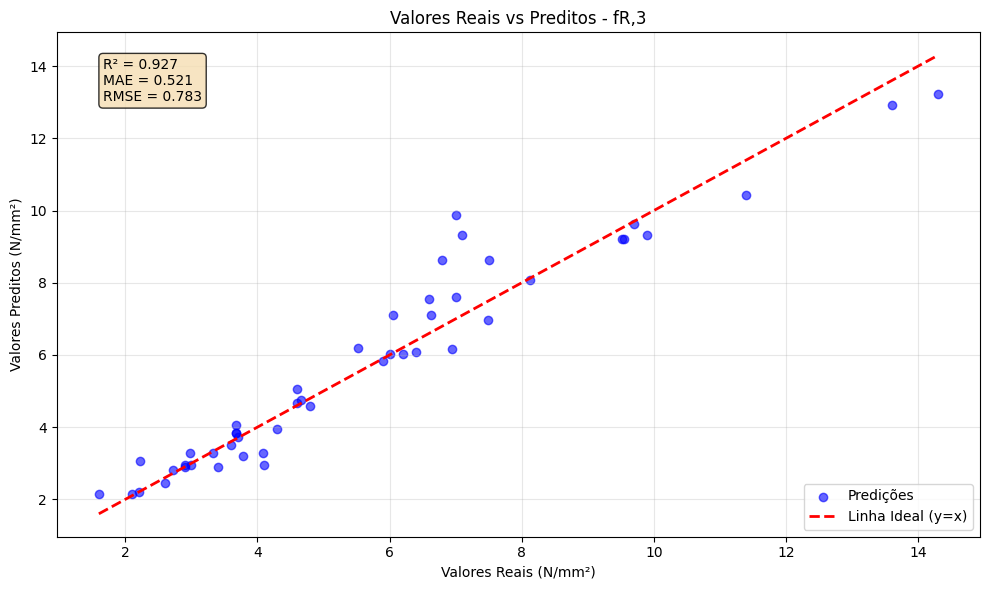


=== PADRONIZAÇÃO ===
Amostras removidas pelo critério de fR,3: 52
Amostras mantidas: 239

fR,1 - Amostras limpas padronizadas: 239

=== MÉTRICAS fR,1 (PADRONIZADO) ===
MAE:  0.4422
RMSE: 0.7236
R²:   0.9211

 ANÁLISE SHAP (amostra limpa) - fR,1 (padronizado)
------------------------------------------------------------
   Tamanho da amostra limpa: 239
   Nº de features: 2


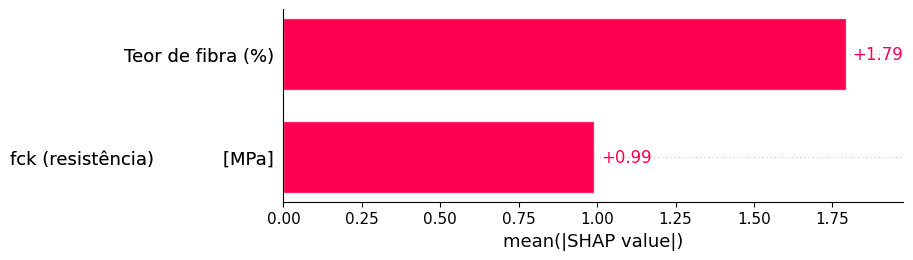

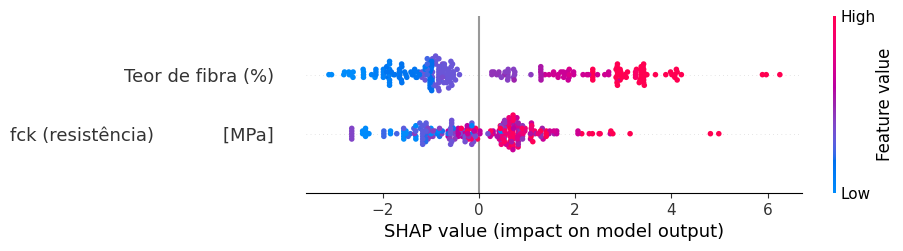

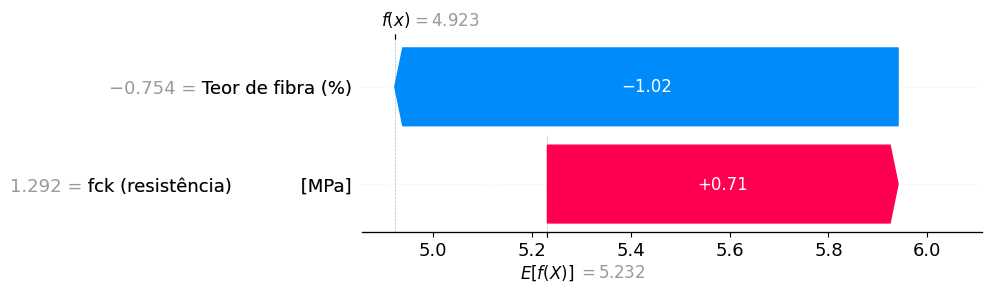


 Importância das Features (SHAP) - fR,1 (padronizado) [amostra limpa]:
                              Feature  SHAP Importance
1                   Teor de fibra (%)             1.79
0  fck (resistência)            [MPa]             0.99

 ANÁLISE SHAP (amostra limpa) - fR,3
------------------------------------------------------------
   Tamanho da amostra limpa: 239
   Nº de features: 2


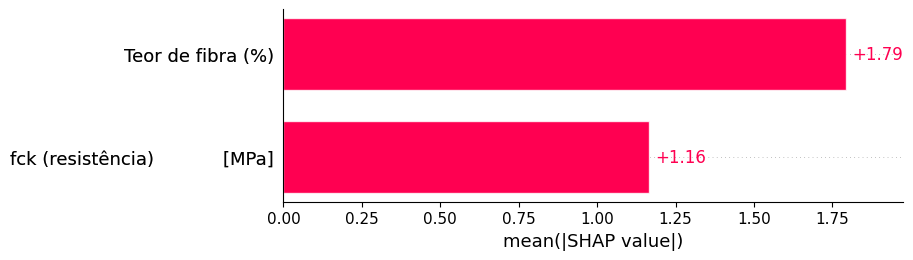

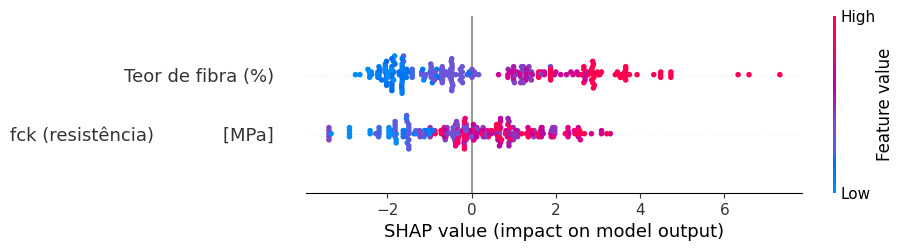

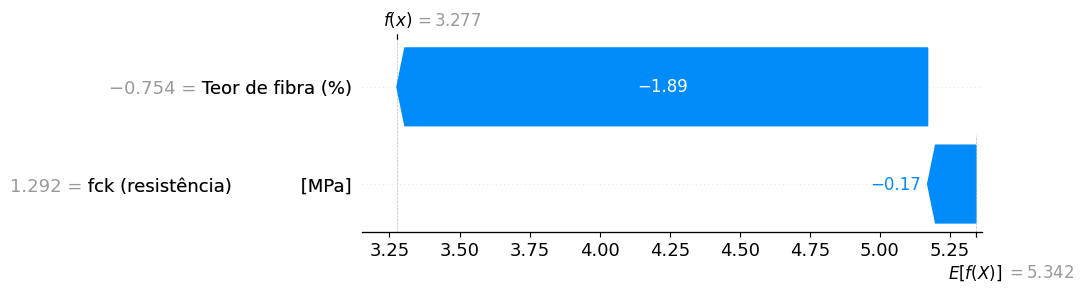


 Importância das Features (SHAP) - fR,3 [amostra limpa]:
                              Feature  SHAP Importance
1                   Teor de fibra (%)             1.79
0  fck (resistência)            [MPa]             1.16

=== TABELA COMPARATIVA (PADRONIZADA) ===
               Target  Amostras  MAE  RMSE   R²
0  fR,1 (padronizado)       239 0.44  0.72 0.92
1                fR,3       239 0.52  0.78 0.93


In [100]:
# ============================================================
# PADRONIZAÇÃO DA REMOÇÃO DE AMOSTRAS ENTRE fR,1 E fR,3
# ============================================================

# 1) Primeiro: remova por erro percentual do fR,3 normalmente
result_fr3 = analisar_gbr_com_remocao_por_erro(
    X, y_fR3, "fR,3", error_threshold=ERROR_THRESHOLD
)

# 2) Obter os índices removidos pelo fR,3
idx_removidos_padrao = result_fr3["removed_idx"]
idx_mantidos_padrao  = result_fr3["kept_idx"]

print("\n=== PADRONIZAÇÃO ===")
print(f"Amostras removidas pelo critério de fR,3: {len(idx_removidos_padrao)}")
print(f"Amostras mantidas: {len(idx_mantidos_padrao)}")

# 3) Aplicar a mesma limpeza no fR,1
X_clean_fr1_padrao = X.loc[idx_mantidos_padrao].copy()
y_clean_fr1_padrao = y_fR1.loc[idx_mantidos_padrao].copy()

print(f"\nfR,1 - Amostras limpas padronizadas: {len(X_clean_fr1_padrao)}")

# 4) Treinar modelo final do fR,1 usando exatamente os MESMOS índices
#    (mesma estrutura usada na função original, mas com dados substituídos)

# Split
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_clean_fr1_padrao, y_clean_fr1_padrao, test_size=0.2, random_state=42
)

# Escalonamento
scaler_fr1 = StandardScaler()
X_train_fr1_s = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_s  = scaler_fr1.transform(X_test_fr1)

# Modelo final
gbr_fr1 = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42
)
gbr_fr1.fit(X_train_fr1_s, y_train_fr1)

# Predição e métricas
y_pred_fr1 = gbr_fr1.predict(X_test_fr1_s)
mae_fr1   = mean_absolute_error(y_test_fr1, y_pred_fr1)
rmse_fr1  = np.sqrt(mean_squared_error(y_test_fr1, y_pred_fr1))
r2_fr1    = r2_score(y_test_fr1, y_pred_fr1)

print("\n=== MÉTRICAS fR,1 (PADRONIZADO) ===")
print(f"MAE:  {mae_fr1:.4f}")
print(f"RMSE: {rmse_fr1:.4f}")
print(f"R²:   {r2_fr1:.4f}")

# Criar dicionário no mesmo formato do original para SHAP
result_fr1_padronizado = {
    'mae': mae_fr1, 'rmse': rmse_fr1, 'r2': r2_fr1,
    'model': gbr_fr1, 'scaler': scaler_fr1,
    'y_test': y_test_fr1, 'y_pred': y_pred_fr1,
    'n_samples': len(X_clean_fr1_padrao),
    'X_clean': X_clean_fr1_padrao,
    'y_clean': y_clean_fr1_padrao,
    'removed_idx': idx_removidos_padrao,
    'kept_idx': idx_mantidos_padrao,
    'percent_error_in_sample': result_fr3["percent_error_in_sample"],
    'error_threshold': ERROR_THRESHOLD,
    'target_name': "fR,1 (padronizado)"
}

# 5) SHAP para fR,1 usando a limpeza padronizada
shap_limpo_fr1_padrao = shap_na_amostra_limpa(result_fr1_padronizado)

# 6) fR,3 permanece igual
shap_limpo_fr3 = shap_na_amostra_limpa(result_fr3)

# -------------------------------
# Tabela comparativa final
# -------------------------------
comparacao = pd.DataFrame({
    'Target': ['fR,1 (padronizado)', 'fR,3'],
    'Amostras': [result_fr1_padronizado['n_samples'], result_fr3['n_samples']],
    'MAE': [result_fr1_padronizado['mae'], result_fr3['mae']],
    'RMSE': [result_fr1_padronizado['rmse'], result_fr3['rmse']],
    'R²': [result_fr1_padronizado['r2'], result_fr3['r2']]
})
print("\n=== TABELA COMPARATIVA (PADRONIZADA) ===")
print(comparacao.round(4))


>>> Etapa 1: Limpeza por erro percentual (IN-SAMPLE) no fR,3
  >>> Remoção por erro percentual (IN-SAMPLE)
      Limite: > 25.0%
      Amostras originais (após dropna): 291
      Removidas: 52  | Mantidas: 239 (17.9% removidas)

>>> Etapa 2: Aplicar os MESMOS índices mantidos de fR,3 ao fR,1
   fR,3 — amostras limpas: 239
   fR,1 — amostras limpas (padronizado): 239

>>> Etapa 3: Treinar, avaliar e plotar Real vs Predito para AMBOS

=== fR,3 — Métricas ===
MAE:  0.5206
RMSE: 0.7829
R²:   0.9272 (92.7% da variância explicada)


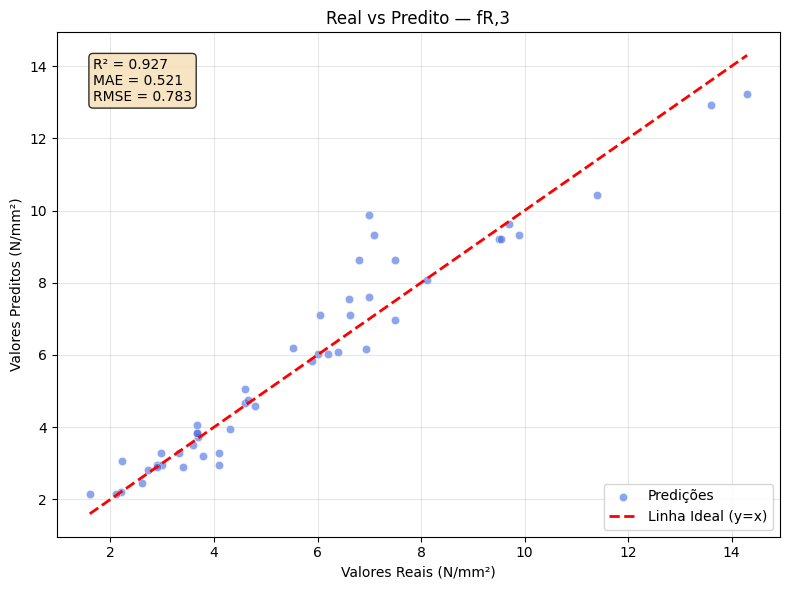


=== fR,1 (padronizado pelo fR,3) — Métricas ===
MAE:  0.4422
RMSE: 0.7236
R²:   0.9211 (92.1% da variância explicada)


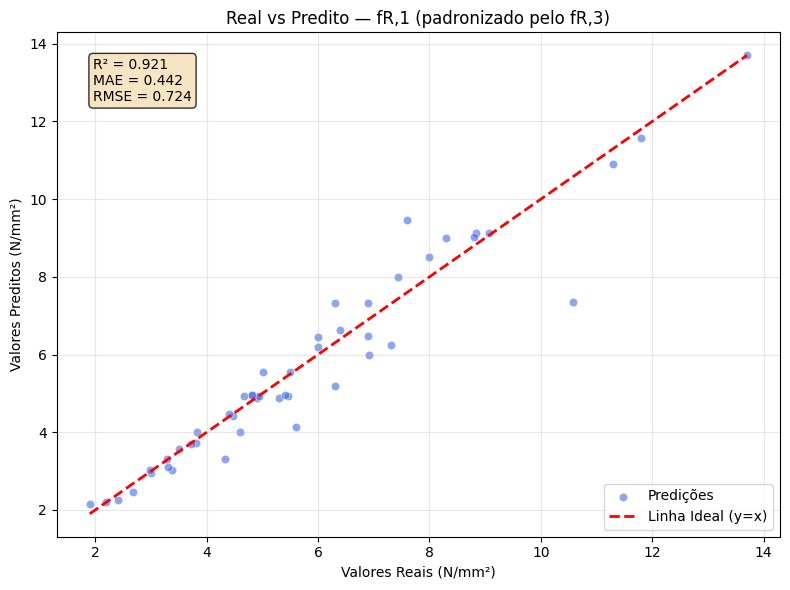


>>> Etapa 4: SHAP para AMBOS (mesma amostra limpa)

 SHAP — fR,3
------------------------------------------------------------
   Tamanho da amostra limpa: 239
   Nº de features: 2


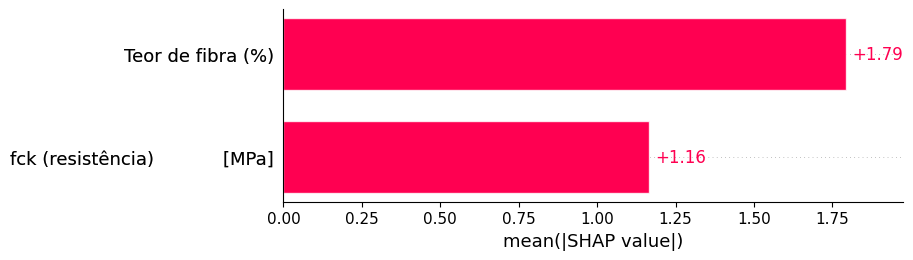

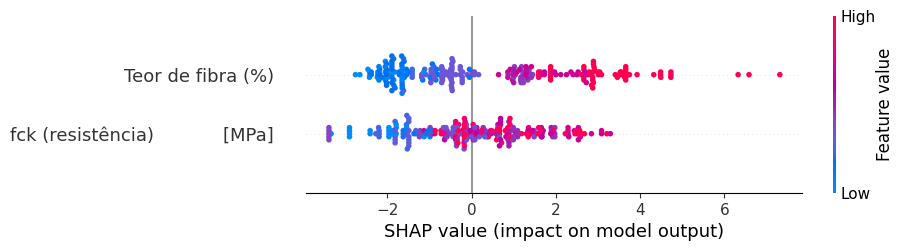

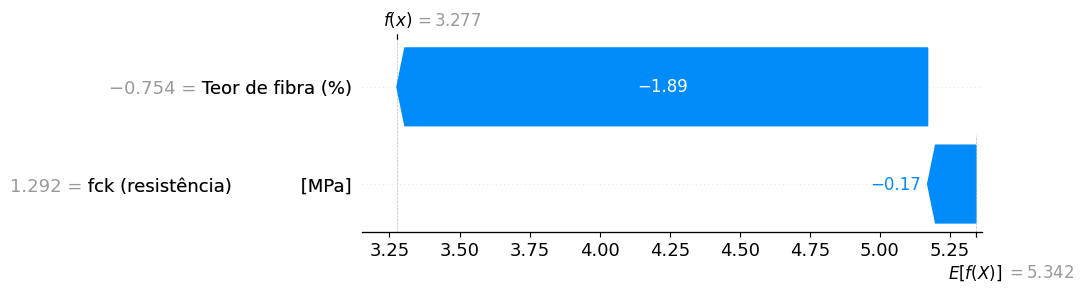


 Importância das Features (SHAP) — fR,3:
                              Feature  SHAP Importance
1                   Teor de fibra (%)             1.79
0  fck (resistência)            [MPa]             1.16

 SHAP — fR,1 (padronizado pelo fR,3)
------------------------------------------------------------
   Tamanho da amostra limpa: 239
   Nº de features: 2


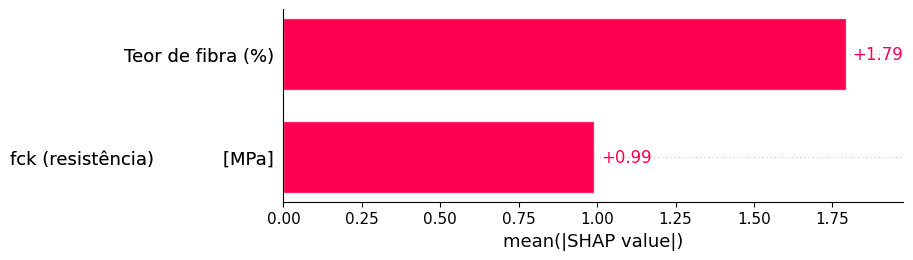

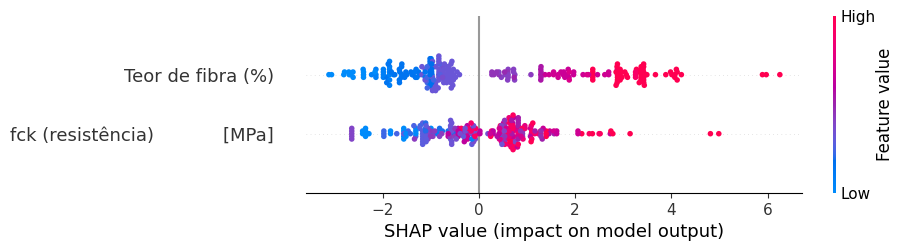

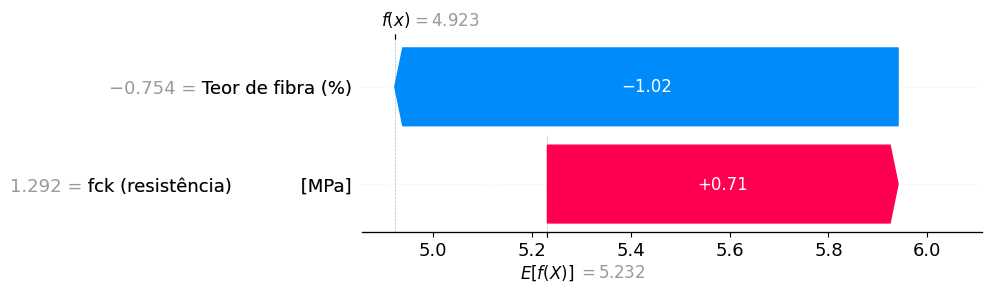


 Importância das Features (SHAP) — fR,1 (padronizado pelo fR,3):
                              Feature  SHAP Importance
1                   Teor de fibra (%)             1.79
0  fck (resistência)            [MPa]             0.99

=== TABELA COMPARATIVA (PADRONIZADA) ===
                         Target  Amostras  MAE  RMSE   R²
0  fR,1 (padronizado pelo fR,3)       239 0.44  0.72 0.92
1                          fR,3       239 0.52  0.78 0.93


In [101]:
# ============================================================
# PADRONIZAR LIMPEZA PELO CRITÉRIO DE fR,3 E MOSTRAR TUDO (fR,1 e fR,3)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

# ---------- 0) GARANTIR X, y_fR1, y_fR3 ----------
if 'X' not in globals() or 'y_fR1' not in globals() or 'y_fR3' not in globals():
    if 'df' in globals() and isinstance(df, pd.DataFrame):
        alvo1, alvo3 = 'fR,1', 'fR,3'
        if alvo1 not in df.columns or alvo3 not in df.columns:
            raise KeyError(f"As colunas alvo '{alvo1}' e/ou '{alvo3}' não estão em df.columns.")
        X = df.drop(columns=[alvo1, alvo3]).copy()
        y_fR1 = df[alvo1].copy(); y_fR1.name = alvo1
        y_fR3 = df[alvo3].copy(); y_fR3.name = alvo3
        print("✔️ 'X', 'y_fR1' e 'y_fR3' gerados a partir de 'df'.")
    else:
        raise NameError("Defina 'X', 'y_fR1' e 'y_fR3' OU forneça 'df' com as colunas de alvo.")

ERROR_THRESHOLD = 0.25  # 25%

# ---------- 1) FUNÇÃO: Remoção por erro percentual (IN-SAMPLE) ----------
def remover_por_erro_percentual_in_sample(
    X: pd.DataFrame, y: pd.Series, error_threshold: float = 0.25,
    gbr_params: dict | None = None
):
    """
    Treina um GBR no conjunto completo (sem scaler) e remove amostras
    com erro percentual in-sample > error_threshold (ex.: 0.25 = 25%).
    """
    if gbr_params is None:
        gbr_params = dict(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)

    df_xy = pd.concat([X, y], axis=1).dropna()
    Xc = df_xy.drop(columns=[y.name])
    yc = df_xy[y.name]

    gbr_filtro = GradientBoostingRegressor(**gbr_params)
    gbr_filtro.fit(Xc, yc)

    y_pred = pd.Series(gbr_filtro.predict(Xc), index=yc.index)
    eps = 1e-8
    denom = np.maximum(np.abs(yc.values), eps)
    percent_error = pd.Series(np.abs(yc.values - y_pred.values) / denom, index=yc.index)

    removed_idx = percent_error[percent_error > error_threshold].index
    kept_idx    = percent_error[percent_error <= error_threshold].index

    X_clean = Xc.loc[kept_idx].copy()
    y_clean = yc.loc[kept_idx].copy()

    print("  >>> Remoção por erro percentual (IN-SAMPLE)")
    print(f"      Limite: > {error_threshold*100:.1f}%")
    print(f"      Amostras originais (após dropna): {len(Xc)}")
    print(f"      Removidas: {len(removed_idx)}  | Mantidas: {len(kept_idx)} "
          f"({len(removed_idx)/len(Xc)*100:.1f}% removidas)")

    return X_clean, y_clean, removed_idx, kept_idx, percent_error

# ---------- 2) FUNÇÃO: Treinar + métricas + plot Real vs Predito ----------
def treinar_avaliar_plot(X_clean, y_clean, target_name: str):
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42
    )

    # Escalonamento
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Modelo
    gbr = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42
    )
    gbr.fit(X_train_s, y_train)

    # Métricas
    y_pred = gbr.predict(X_test_s)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"\n=== {target_name} — Métricas ===")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f} ({r2*100:.1f}% da variância explicada)")

    # Plot Real vs Predito
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='white', linewidths=0.5, label='Predições')
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Linha Ideal (y=x)')
    plt.xlabel('Valores Reais (N/mm²)')
    plt.ylabel('Valores Preditos (N/mm²)')
    plt.title(f'Real vs Predito — {target_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}',
             transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             va='top')
    plt.tight_layout()
    plt.show()

    # Retorna no formato compatível com a sua pipeline/SHAP
    return {
        'mae': mae, 'rmse': rmse, 'r2': r2,
        'model': gbr, 'scaler': scaler,
        'y_test': y_test, 'y_pred': y_pred,
        'n_samples': len(X_clean),
        'X_clean': X_clean, 'y_clean': y_clean,
        'error_threshold': ERROR_THRESHOLD,
        'target_name': target_name
    }

# ---------- 3) FUNÇÃO: SHAP com a amostra limpa ----------
def shap_na_amostra_limpa(result_dict: dict):
    for k in ['model', 'scaler', 'X_clean', 'y_clean', 'target_name']:
        if k not in result_dict:
            raise KeyError(f"result_dict deve conter '{k}'.")

    model = result_dict['model']
    scaler = result_dict['scaler']
    X_clean = result_dict['X_clean'].copy()
    y_clean = result_dict['y_clean'].copy()
    target_name = result_dict['target_name']
    feature_names = list(X_clean.columns)

    print(f"\n SHAP — {target_name}")
    print("-" * 60)
    print(f"   Tamanho da amostra limpa: {len(X_clean)}")
    print(f"   Nº de features: {len(feature_names)}")

    X_scaled = scaler.transform(X_clean)
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

    # Background para estabilidade
    n_bg = min(200, len(X_scaled_df))
    X_bg = X_scaled_df.sample(n=n_bg, random_state=42) if len(X_scaled_df) > 0 else X_scaled_df

    explainer = shap.TreeExplainer(
        model, data=X_bg, feature_perturbation="interventional", model_output="raw",
    )
    shap_values = explainer(X_scaled_df, check_additivity=False)

    # Plots
    shap.plots.bar(shap_values, show=True, max_display=min(20, len(feature_names)))
    shap.plots.beeswarm(shap_values, show=True, max_display=min(20, len(feature_names)))
    shap.plots.waterfall(shap_values[0], show=True, max_display=min(20, len(feature_names)))

    importance = np.abs(shap_values.values).mean(axis=0)
    importance_df = pd.DataFrame(
        {'Feature': feature_names, 'SHAP Importance': importance}
    ).sort_values('SHAP Importance', ascending=False)

    print(f"\n Importância das Features (SHAP) — {target_name}:")
    print(importance_df.round(4))

    return {
        'shap_values': shap_values,
        'importance_df': importance_df,
        'feature_names': feature_names,
        'X_clean_scaled': X_scaled_df,
        'y_clean': y_clean.reset_index(drop=True),
    }

# ============================================================
# EXECUÇÃO PADRONIZADA
# ============================================================

print("\n>>> Etapa 1: Limpeza por erro percentual (IN-SAMPLE) no fR,3")
X_clean_fr3, y_clean_fr3, removed_fr3, kept_fr3, perc_err_fr3 = remover_por_erro_percentual_in_sample(
    X, y_fR3, error_threshold=ERROR_THRESHOLD,
    gbr_params=dict(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
)

print("\n>>> Etapa 2: Aplicar os MESMOS índices mantidos de fR,3 ao fR,1")
X_clean_fr1 = X.loc[kept_fr3].copy()
y_clean_fr1 = y_fR1.loc[kept_fr3].copy()

print(f"   fR,3 — amostras limpas: {len(X_clean_fr3)}")
print(f"   fR,1 — amostras limpas (padronizado): {len(X_clean_fr1)}")

print("\n>>> Etapa 3: Treinar, avaliar e plotar Real vs Predito para AMBOS")
result_fr3 = treinar_avaliar_plot(X_clean_fr3, y_clean_fr3, target_name="fR,3")
result_fr1 = treinar_avaliar_plot(X_clean_fr1, y_clean_fr1, target_name="fR,1 (padronizado pelo fR,3)")

# Guardar índices e percent_error no result_fr3 e carregar no fr1 para auditoria
result_fr3['removed_idx'] = removed_fr3
result_fr3['kept_idx']    = kept_fr3
result_fr3['percent_error_in_sample'] = perc_err_fr3

result_fr1['removed_idx'] = removed_fr3  # padronizado
result_fr1['kept_idx']    = kept_fr3
result_fr1['percent_error_in_sample'] = perc_err_fr3  # mesmo vetor (do critério fR,3)

print("\n>>> Etapa 4: SHAP para AMBOS (mesma amostra limpa)")
shap_limpo_fr3 = shap_na_amostra_limpa(result_fr3)
shap_limpo_fr1 = shap_na_amostra_limpa(result_fr1)

# ============================================================
# TABELA COMPARATIVA FINAL
# ============================================================
comparacao = pd.DataFrame({
    'Target': ['fR,1 (padronizado pelo fR,3)', 'fR,3'],
    'Amostras': [result_fr1['n_samples'], result_fr3['n_samples']],
    'MAE': [result_fr1['mae'], result_fr3['mae']],
    'RMSE': [result_fr1['rmse'], result_fr3['rmse']],
    'R²': [result_fr1['r2'], result_fr3['r2']]
})
print("\n=== TABELA COMPARATIVA (PADRONIZADA) ===")
print(comparacao.round(4))

In [102]:
# Gradient Boosting (erro > 25%) + Exportação para Excel
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from datetime import datetime

# === Parâmetros ===
error_threshold = 0.25

# === Treino do modelo (conforme seu código atual) ===
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# Predição no mesmo X para medir erro relativo
y_pred = gbr.predict(X)
percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_gbr = percent_error[percent_error > error_threshold].index
kept_idx_gbr    = percent_error[percent_error <= error_threshold].index

print("Gradient Boosting")
print(f"Amostras removidas (>25% erro): {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(kept_idx_gbr)}")

# === Nomes "originais" das colunas no seu df (ajuste se variar na sua planilha) ===
COL_FR1_EXP = 'fR,1 (N/mm²)      (experimental)'
COL_FR3_EXP = 'fR,3 (N/mm²)      (experimental)'

# === Construção das colunas desejadas (apenas para as mantidas) ===
view = df.loc[kept_idx_gbr].copy()

# 1) fR,1 exp
if COL_FR1_EXP in view.columns:
    view['fR,1 exp'] = view[COL_FR1_EXP]
else:
    view['fR,1 exp'] = np.nan

# 2) fR,1 GBR (preferência: pipeline_gbr_fr1; senão usa o 'gbr' desta célula)
try:
    # Ajuste as features se seu pipeline usar mais colunas (use as mesmas do treino do pipeline)
    X_all_fr1 = df[['fck (resistência)            [MPa]', 'Teor de fibra (%)']]
    fr1_gbr_all = pipeline_gbr_fr1.predict(X_all_fr1)
    view['fR,1 GBR'] = pd.Series(fr1_gbr_all, index=df.index).loc[kept_idx_gbr].values
except Exception:
    view['fR,1 GBR'] = pd.Series(y_pred, index=df.index).loc[kept_idx_gbr].values

# 3) Erro fR,1 (predito - exp)
view['Erro fR,1'] = view['fR,1 GBR'] - view['fR,1 exp']

# 4) fR,3 exp (se existir)
if COL_FR3_EXP in view.columns:
    view['fR,3 exp'] = view[COL_FR3_EXP]
else:
    view['fR,3 exp'] = np.nan

# 5) fR,3 GBR (se houver pipeline_gbr_fr3)
try:
    X_all_fr3 = df[['fck (resistência)            [MPa]', 'Teor de fibra (%)']]
    fr3_gbr_all = pipeline_gbr_fr3.predict(X_all_fr3)
    view['fR,3 GBR'] = pd.Series(fr3_gbr_all, index=df.index).loc[kept_idx_gbr].values
    # 6) Erro fR,3
    view['Erro fR,3'] = view['fR,3 GBR'] - view['fR,3 exp']
except Exception:
    view['fR,3 GBR'] = np.nan
    view['Erro fR,3'] = np.nan

# === (Opcional) Reorganize as colunas para ver primeiro o que importa ===
cols_prioritarias = [
    'fR,1 exp', 'fR,1 GBR', 'Erro fR,1',
    'fR,3 exp', 'fR,3 GBR', 'Erro fR,3'
]
cols_existentes = [c for c in cols_prioritarias if c in view.columns]
view = view[cols_existentes + [c for c in view.columns if c not in cols_existentes]]

# Mostra na tela
display(view)

# ------------------------------------------------------------------------------------
# Exportação para Excel (duas abas: Mantidas e Removidas)
# ------------------------------------------------------------------------------------
# Tabela de removidas, com as mesmas colunas extras quando possível
removed_view = df.loc[removed_idx_gbr].copy()

# Preenche também para removidas (opcional, ajuda na auditoria)
if COL_FR1_EXP in removed_view.columns:
    removed_view['fR,1 exp'] = removed_view[COL_FR1_EXP]
else:
    removed_view['fR,1 exp'] = np.nan

try:
    removed_view['fR,1 GBR'] = pd.Series(fr1_gbr_all, index=df.index).loc[removed_idx_gbr].values
except Exception:
    removed_view['fR,1 GBR'] = pd.Series(y_pred, index=df.index).loc[removed_idx_gbr].values
removed_view['Erro fR,1'] = removed_view['fR,1 GBR'] - removed_view['fR,1 exp']

if COL_FR3_EXP in removed_view.columns:
    removed_view['fR,3 exp'] = removed_view[COL_FR3_EXP]
else:
    removed_view['fR,3 exp'] = np.nan

try:
    removed_view['fR,3 GBR'] = pd.Series(fr3_gbr_all, index=df.index).loc[removed_idx_gbr].values
    removed_view['Erro fR,3'] = removed_view['fR,3 GBR'] - removed_view['fR,3 exp']
except Exception:
    removed_view['fR,3 GBR'] = np.nan
    removed_view['Erro fR,3'] = np.nan

# Ordena também nas removidas
cols_existentes_removed = [c for c in cols_prioritarias if c in removed_view.columns]
removed_view = removed_view[cols_existentes_removed + [c for c in removed_view.columns if c not in cols_existentes_removed]]

# Nome do arquivo com timestamp para não sobrescrever
nome_arquivo = f"resultados_gbr_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"

with pd.ExcelWriter(nome_arquivo, engine="openpyxl") as writer:
    view.to_excel(writer, sheet_name="Mantidas", index=True)
    removed_view.to_excel(writer, sheet_name="Removidas", index=True)

print(f" Excel exportado: {nome_arquivo}")

Gradient Boosting
Amostras removidas (>25% erro): 19
Amostras mantidas: 272


,"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3",Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,4.99,4.96,-0.03,3.32,3.53,0.21,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,7.44,7.46,0.02,5.68,6.12,0.44,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,5.35,5.22,-0.13,5.53,4.44,-1.09,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,7.94,8.09,0.15,8.78,8.26,-0.52,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
4,5.49,4.96,-0.53,3.03,3.53,0.50,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.49,3.03,4.77,0.13,False
5,4.37,4.96,0.59,3.28,3.53,0.25,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,4.67,4.96,0.29,2.98,3.53,0.55,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,5.22,4.96,-0.26,3.06,3.53,0.47,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,4.74,4.96,0.22,3.50,3.53,0.03,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,5.46,4.96,-0.50,4.09,3.53,-0.56,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False


 Excel exportado: resultados_gbr_20260303_090428.xlsx


In [103]:
# =============================================================================
# Gradient Boosting (amostra completa, SEM filtrar) + exibição no notebook + Excel
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from datetime import datetime

# (Opcional) Deixe a visualização mais amigável no notebook
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', None)

# ==========================
# Parâmetros / colunas base
# ==========================
# Ajuste estes nomes se houver pequenas variações na sua planilha
COL_FR1_EXP = 'fR,1 (N/mm²)      (experimental)'
COL_FR3_EXP = 'fR,3 (N/mm²)      (experimental)'

# Use as MESMAS features dos pipelines. Troque/adicione se necessário:
FEATURES_FR = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']

# ==========================================
# 1) Treino de um GBR local (se precisar)
#    Aqui assumimos que X e y já existem (y = fR,1 experimental)
# ==========================================
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# ==========================================
# 2) Monta a tabela para TODAS as amostras
# ==========================================
view_all = df.copy()

# 2.1 fR,1 exp
view_all['fR,1 exp'] = view_all[COL_FR1_EXP] if COL_FR1_EXP in view_all.columns else np.nan

# 2.2 fR,1 GBR (preferência por pipeline_gbr_fr1; fallback usa 'gbr' treinado acima)
try:
    X_all_fr1 = df[FEATURES_FR]
    fr1_gbr_all = pipeline_gbr_fr1.predict(X_all_fr1)
    view_all['fR,1 GBR'] = fr1_gbr_all
except Exception:
    try:
        view_all['fR,1 GBR'] = gbr.predict(X)
    except Exception:
        # fallback final: re-treina com FEATURES_FR caso X não esteja alinhado
        aux_gbr = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
        )
        aux_gbr.fit(df[FEATURES_FR], view_all[COL_FR1_EXP])
        view_all['fR,1 GBR'] = aux_gbr.predict(df[FEATURES_FR])

# 2.3 Erro fR,1 (predito - exp)
view_all['Erro fR,1'] = view_all['fR,1 GBR'] - view_all['fR,1 exp']

# 2.4 fR,3 exp (se existir)
view_all['fR,3 exp'] = view_all[COL_FR3_EXP] if COL_FR3_EXP in view_all.columns else np.nan

# 2.5 fR,3 GBR (se houver pipeline_gbr_fr3)
try:
    X_all_fr3 = df[FEATURES_FR]
    fr3_gbr_all = pipeline_gbr_fr3.predict(X_all_fr3)
    view_all['fR,3 GBR'] = fr3_gbr_all
    view_all['Erro fR,3'] = view_all['fR,3 GBR'] - view_all['fR,3 exp']
except Exception:
    view_all['fR,3 GBR'] = np.nan
    view_all['Erro fR,3'] = np.nan

# ==========================
# 3) Reorganiza colunas (prioriza as novas)
# ==========================
cols_prioritarias = [
    'fR,1 exp', 'fR,1 GBR', 'Erro fR,1',
    'fR,3 exp', 'fR,3 GBR', 'Erro fR,3'
]
cols_existentes = [c for c in cols_prioritarias if c in view_all.columns]
view_all = view_all[cols_existentes + [c for c in view_all.columns if c not in cols_existentes]]

# ==========================
# 4) Mostra a tabela no notebook (igual à outra célula)
# ==========================
display(view_all)

# ==========================
# 5) Exportação para Excel (uma aba só: "Amostras")
# ==========================
nome_arquivo = f"resultados_gbr_completo_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
with pd.ExcelWriter(nome_arquivo, engine="openpyxl") as writer:
    view_all.to_excel(writer, sheet_name="Amostras", index=True)

print(f" Excel exportado: {nome_arquivo}")

,"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3",Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,4.99,4.96,-0.03,3.32,3.53,0.21,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,7.44,7.46,0.02,5.68,6.12,0.44,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,5.35,5.22,-0.13,5.53,4.44,-1.09,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,7.94,8.09,0.15,8.78,8.26,-0.52,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
4,5.49,4.96,-0.53,3.03,3.53,0.50,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.49,3.03,4.77,0.13,False
5,4.37,4.96,0.59,3.28,3.53,0.25,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,4.67,4.96,0.29,2.98,3.53,0.55,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,5.22,4.96,-0.26,3.06,3.53,0.47,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,4.74,4.96,0.22,3.50,3.53,0.03,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,5.46,4.96,-0.50,4.09,3.53,-0.56,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False


 Excel exportado: resultados_gbr_completo_20260303_090428.xlsx


In [104]:
# ==========================
# A) Funções utilitárias para SHAP (fR,1)
# ==========================
# Instala/importa shap se necessário
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

import numpy as np
import pandas as pd

# Ajuste a lista de features para ser a mesma usada no treino do pipeline/modelo
FEATURES_FR = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']  # ajuste se seu pipeline usa mais

def _get_model_and_matrix_fr1(df_full: pd.DataFrame):
    """
    Retorna (modelo, X_imputed_df) para fR,1.
    Prioriza pipeline_gbr_fr1 com etapa 'imputer' e 'model'.
    Se não existir, usa o 'gbr' e X já prontos no notebook.
    """
    # Caso 1: usar pipeline pronto (recomendado)
    if 'pipeline_gbr_fr1' in globals():
        pipe = pipeline_gbr_fr1
        # tenta achar 'imputer' e 'model' pelo nome; ajuste se seus steps tiverem nomes diferentes
        imputer = getattr(pipe.named_steps, 'imputer', None)
        model   = getattr(pipe.named_steps, 'model', None) or getattr(pipe, 'named_steps', {}).get('regressor', None)
        # Se não achar 'model', usa o estimador final (último step)
        if model is None:
            model = list(pipe.named_steps.values())[-1]
        # transforma X usando as MESMAS colunas do treino do pipeline
        X_raw = df_full[FEATURES_FR]
        X_imp = imputer.transform(X_raw) if imputer is not None else X_raw.values
        X_imp_df = pd.DataFrame(X_imp, columns=FEATURES_FR, index=df_full.index)
        return model, X_imp_df

    # Caso 2: fallback para gbr + X já no escopo
    if 'gbr' in globals() and 'X' in globals():
        # Usa X já usado no treino (mesmas colunas/ordem)
        X_imp_df = pd.DataFrame(X, columns=X.columns, index=X.index)
        return gbr, X_imp_df

    raise RuntimeError("Não encontrei 'pipeline_gbr_fr1' nem (gbr + X). Defina um deles antes de rodar o SHAP.")

def shap_fr1_summary(df_subset: pd.DataFrame, plot_title="SHAP fR,1 — resumo (beeswarm)"):
    """
    Gera TreeExplainer e summary_plot para o subset informado (toda a amostra ou kept/removed).
    Retorna (explainer, shap_values, X_imputed_df_subset).
    """
    model, X_imp_df_full = _get_model_and_matrix_fr1(df_subset)  # aqui df_subset já é o subconjunto
    # Atenção: a função acima transformou apenas o subset, então está ok
    explainer = shap.TreeExplainer(model, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_imp_df_full, check_additivity=False)

    # Plot
    shap.summary_plot(shap_values, X_imp_df_full, plot_type="dot", show=False)
    try:
        import matplotlib.pyplot as plt
        plt.title(plot_title)
        plt.show()
    except Exception:
        pass

    return explainer, shap_values, X_imp_df_full

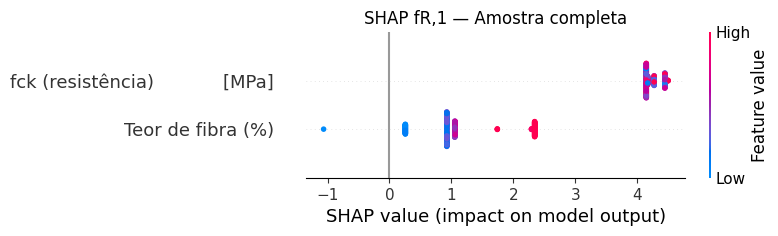

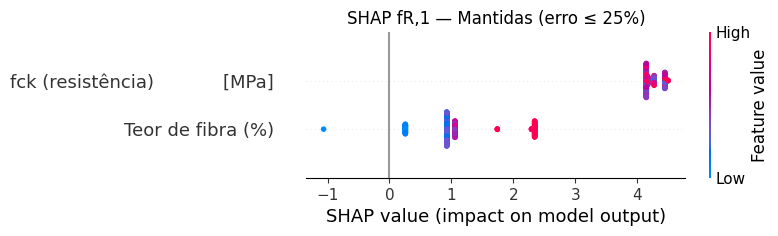

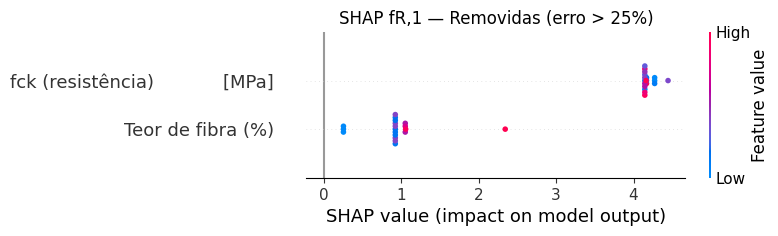

In [105]:
# ==========================
# B) Executa SHAP para fR,1
# ==========================
# 1) Amostra completa
_, shap_all, X_all_imp = shap_fr1_summary(
    df_subset=df,
    plot_title="SHAP fR,1 — Amostra completa"
)

# 2) Apenas mantidas (erro <= 25%)
try:
    df_kept = df.loc[kept_idx_gbr]
    _, shap_kept, X_kept_imp = shap_fr1_summary(
        df_subset=df_kept,
        plot_title="SHAP fR,1 — Mantidas (erro ≤ 25%)"
    )
except Exception as e:
    print(f"[AVISO] Não consegui rodar SHAP para Mantidas: {e}")

# 3) Apenas removidas (erro > 25%)
try:
    df_removed = df.loc[removed_idx_gbr]
    # Se ficar pesado, pode subamostrar:
    # df_removed = df_removed.sample(min(150, len(df_removed)), random_state=42)
    _, shap_removed, X_removed_imp = shap_fr1_summary(
        df_subset=df_removed,
        plot_title="SHAP fR,1 — Removidas (erro > 25%)"
    )
except Exception as e:
    print(f"[AVISO] Não consegui rodar SHAP para Removidas: {e}")

In [106]:
# ==========================
# Helpers SHAP para fR,3
# ==========================
# Instalar/importar shap (se necessário)
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap

import numpy as np
import pandas as pd

# Ajuste para as MESMAS features usadas no treino do pipeline fr3
FEATURES_FR3 = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']  # ajuste se seu pipeline usar mais

def _get_model_and_matrix_fr3(df_subset: pd.DataFrame):
    """
    Retorna (modelo, X_imputed_df) prontos para SHAP em fR,3.
    Prioriza pipeline_gbr_fr3 com etapa 'imputer' e 'model'.
    Caso não exista, usa (gbr + X) já presentes no ambiente.
    """
    # 1) Preferência: pipeline_gbr_fr3
    if 'pipeline_gbr_fr3' in globals():
        pipe = pipeline_gbr_fr3
        # tenta steps usuais; ajuste os nomes conforme seu pipeline
        imputer = None
        model = None
        if hasattr(pipe, "named_steps"):
            imputer = pipe.named_steps.get('imputer', None)
            model = pipe.named_steps.get('model', None) or pipe.named_steps.get('regressor', None)
            if model is None:
                model = list(pipe.named_steps.values())[-1]  # último step
        else:
            # Alguns pipelines expõem .steps como lista
            steps = dict(pipe.steps)
            imputer = steps.get('imputer', None)
            model = steps.get('model', None) or steps.get('regressor', None) or pipe

        X_raw = df_subset[FEATURES_FR3]
        X_imp = imputer.transform(X_raw) if imputer is not None else X_raw.values
        X_imp_df = pd.DataFrame(X_imp, columns=FEATURES_FR3, index=df_subset.index)
        return model, X_imp_df

    # 2) Fallback: usar (gbr + X) já treinados (se fizer sentido para fR,3)
    if 'gbr' in globals() and 'X' in globals():
        X_imp_df = pd.DataFrame(X, columns=X.columns, index=X.index)
        return gbr, X_imp_df

    raise RuntimeError("Não encontrei 'pipeline_gbr_fr3' nem (gbr + X). Defina um deles antes de rodar o SHAP.")

def shap_fr3_summary(df_subset: pd.DataFrame, plot_title="SHAP fR,3 — resumo (beeswarm)"):
    """
    Gera TreeExplainer e summary_plot para o subset informado (amostra inteira ou kept/removed).
    Retorna (explainer, shap_values, X_imputed_df_subset).
    """
    model, X_imp_df = _get_model_and_matrix_fr3(df_subset)
    explainer = shap.TreeExplainer(model, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_imp_df, check_additivity=False)

    shap.summary_plot(shap_values, X_imp_df, plot_type="dot", show=False)
    try:
        import matplotlib.pyplot as plt
        plt.title(plot_title)
        plt.show()
    except Exception:
        pass

    return explainer, shap_values, X_imp_df

[fR,3] Mantidas (≤25%): 231  |  Removidas (>25%): 60


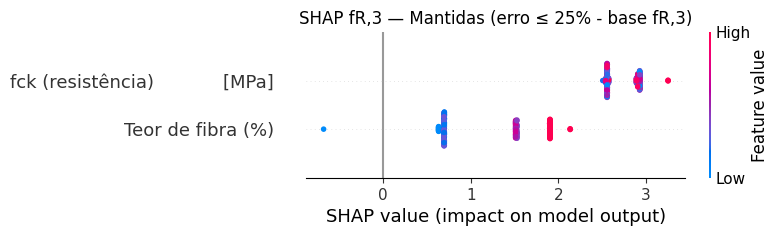

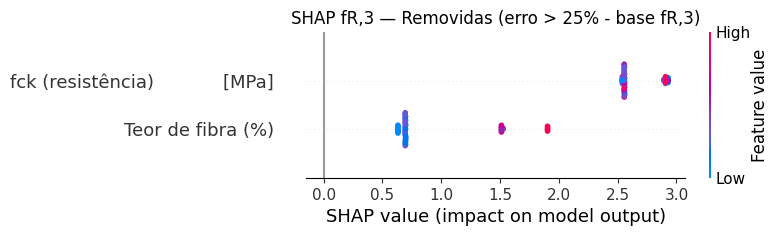

In [107]:
# ==========================
# C) Índices (kept/removed) baseados em fR,3
# ==========================
import numpy as np

error_threshold = 0.25
COL_FR3_EXP = 'fR,3 (N/mm²)      (experimental)'

# Predição para toda a base com o pipeline fR,3
if 'pipeline_gbr_fr3' in globals():
    y3_pred_all = pipeline_gbr_fr3.predict(df[FEATURES_FR3])
else:
    # Fallback simples (não recomendado se seu pipeline tiver mais features/transformações):
    from sklearn.ensemble import GradientBoostingRegressor
    aux = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    aux.fit(df[FEATURES_FR3], df[COL_FR3_EXP])
    y3_pred_all = aux.predict(df[FEATURES_FR3])

y3_exp = df[COL_FR3_EXP].values
percent_error_fr3 = np.abs(y3_exp - y3_pred_all) / np.abs(y3_exp)

removed_idx_fr3 = df.index[percent_error_fr3 > error_threshold]
kept_idx_fr3    = df.index[percent_error_fr3 <= error_threshold]

print(f"[fR,3] Mantidas (≤25%): {len(kept_idx_fr3)}  |  Removidas (>25%): {len(removed_idx_fr3)}")

# Agora rode SHAP com esses subconjuntos:
_, shap_kept_fr3, X_kept_imp_fr3 = shap_fr3_summary(
    df_subset=df.loc[kept_idx_fr3],
    plot_title="SHAP fR,3 — Mantidas (erro ≤ 25% - base fR,3)"
)
_, shap_removed_fr3, X_removed_imp_fr3 = shap_fr3_summary(
    df_subset=df.loc[removed_idx_fr3],
    plot_title="SHAP fR,3 — Removidas (erro > 25% - base fR,3)"
)

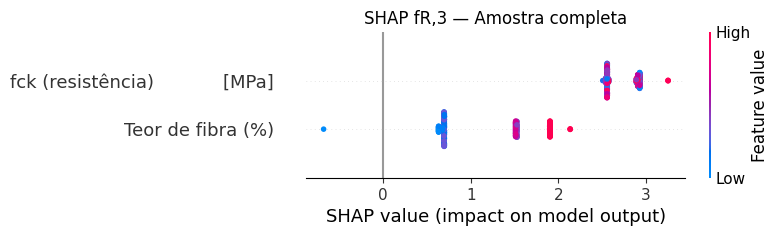

In [108]:
# =============================================================================
# SHAP para fR,3 — AMOSTRA INTEIRA (beeswarm / summary plot)
# =============================================================================
# Requisitos:
# - df: DataFrame original com as colunas de entrada
# - pipeline_gbr_fr3: (opcional, preferido) pipeline treinado para fR,3
# - Se não houver pipeline, a célula cai para um GradientBoostingRegressor "local"
# =============================================================================

# 1) Imports e setup
import numpy as np
import pandas as pd

# Se 'shap' não estiver instalado, descomente este bloco:
# import sys, subprocess
# subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])

import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# 2) Defina as MESMAS features usadas no treino do pipeline fr3
FEATURES_FR3 = [
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]
# Se seu pipeline usa mais colunas, inclua todas aqui exatamente na mesma ordem.

# 3) Constrói matriz X (toda a amostra)
X_raw_fr3 = df[FEATURES_FR3].copy()

# 4) Obtém modelo e, se existir no pipeline, aplica o mesmo imputer/transform
model_fr3 = None
X_imp_fr3 = None

if 'pipeline_gbr_fr3' in globals():
    pipe = pipeline_gbr_fr3

    # Tenta localizar steps do pipeline
    imputer = None
    model   = None
    if hasattr(pipe, "named_steps"):
        imputer = pipe.named_steps.get('imputer', None)
        model   = pipe.named_steps.get('model', None) or pipe.named_steps.get('regressor', None)
        if model is None:
            model = list(pipe.named_steps.values())[-1]  # último step
    else:
        steps = dict(pipe.steps)
        imputer = steps.get('imputer', None)
        model   = steps.get('model', None) or steps.get('regressor', None) or pipe

    # Aplica imputação se existir (mantenha a coerência com o treino)
    if imputer is not None:
        X_imp_fr3 = pd.DataFrame(imputer.transform(X_raw_fr3),
                                 columns=FEATURES_FR3, index=df.index)
    else:
        X_imp_fr3 = X_raw_fr3.copy()

    model_fr3 = model
else:
    # Fallback simples (não ideal se seu pipeline tiver transformações complexas)
    # Usa o alvo experimental para ajustar rapidamente um GBR e gerar SHAPs
    COL_FR3_EXP = 'fR,3 (N/mm²)      (experimental)'
    aux_gbr = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
    )
    aux_gbr.fit(X_raw_fr3, df[COL_FR3_EXP])
    model_fr3 = aux_gbr
    X_imp_fr3 = X_raw_fr3.copy()

# 5) TreeExplainer e SHAP values
explainer_fr3 = shap.TreeExplainer(
    model_fr3,
    feature_perturbation="interventional"
)
shap_vals_fr3 = explainer_fr3.shap_values(X_imp_fr3, check_additivity=False)

# 6) Plot (beeswarm / summary)
shap.summary_plot(shap_vals_fr3, X_imp_fr3, plot_type="dot", show=False)
plt.title("SHAP fR,3 — Amostra completa")
plt.show()



In [112]:
# =============================================================================
# Comparativo de qualidade (fR,1 vs fR,3) usando o MESMO conjunto de amostras
# - "Completo (interseção)": interseção de válidos fR,1 ∩ fR,3
# - "≤25% (base fR,3 ∩)": mantidas por fR,3 (erro ≤ 25%) ∩ válidos em fR,1
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from datetime import datetime

# -----------------------------
# Parâmetros / nomes de colunas
# -----------------------------
COL_FR1_EXP = 'fR,1 (N/mm²)      (experimental)'
COL_FR3_EXP = 'fR,3 (N/mm²)      (experimental)'

# Use as MESMAS features usadas no treino dos pipelines:
FEATURES_FR = [
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]
ERROR_THRESHOLD = 0.25  # 25%

# -----------------------------
# Funções utilitárias
# -----------------------------
def _rmse(y_true, y_pred):
    """RMSE compatível com versões antigas de sklearn (sem squared=False)."""
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def _predicoes_alvo(df_full: pd.DataFrame, exp_col: str, pipe_name: str):
    """
    Predições para o alvo (fR,1 ou fR,3) usando:
      1) pipeline_gbr_fr1 / pipeline_gbr_fr3 (preferência)
      2) fallback gbr+X (para fR,1), se existir
      3) fallback GBR rápido treinando em FEATURES_FR (para fR,3 ou fR,1 sem gbr)
    """
    if pipe_name in globals():
        pipe = globals()[pipe_name]
        try:
            return np.asarray(pipe.predict(df_full[FEATURES_FR]))
        except Exception as e:
            print(f"[AVISO] Falhou ao usar {pipe_name}: {e} — tentando fallback.")

    if pipe_name == 'pipeline_gbr_fr1' and 'gbr' in globals() and 'X' in globals():
        try:
            return np.asarray(gbr.predict(X))
        except Exception:
            pass

    aux = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    aux.fit(df_full[FEATURES_FR], df_full[exp_col])
    return np.asarray(aux.predict(df_full[FEATURES_FR]))

def _rel_error(y_true, y_pred):
    """Erro relativo seguro (ignora casos com denominador zero)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        rel = np.abs(y_true - y_pred) / np.abs(y_true)
        rel[~np.isfinite(rel)] = np.nan
    return rel

def _report(y_true, y_pred, nome_alvo: str, escopo: str, thr=ERROR_THRESHOLD):
    """Monta dicionário com as métricas para a tabela."""
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    mask = y_true.notna() & y_pred.notna()
    yt = y_true[mask].values
    yp = y_pred[mask].values

    n = int(len(yt))
    if n == 0:
        return {
            'Alvo': nome_alvo, 'Escopo': escopo, 'N': 0,
            'MAE': np.nan, 'RMSE': np.nan, 'R²': np.nan,
            'MAPE (%)': np.nan, 'Mediana |Erro|': np.nan,
            'Máx |Erro|': np.nan, 'Bias (pred - exp)': np.nan,
            'Corr (r)': np.nan, '% Erro > 25%': np.nan
        }

    mae  = mean_absolute_error(yt, yp)
    rmse = _rmse(yt, yp)
    r2   = r2_score(yt, yp) if n > 1 else np.nan
    abs_err = np.abs(yp - yt)
    med_abs = float(np.median(abs_err))
    max_abs = float(np.max(abs_err))
    bias = float(np.mean(yp - yt))
    corr = float(np.corrcoef(yt, yp)[0,1]) if n > 1 else np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.abs((yp - yt) / yt)
        mape = mape[np.isfinite(mape)]
        mape = float(np.mean(mape) * 100) if mape.size > 0 else np.nan

    rel = _rel_error(yt, yp)
    rel_valid = rel[np.isfinite(rel)]
    pct_gt25 = float((rel_valid > thr).mean()*100) if rel_valid.size > 0 else np.nan

    return {
        'Alvo': nome_alvo, 'Escopo': escopo, 'N': n,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE (%)': mape, 'Mediana |Erro|': med_abs,
        'Máx |Erro|': max_abs, 'Bias (pred - exp)': bias,
        'Corr (r)': corr, '% Erro > 25%': pct_gt25
    }

def _fmt_styler(df_rep: pd.DataFrame):
    """Formatação amigável para exibir no notebook."""
    fmt = {
        'N': '{:,.0f}'.format,
        'MAE': '{:,.3f}'.format,
        'RMSE': '{:,.3f}'.format,
        'R²': '{:,.3f}'.format,
        'MAPE (%)': '{:,.2f}'.format,
        'Mediana |Erro|': '{:,.3f}'.format,
        'Máx |Erro|': '{:,.3f}'.format,
        'Bias (pred - exp)': '{:,.3f}'.format,
        'Corr (r)': '{:,.3f}'.format,
        '% Erro > 25%': '{:,.2f}'.format
    }
    try:
        sty = (df_rep
               .style
               .format(fmt)
               .hide(axis='index')
               .set_properties(**{'text-align': 'center'})
               .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
               .background_gradient(subset=['R²', 'Corr (r)'], cmap='Greens')
               .background_gradient(subset=['MAE','RMSE','MAPE (%)','% Erro > 25%','Máx |Erro|','Mediana |Erro|','Bias (pred - exp)'], cmap='Reds_r')
              )
        return sty
    except Exception:
        return df_rep

# -----------------------------
# Predições completas
# -----------------------------
y1_true = df[COL_FR1_EXP].astype(float).values
y1_pred = _predicoes_alvo(df, COL_FR1_EXP, pipe_name='pipeline_gbr_fr1')

y3_true = df[COL_FR3_EXP].astype(float).values
y3_pred = _predicoes_alvo(df, COL_FR3_EXP, pipe_name='pipeline_gbr_fr3')

# Máscaras de válidos
valid1 = np.isfinite(y1_true) & np.isfinite(y1_pred)
valid3 = np.isfinite(y3_true) & np.isfinite(y3_pred)

# Interseção para "Completo"
mask_complete_intersect = valid1 & valid3

# Erro relativo de fR,3 (base para ≤25%)
rel3 = _rel_error(y3_true, y3_pred)
keep3 = np.isfinite(rel3) & (rel3 <= ERROR_THRESHOLD)

# Conjunto ≤25% baseado em fR,3 e válido em fR,1
mask_kept_intersect = keep3 & valid1 & valid3

# -----------------------------
# Relatórios PAREADOS (mesmo N nos pares)
# -----------------------------
linhas = []

# COMPLETO (interseção fR,1 ∩ fR,3) — mesmo N nos dois alvos
linhas.append(_report(y1_true[mask_complete_intersect], y1_pred[mask_complete_intersect],
                      'fR,1', 'Completo (interseção)'))
linhas.append(_report(y3_true[mask_complete_intersect], y3_pred[mask_complete_intersect],
                      'fR,3', 'Completo (interseção)'))

# ≤25% (base fR,3 ∩ válidos em fR,1) — mesmo N nos dois alvos
linhas.append(_report(y1_true[mask_kept_intersect], y1_pred[mask_kept_intersect],
                      'fR,1', '≤25% (base fR,3 ∩)'))
linhas.append(_report(y3_true[mask_kept_intersect], y3_pred[mask_kept_intersect],
                      'fR,3', '≤25% (base fR,3 ∩)'))

comparativo_pareado = pd.DataFrame(linhas, columns=[
    'Alvo','Escopo','N','MAE','RMSE','R²','MAPE (%)',
    'Mediana |Erro|','Máx |Erro|','Bias (pred - exp)','Corr (r)','% Erro > 25%'
])

# Ordena e exibe
comparativo_pareado['ord'] = comparativo_pareado['Escopo'].map({'Completo (interseção)':0,'≤25% (base fR,3 ∩)':1})*10 + comparativo_pareado['Alvo'].map({'fR,1':0,'fR,3':1})
comparativo_pareado = comparativo_pareado.sort_values('ord').drop(columns='ord').reset_index(drop=True)

display(_fmt_styler(comparativo_pareado))

# -----------------------------
# (Opcional) Exporta para Excel
# -----------------------------
SALVAR_EXCEL = True
if SALVAR_EXCEL:
    nome_arquivo = f"comparativo_pareado_fr1_fr3_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    with pd.ExcelWriter(nome_arquivo, engine="openpyxl") as wr:
        comparativo_pareado.to_excel(wr, sheet_name="Comparativo (pareado)", index=False)

        # Anexa também as máscaras usadas (auditoria)
        idx = pd.Series(df.index, name='idx')
        audit = pd.DataFrame({
            'idx': df.index,
            'valid1': valid1,
            'valid3': valid3,
            'mask_complete_intersect': mask_complete_intersect,
            'keep3': keep3,
            'mask_kept_intersect': mask_kept_intersect
        })
        audit.to_excel(wr, sheet_name="Mascaras", index=False)
    print(f" Excel exportado: {nome_arquivo}")

Alvo,Escopo,N,MAE,RMSE,R²,MAPE (%),Mediana |Erro|,Máx |Erro|,Bias (pred - exp),Corr (r),% Erro > 25%
"fR,1",Completo (interseção),291,0.453,0.673,0.930,9.84,0.298,3.945,0.008,0.965,7.90
"fR,3",Completo (interseção),291,0.706,0.980,0.877,15.70,0.487,4.696,0.022,0.937,20.62
"fR,1","≤25% (base fR,3 ∩)",231,0.357,0.524,0.961,6.60,0.232,2.524,-0.066,0.981,2.60
"fR,3","≤25% (base fR,3 ∩)",231,0.503,0.693,0.942,9.15,0.363,2.972,-0.116,0.973,0.00


 Excel exportado: comparativo_pareado_fr1_fr3_20260303_092304.xlsx


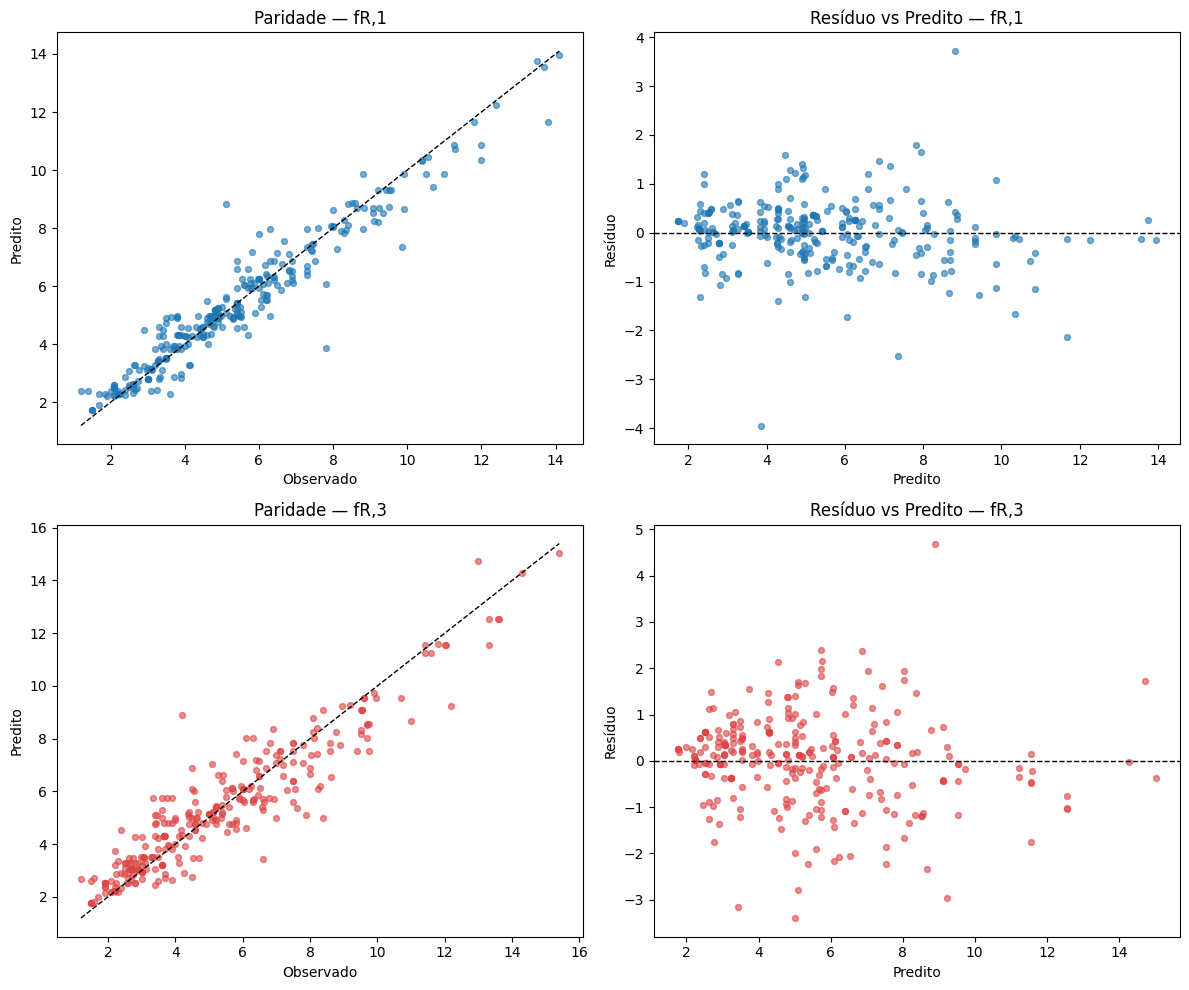

In [113]:
# =============================================================================
# Plots de diagnóstico: Paridade y_pred vs y_true e Resíduo vs y_pred (fR,1 e fR,3)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ajuste se necessário:
COL_FR1_EXP = 'fR,1 (N/mm²)      (experimental)'
COL_FR3_EXP = 'fR,3 (N/mm²)      (experimental)'
FEATURES_FR = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']

def _pred(df_full, exp_col, pipe_name):
    if pipe_name in globals():
        try:
            return globals()[pipe_name].predict(df_full[FEATURES_FR])
        except Exception as e:
            print(f"[AVISO] {pipe_name} falhou, tentando fallback: {e}")
    # Fallback simples
    from sklearn.ensemble import GradientBoostingRegressor
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(df_full[FEATURES_FR], df_full[exp_col].astype(float))
    return m.predict(df_full[FEATURES_FR])

# Predições
y1_true = df[COL_FR1_EXP].astype(float).values
y1_pred = _pred(df, COL_FR1_EXP, 'pipeline_gbr_fr1')
y3_true = df[COL_FR3_EXP].astype(float).values
y3_pred = _pred(df, COL_FR3_EXP, 'pipeline_gbr_fr3')

# Resíduos
r1 = y1_pred - y1_true
r3 = y3_pred - y3_true

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Paridade fR,1
axes[0].scatter(y1_true, y1_pred, alpha=0.6, s=18)
mn, mx = np.nanmin(y1_true), np.nanmax(y1_true)
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1)
axes[0].set_title('Paridade — fR,1')
axes[0].set_xlabel('Observado'); axes[0].set_ylabel('Predito')

# Resíduo fR,1
axes[1].scatter(y1_pred, r1, alpha=0.6, s=18)
axes[1].axhline(0, color='k', ls='--', lw=1)
axes[1].set_title('Resíduo vs Predito — fR,1')
axes[1].set_xlabel('Predito'); axes[1].set_ylabel('Resíduo')

# Paridade fR,3
axes[2].scatter(y3_true, y3_pred, alpha=0.6, s=18, color='#d44')
mn, mx = np.nanmin(y3_true), np.nanmax(y3_true)
axes[2].plot([mn, mx], [mn, mx], 'k--', lw=1)
axes[2].set_title('Paridade — fR,3')
axes[2].set_xlabel('Observado'); axes[2].set_ylabel('Predito')

# Resíduo fR,3
axes[3].scatter(y3_pred, r3, alpha=0.6, s=18, color='#d44')
axes[3].axhline(0, color='k', ls='--', lw=1)
axes[3].set_title('Resíduo vs Predito — fR,3')
axes[3].set_xlabel('Predito'); axes[3].set_ylabel('Resíduo')

plt.tight_layout()
plt.show()


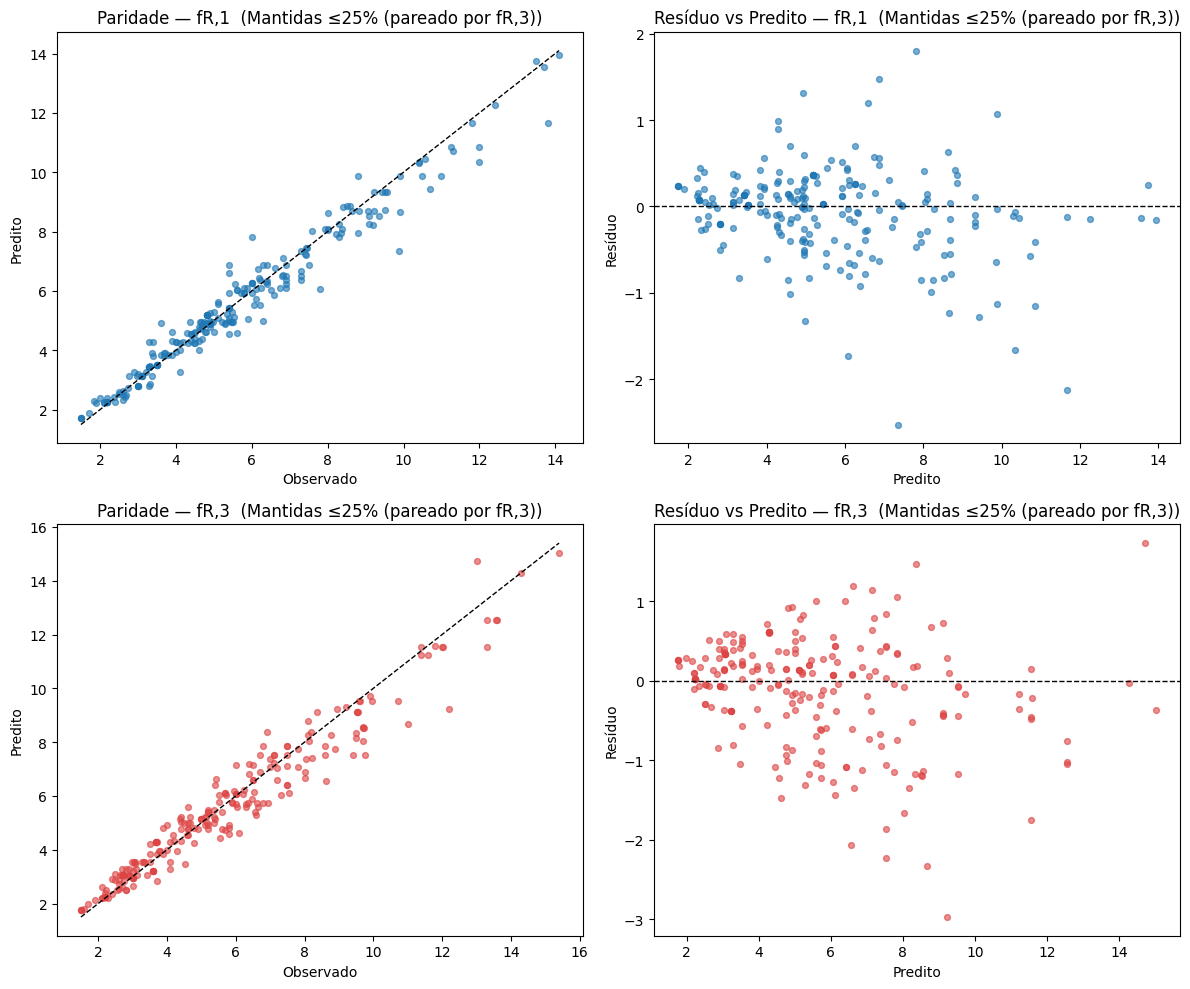

[INFO] N fR,1 plotado: 231 | N fR,3 plotado: 231 | Modo: Mantidas ≤25% (pareado por fR,3)


In [122]:
# =============================================================================
# Plots de diagnóstico (Paridade e Resíduo) — fR,1 e fR,3
# Comportamentos:
#   USE_FILTER_25 = False  -> amostra inteira
#   USE_FILTER_25 = True   -> apenas mantidas (erro rel <= 25%)
#       MATCH_TO_FR3 = True  -> usa as mantidas de fR,3 e aplica ao par fR,1 (mesmo N)
#       MATCH_TO_FR3 = False -> cada alvo usa suas próprias mantidas
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

# ---------- Parâmetros ----------
COL_FR1_EXP = 'fR,1 (N/mm²)      (experimental)'
COL_FR3_EXP = 'fR,3 (N/mm²)      (experimental)'
FEATURES_FR = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']  # ajuste se seus pipelines usam mais features
ERROR_THRESHOLD = 0.25

# Liga/desliga filtros
USE_FILTER_25 = True          # False = amostra inteira | True = somente mantidas (erro <= 25%)
MATCH_TO_FR3  = True          # quando filtrado, usa o mesmo conjunto de fR,3 para fR,1 (mais restritivo)

# ---------- Predição helper ----------
def _pred(df_full, exp_col, pipe_name):
    """Tenta pipeline; se falhar, treina um GBR rápido só p/ gerar os gráficos."""
    if pipe_name in globals():
        try:
            return globals()[pipe_name].predict(df_full[FEATURES_FR])
        except Exception as e:
            print(f"[AVISO] {pipe_name} falhou, fallback GBR simples: {e}")
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(df_full[FEATURES_FR], df_full[exp_col].astype(float))
    return m.predict(df_full[FEATURES_FR])

def _rel_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        r = np.abs(y_true - y_pred) / np.abs(y_true)
        r[~np.isfinite(r)] = np.nan
    return r

# ---------- Predições na base inteira ----------
y1_true_all = df[COL_FR1_EXP].astype(float).values
y1_pred_all = _pred(df, COL_FR1_EXP, 'pipeline_gbr_fr1')

y3_true_all = df[COL_FR3_EXP].astype(float).values
y3_pred_all = _pred(df, COL_FR3_EXP, 'pipeline_gbr_fr3')

# Máscaras de válidos na base inteira
valid1_all = np.isfinite(y1_true_all) & np.isfinite(y1_pred_all)
valid3_all = np.isfinite(y3_true_all) & np.isfinite(y3_pred_all)

# ---------- Escolha do conjunto a plotar ----------
if not USE_FILTER_25:
    # Amostra inteira (cada alvo com seus válidos)
    mask1 = valid1_all
    mask3 = valid3_all
    escopo = "Amostra inteira"
else:
    # Mantidas por threshold de erro relativo
    rel1_all = _rel_error(y1_true_all, y1_pred_all)
    rel3_all = _rel_error(y3_true_all, y3_pred_all)
    kept1_all = np.isfinite(rel1_all) & (rel1_all <= ERROR_THRESHOLD)
    kept3_all = np.isfinite(rel3_all) & (rel3_all <= ERROR_THRESHOLD)

    if MATCH_TO_FR3:
        # Usa o mesmo conjunto de fR,3 para ambos (mais restritivo)
        base = kept3_all & valid1_all & valid3_all
        mask1 = base
        mask3 = base
        escopo = "Mantidas ≤25% (pareado por fR,3)"
    else:
        # Cada alvo com seu próprio conjunto de mantidas
        mask1 = kept1_all & valid1_all
        mask3 = kept3_all & valid3_all
        escopo = "Mantidas ≤25% (não pareado)"

# Subconjuntos finais
y1_true = y1_true_all[mask1]
y1_pred = y1_pred_all[mask1]
y3_true = y3_true_all[mask3]
y3_pred = y3_pred_all[mask3]

# Resíduos
r1 = y1_pred - y1_true
r3 = y3_pred - y3_true

# ---------- Plots ----------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Paridade fR,1
axes[0].scatter(y1_true, y1_pred, alpha=0.6, s=18)
mn, mx = np.nanmin(y1_true), np.nanmax(y1_true)
axes[0].plot([mn, mx], [mn, mx], 'k--', lw=1)
axes[0].set_title(f'Paridade — fR,1  ({escopo})')
axes[0].set_xlabel('Observado'); axes[0].set_ylabel('Predito')

# Resíduo fR,1
axes[1].scatter(y1_pred, r1, alpha=0.6, s=18)
axes[1].axhline(0, color='k', ls='--', lw=1)
axes[1].set_title(f'Resíduo vs Predito — fR,1  ({escopo})')
axes[1].set_xlabel('Predito'); axes[1].set_ylabel('Resíduo')

# Paridade fR,3
axes[2].scatter(y3_true, y3_pred, alpha=0.6, s=18, color='#d44')
mn, mx = np.nanmin(y3_true), np.nanmax(y3_true)
axes[2].plot([mn, mx], [mn, mx], 'k--', lw=1)
axes[2].set_title(f'Paridade — fR,3  ({escopo})')
axes[2].set_xlabel('Observado'); axes[2].set_ylabel('Predito')

# Resíduo fR,3
axes[3].scatter(y3_pred, r3, alpha=0.6, s=18, color='#d44')
axes[3].axhline(0, color='k', ls='--', lw=1)
axes[3].set_title(f'Resíduo vs Predito — fR,3  ({escopo})')
axes[3].set_xlabel('Predito'); axes[3].set_ylabel('Resíduo')

plt.tight_layout()
plt.show()

# Feedback rápido no console
print(f"[INFO] N fR,1 plotado: {len(y1_true)} | N fR,3 plotado: {len(y3_true)} | Modo: {escopo}")
if USE_FILTER_25 and MATCH_TO_FR3 and len(y1_true) != len(y3_true):
    print("[AVISO] N diferentes — verifique máscaras/valores ausentes nas colunas de fR,1/fR,3.")